In [85]:
# [0] 시스템 기초 설정 및 환경 구축
import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 및 시각화 한글 폰트 설정
warnings.filterwarnings('ignore')
if platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': 
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# [1] 데이터 전처리 및 검증 구조 설계
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# [2] 머신러닝 알고리즘 라인업 (Systemic Line-up)
# 2-1. 선형, 인접 이웃, SVM 및 기초 트리
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 2-2. 앙상블 및 고성능 부스팅 모델
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier, HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 2-3. Automated ML (AutoGluon)
from autogluon.tabular import TabularPredictor

# [3] 성능 평가 지표 (KPI)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

print("✅ 모든 라이브러리 로드 및 환경 설정 완료")

✅ 모든 라이브러리 로드 및 환경 설정 완료


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
import math

In [3]:
#!/bin/bash
!kaggle datasets download prachi13/customer-analytics -p ./data

Dataset URL: https://www.kaggle.com/datasets/prachi13/customer-analytics
License(s): other
customer-analytics.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import os

HOME = os.getcwd()
# 압축 파일의 위치
zipPath = os.path.join(HOME, 'data','customer-analytics.zip')
# 압축 해제 할 위치
targetPath = os.path.join(HOME, 'data')

In [5]:
from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)

In [6]:
trainPath = os.path.join(targetPath, 'Train.csv')
df = pd.read_csv(trainPath)
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
df.isna().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [9]:
TARGET = 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

빠른 분석을 위해 레이블 인코딩 후 히트맵 시각화

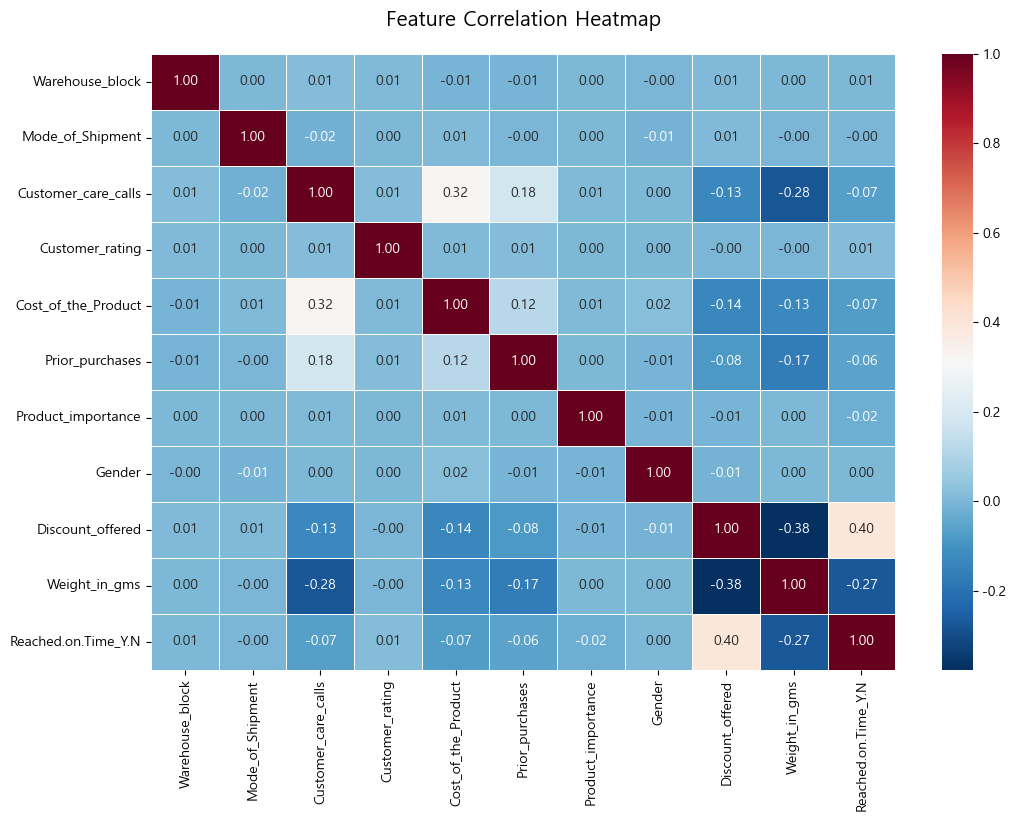

In [10]:


data = df.copy().drop(columns=['ID'])

# 범주형 변수 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
object_cols = data.select_dtypes(include=['object']).columns

for col in object_cols:
    data[col] = le.fit_transform(data[col])

# 히트맵 시각화
plt.figure(figsize=(12, 8)) 
sns.heatmap(data.corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=20)
plt.show()

유의미한 상관계수
* Discount_offered: 0.4
* Weight_in_gms: -0.27

그 외의 가능성 있는 항목
* Cost_of_the_Product: -0.07
* Customer_care_calls: -0.07
* prior_purchases: -0.06

검증용 데이터 분리

In [11]:
# 1. stratify 옵션을 써서 정답(Reached.on.Time_Y.N) 비율을 유지하며 8:2로 나눕니다.
# 이 함수는 내부적으로 데이터를 랜덤하게 섞어주기 때문에 sample을 따로 안 써도 됩니다.
part1, part2 = train_test_split(df, 
                                test_size=0.2, 
                                random_state=42, 
                                stratify=df['Reached.on.Time_Y.N'])

# 2. 각각 파일로 저장
part1.to_csv('data/train_df.csv', index=False)
part2.to_csv('data/test_df.csv', index=False)

print("데이터 분할 및 저장 완료!")
print(f"학습용: {part1.shape}, 테스트용: {part2.shape}")

데이터 분할 및 저장 완료!
학습용: (8799, 12), 테스트용: (2200, 12)


In [12]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
train_df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,7921,D,Road,4,1,261,2,medium,F,9,4158,0
1,1530,F,Ship,3,3,162,2,low,F,26,1659,1
2,10522,B,Ship,3,2,221,2,medium,M,9,4466,0
3,9559,D,Ship,3,5,157,4,medium,F,2,4640,0
4,969,A,Flight,2,5,272,2,low,M,24,3638,1


In [13]:
# target 데이터의 분포가 6:4로 비슷하게 이루어져 있음
print(f"배송 지연 확률: {train_df['Reached.on.Time_Y.N'].mean() * 100:.2f}%")

배송 지연 확률: 59.67%


| 컬럼명 (Column Name) | 설명 (Description) | 구분/범위 (Value Range) | 비고 (Additional Notes) |
| :--- | :--- | :--- | :--- |
| **ID** | 고객 고유 번호 | 숫자 (Numeric) | 인덱스. 정보 가치 없음|
| **Warehouse block** | 창고 구역 | A, B, C, D, E | 대규모 창고 내 구역 구분 |
| **Mode of shipment** | 배송 수단 | Ship, Flight, Road | 선박, 항공, 육로 배송 |
| **Customer care calls** | 고객 센터 문의 횟수 | 숫자 (Numeric) | 배송 관련 문의 전화 건수 |
| **Customer rating** | 고객 만족도 평점 | 1(낮음) ~ 5(높음) | 배송에 대한 만족도가 아닐수 있음에 주의 |
| **Cost of the product** | 제품 가격 | US 달러 ($) | 해당 제품의 판매가 |
| **Prior purchases** | 이전 구매 횟수 | 숫자 (Numeric) | 해당 고객의 과거 구매 이력 |
| **Product importance** | 제품 중요도 | low, medium, high | 중요도의 기준이 무엇인지 확인 불가 |
| **Gender** | 성별 | Male, Female |  |
| **Discount offered** | 할인액 | 1~65의 정수 | 할인 금액. 할인율과 다를것으로 추측 |
| **Weight in gms** | 제품 무게 | 그램 (g) | 제품의 실제 무게 |
| **Reached on time** | **정시 도착 여부** | 0: 정시, 1: 지연 | **타겟 변수 (Target Variable)** |

#### 특성 분류
범주형과 수치형의 분리

In [14]:
def split_feature_types(df, threshold=10):
    """
    ID를 제외하고 범주형과 수치형을 분리합니다.
    수치형 중에서도 고유값(unique) 개수가 threshold 이하이면 범주형으로 간주합니다.
    """
    temp_df = df.copy()
    if 'ID' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ID'])
        
    # 타겟 제외
    target_name = 'Reached.on.Time_Y.N'
    features = [col for col in temp_df.columns if col != target_name]
    
    cat_cols = []
    num_cols = []
    
    for col in features:
        # 1. 데이터 타입이 object/category거나, 고유값 개수가 적은 경우 범주형으로 분류
        if temp_df[col].dtype in ['object', 'category'] or temp_df[col].nunique() <= threshold:
            cat_cols.append(col)
        # 2. 그 외에는 수치형으로 분류
        else:
            num_cols.append(col)

    print(f'범주형:{cat_cols}')
    print(f'숫자형:{num_cols}')
    return cat_cols, num_cols

In [15]:
cat_cols, num_cols = split_feature_types(train_df)

범주형:['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
숫자형:['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


### 시각화 함수 정의

In [16]:
# 범주형 특성의 시각화

target = 'Reached.on.Time_Y.N'

def plot_categorical_analysis(df, features, target):
    """
    범주형 특성 리스트를 받아 왼쪽에는 빈도 분포(Count), 
    오른쪽에는 타겟 지연율(Rate)을 나란히 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 한 특성씩(왼쪽/오른쪽 두 개 그래프) 배치하므로 rows는 특성 개수와 같습니다.
    rows = num_features 
    
    plt.figure(figsize=(10, rows * 3))
    plt.suptitle('Categorical Feature Analysis: Distribution vs Delay Rate', fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(features):
        
        if df[col].dtype.name == 'category':
            order = df[col].cat.categories.tolist()
        else:
            order = sorted(df[col].unique())
        
        # --- 왼쪽: 빈도 분포 (Count Plot) ---
        plt.subplot(rows, 2, i * 2 + 1)
        sns.countplot(x=col, data=df, order=order, palette='Pastel1', hue=col, legend=False)
        plt.title(f'{col} Distribution', fontsize=10)
        plt.xlabel('') # 가독성을 위해 x축 레이블 생략 가능
       
        # --- 오른쪽: 지연율 (Delay Rate Bar Plot) ---
        plt.subplot(rows, 2, i * 2 + 2)
        # 지연율 계산
        ax = sns.barplot(
            x=col, y=target, data=df, order=order, 
            palette='viridis', hue=col, legend=False, errorbar=None
        )
        
        # 전체 평균 지연율 기준선
        avg_rate = df[target].mean()
        ax.axhline(avg_rate, color='red', linestyle='--', alpha=0.6)
        
        # 수치 표시 (%)
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'{col} Delay Rate', fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

In [17]:
# 수치형 특성의 시각화

def plot_numeric_analysis(df, features, target):
    """
    수치형 특성 리스트를 받아 한 행에 KDE, Boxplot, Histogram+KDE를 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 3개씩 배치
    plt.figure(figsize=(18, num_features * 4))
    plt.suptitle('Numerical Feature Analysis: KDE vs Boxplot vs Histogram', fontsize=18, fontweight='bold', y=1.02)

    for i, col in enumerate(features):
        # 1. KDE Plot: 두 그룹의 밀도 곡선 비교
        plt.subplot(num_features, 3, i*3 + 1)
        sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='viridis', alpha=0.5)
        plt.title(f'{col} - Density Curve', fontsize=12)

        # 2. Boxplot: 중앙값 및 이상치 확인
        plt.subplot(num_features, 3, i*3 + 2)
        sns.boxplot(data=df, x=target, y=col, hue=target, palette='viridis', legend=False)
        plt.title(f'{col} - Outliers & Range', fontsize=12)
        
        # 3. Histogram + KDE: 실제 데이터 빈도와 곡선 결합
        plt.subplot(num_features, 3, i*3 + 3)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='viridis', alpha=0.3)
        plt.title(f'{col} - Histogram (Step)', fontsize=12)

    plt.tight_layout()
    plt.show()

### 각 특성별 지연율

In [18]:
# 시각화 가독성을 위해 범주 순서 정렬
importance_order = ['low', 'medium', 'high']
train_df['Product_importance'] = pd.Categorical(train_df['Product_importance'], 
                                         categories=importance_order, 
                                         ordered=True)

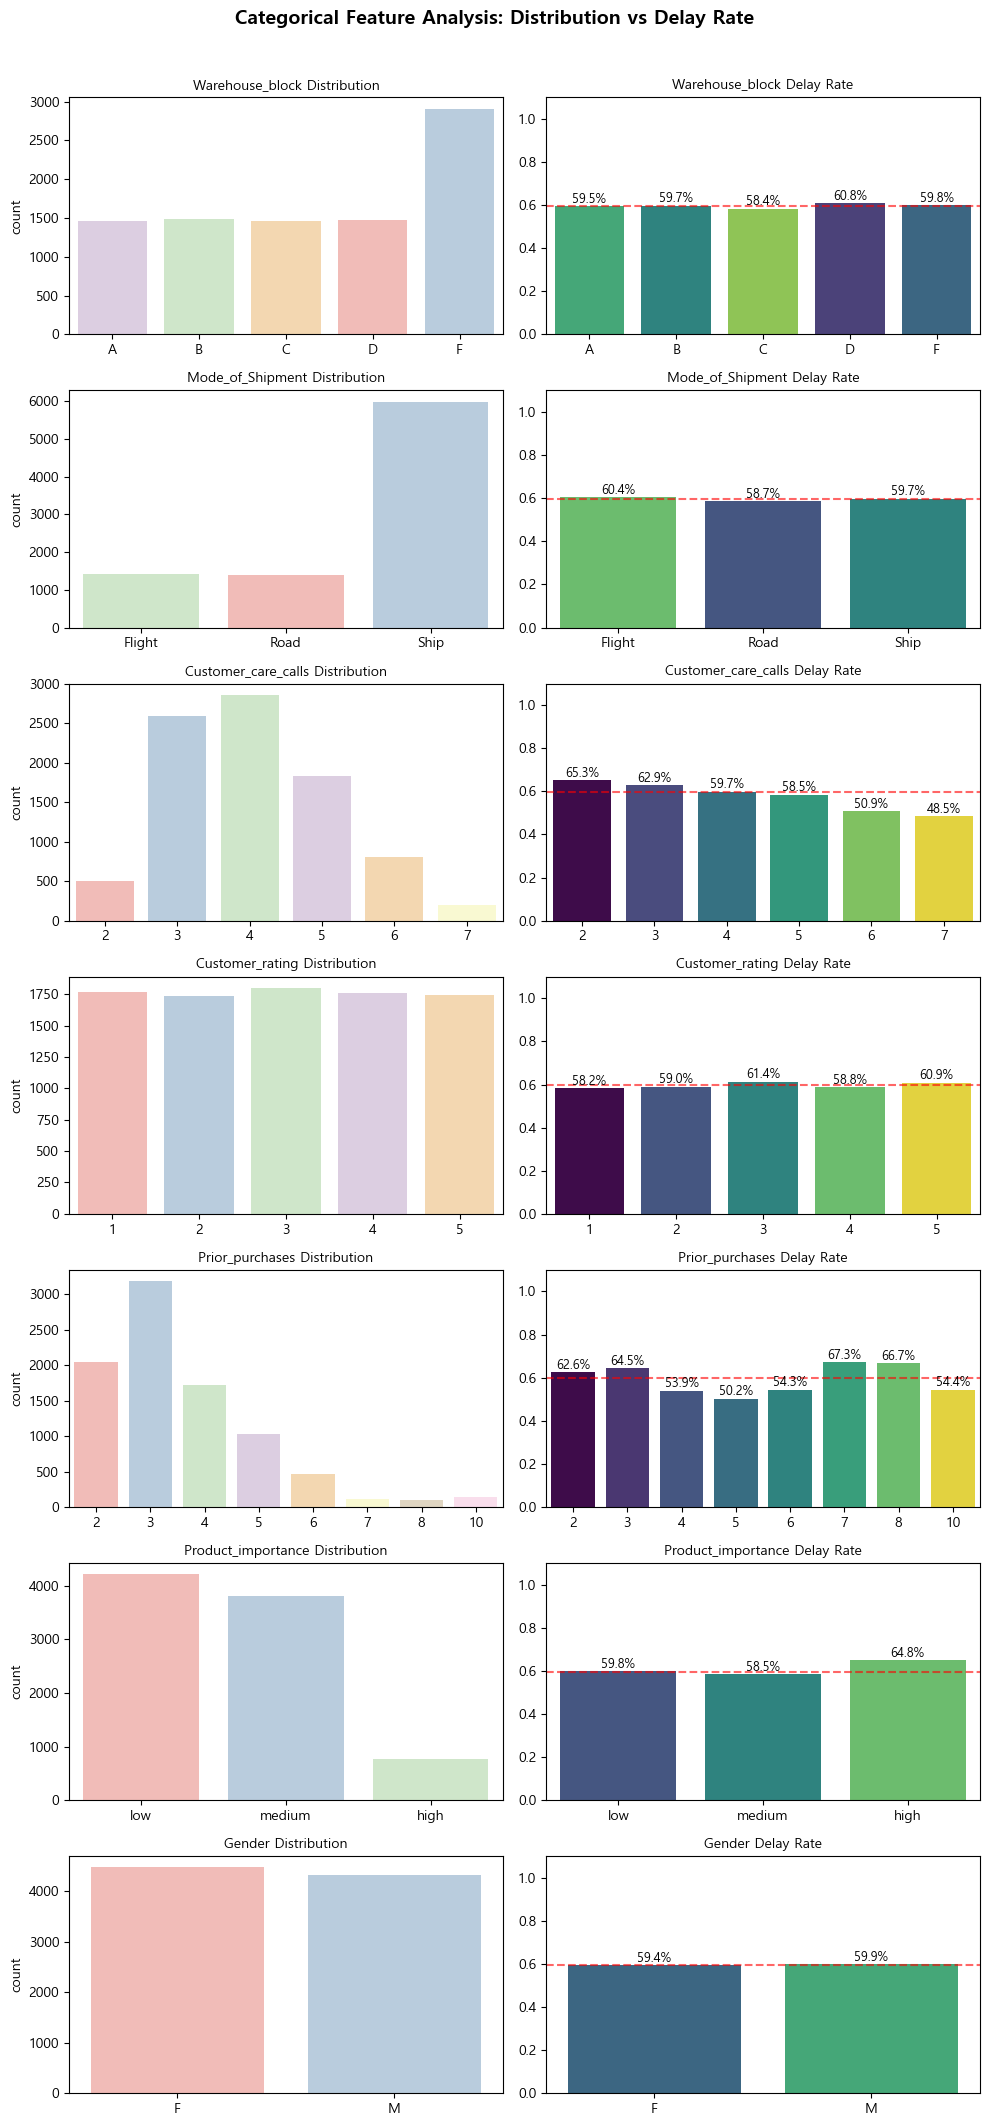

In [19]:
plot_categorical_analysis(train_df, cat_cols, target)

* Warehouse_block에서 f의 비중이 큰 것을 발견 <br>
	-> 하지만 지연율 차이 미미
* Mode_of_Shipment은 Ship에 집중 <br>
	 ->하지만 지연율 차이 미미
* Customer_care_calls는 2, 6, 7의 데이터 크기가 작음 <br>
	 ->많아질수록 지연율 떨어짐. 6 이후를 하나로 묶을 필요성
* Customer_rating은 분포가 고르다 <br>
	 ->지연율 차이도 미미
* Prior_purchases는 6 이후의 분포가 적음 <br>
	 ->지연율은 4,5,6에서 감소. 6 이후를 통합
* Product_importance는 High에서 오히려 높은 지연율 <br>
	-> importance의 기준이 무엇인지 확인 필요
* Gender에 따른 지연율의 차이 없음

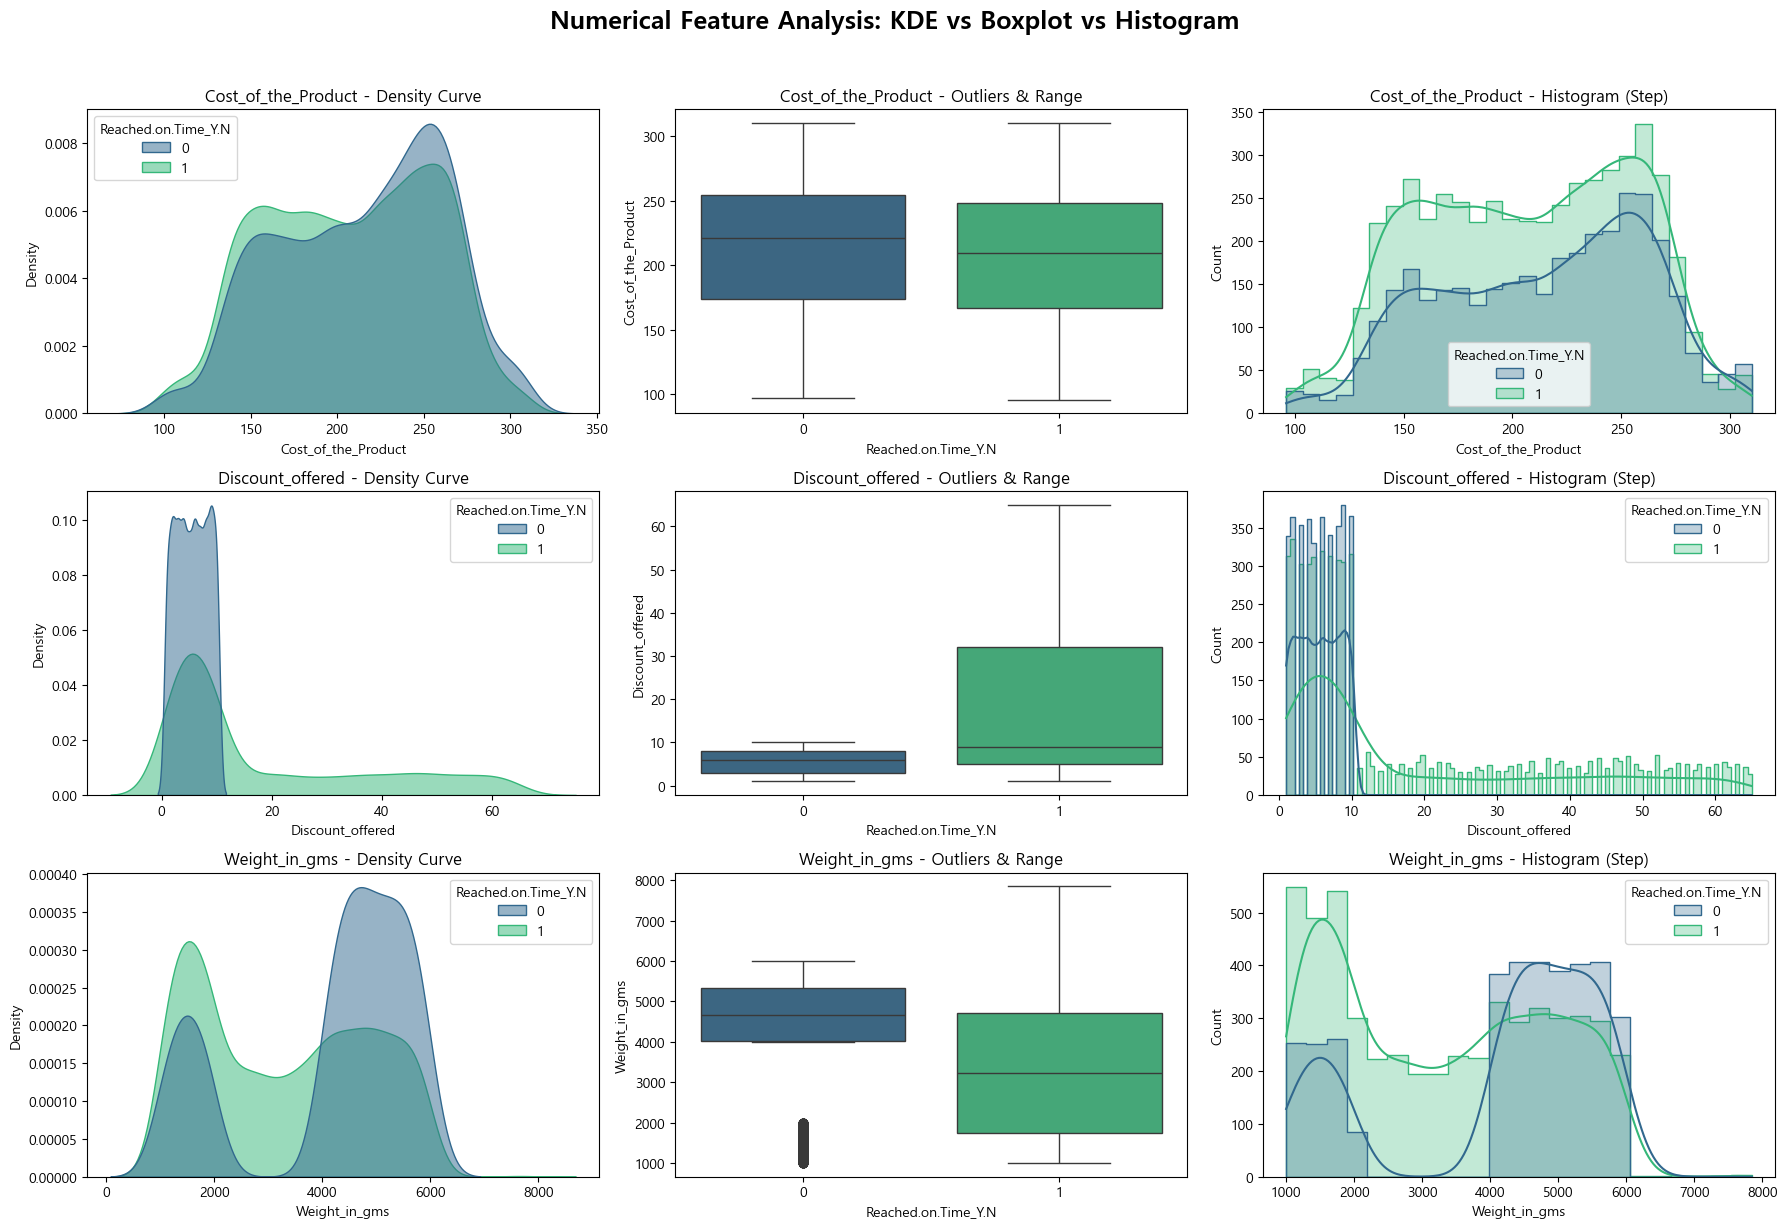

In [20]:
plot_numeric_analysis(train_df, num_cols, target)

* Cost_of_the_product는 큰 영향 없는듯 보인다
    -> 다른 특성과 결합하여 가능한 변수 만들어보기
* Discount_offered는 10 초과는 지연
    -> 10을 기준으로 구분 필요
* Weight_in_gms는 구간에 따른 지연율 차이
    -> 낮은 구간, 중간 구간, 높은 구간의 지연율이 각각 다름

## EDA

1. 특성간 분포 변화를 살펴보고 관계성 추측
    * 하나의 특성에 다른 features는 어떤 분포를 하는지 시각적으로 확인할 수 있는 함수 생성
    * 이상치 여부를 판단하는 로직을 넣어 효율적으로 데이터 탐색
2. 새로운 파생변수 생성 및 지연율에 대한 영향력 확인

### 특성간 비교 함수 정의

In [21]:
# 범주형 특성과의 관계 분석 함수

def summarize_categorical_with_plots(df, group_col, target_features, threshold=5.0):
    """
    각 창고별 비율과 전체 비율(Overall)을 비교하여 
    차이가 threshold(%p) 이상인 경우에만 표를 출력합니다.
    """
    filtered_features = [col for col in target_features if col != group_col]
    
    for col in filtered_features:
        # 1. 그룹별 빈도 및 비율 계산
        count_table = pd.crosstab(df[group_col], df[col])
        percent_table = pd.crosstab(df[group_col], df[col], normalize='index') * 100
        
        # 2. 전체 데이터(Overall) 비율 및 빈도 계산
        overall_counts = df[col].value_counts().reindex(count_table.columns)
        overall_percents = (df[col].value_counts(normalize=True) * 100).reindex(count_table.columns)
        
        # 3. 이상치 여부 판단 (어떤 그룹이라도 전체 평균과 threshold 이상 차이가 나는가?)
        is_outlier = False
        for category in overall_percents.index:
            diff = (percent_table[category] - overall_percents[category]).abs()
            if diff.max() >= threshold:
                is_outlier = True
                break
        
        # 4. 결과 출력
        if is_outlier:
            print(f"\n[🚨 이상치 발견] '{col}' 특성은 {group_col}별로 유의미한 차이가 있습니다.")
            
            # 5. 빈도와 비율을 합친 요약 테이블 생성
            summary_table = count_table.copy().astype(str)
            for row in count_table.index:
                for c in count_table.columns:
                    summary_table.loc[row, c] = f"{count_table.loc[row, c]} ({percent_table.loc[row, c]:.1f}%)"
            
            # 6. Overall(전체 평균) 행 추가
            overall_row = []
            for c in count_table.columns:
                overall_row.append(f"{overall_counts[c]} ({overall_percents[c]:.1f}%)")
            
            summary_table.loc['Overall'] = overall_row
            
            display(summary_table)


            # --- [시각화 데이터 준비] ---
            # 표와 동일한 구조를 위해 Overall을 포함한 Wide format 생성
            plot_df_wide = percent_table.copy()
            plot_df_wide.loc['Overall'] = overall_percents
            
            # 그래프용 Long format 변환
            plot_df_long = plot_df_wide.reset_index().melt(id_vars=group_col, var_name=col, value_name='Percentage')

            # --- [그래프 그리기] ---
            plt.figure(figsize=(10, 5))
            
            # 범례 순서를 표의 컬럼 순서와 동일하게 고정
            category_order = list(count_table.columns)
            
            ax = sns.barplot(
                data=plot_df_long, y=group_col, x='Percentage', hue=col, hue_order=category_order, palette='viridis' )
            
            # 막대 옆에 % 수치 표시
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f' {width:.1f}%', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(3, 0), textcoords='offset points')

            plt.title(f'Distribution of {col} by {group_col}', fontsize=14, pad=20)
            plt.xlabel('Percentage (%)')
            plt.ylabel(group_col)
            plt.xlim(0, plot_df_long['Percentage'].max() * 1.2) # 수치 표시 공간 확보
            plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.grid(axis='x', linestyle='--', alpha=0.3)
            plt.tight_layout()
            plt.show()

            
        else:
            print(f"[✅ 이상치 없음] '{col}': 모든 {group_col}에서 고른 분포를 보입니다.")

In [22]:
# 수치형 특성과의 관계 분석 함수

def summarize_numeric_with_plots(df, group_col, target_features, threshold=0.1):
    """
    수치형 특성의 그룹별 통계량과 전체 분포를 비교 시각화합니다.
    """
    for col in target_features:
        if col == group_col: continue
        
        # 1. 통계량 계산
        group_stats = df.groupby(group_col, observed=True)[col].describe()
        overall_stats = df[col].describe()
        
        # 2. 이상치 판단 (그룹 평균이 전체 평균과 threshold 이상 차이 나는지)
        mean_diff = (group_stats['mean'] - overall_stats['mean']).abs() / overall_stats['mean']
        
        if mean_diff.max() >= threshold:
            print(f"\n[🚨 차이 발견] '{col}' 특성은 {group_col}별로 평균 차이가 있습니다.")
            display(group_stats)

            # --- [시각화 시작] ---
            plt.figure(figsize=(12, 6))
            
            # (1) Box Plot 그리기
            ax = sns.boxplot(data=df, x=group_col, y=col, hue=group_col, palette='viridis', legend=False, showmeans=True,
                             meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
            
            # (2) 전체 평균(Overall Mean) 수평선 추가
            plt.axhline(overall_stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_stats["mean"]:.2f}')
            
            # (3) 각 그룹별 평균값을 텍스트로 표시
            means = df.groupby(group_col, observed=True)[col].mean()
            for i, mean in enumerate(means):
                ax.annotate(f'{mean:.2f}', xy=(i, mean), xytext=(0, 10),
                            textcoords='offset points', ha='center', fontsize=10, fontweight='bold', color='blue')

            plt.title(f'Comparison: {col} Distribution by {group_col}', fontsize=15)
            plt.legend(loc='upper right')
            plt.grid(axis='y', linestyle=':', alpha=0.7)
            plt.show()
        else:
            print(f"[✅ 통과] '{col}': 그룹별 평균 차이가 미미합니다.")

In [23]:
print(cat_cols)
print(num_cols)

['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


In [24]:
# 데이터의 분포가 너무 적어 비교가 어려운 부분은 범주를 합친다.
train_df['Prior_purchases'] = train_df['Prior_purchases'].clip(upper=6)
train_df['Customer_care_calls'] = train_df['Customer_care_calls'].clip(lower=3, upper=6)

### 특성 간 분포 단순 비교

In [25]:
summarize_categorical_with_plots(train_df, 'Warehouse_block', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Warehouse_block에서 고른 분포를 보입니다.


In [26]:
summarize_numeric_with_plots(train_df, 'Warehouse_block', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


In [27]:
summarize_categorical_with_plots(train_df, 'Mode_of_Shipment', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.


In [28]:
summarize_numeric_with_plots(train_df, 'Mode_of_Shipment', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Customer_care_calls에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Customer_care_calls,,,,,
3,910 (29.4%),1370 (44.2%),424 (13.7%),132 (4.3%),264 (8.5%)
4,731 (25.6%),1184 (41.4%),351 (12.3%),323 (11.3%),270 (9.4%)
5,366 (19.9%),548 (29.8%),279 (15.2%),425 (23.1%),220 (12.0%)
6,35 (3.5%),80 (8.0%),669 (66.8%),147 (14.7%),71 (7.1%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


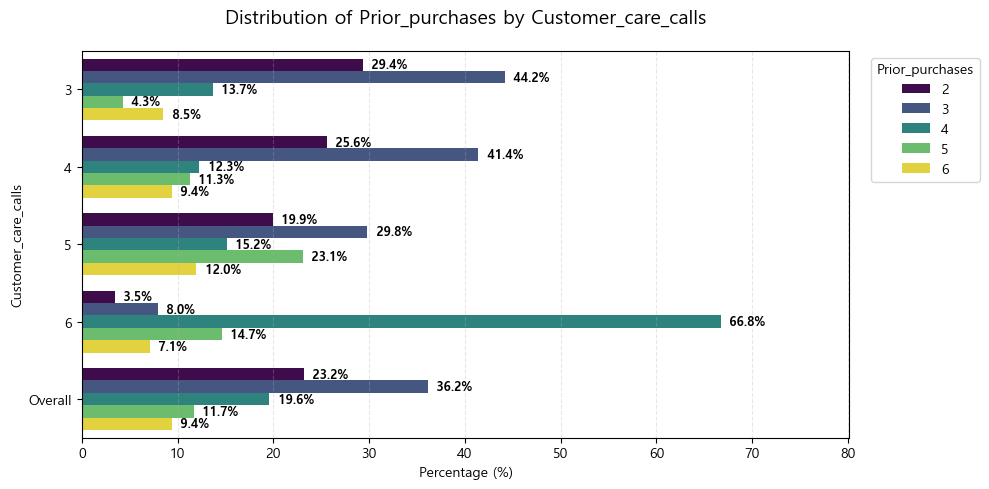


[🚨 이상치 발견] 'Product_importance' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Customer_care_calls,,,
3,1395 (45.0%),1371 (44.2%),334 (10.8%)
4,1370 (47.9%),1264 (44.2%),225 (7.9%)
5,892 (48.5%),790 (43.0%),156 (8.5%)
6,557 (55.6%),392 (39.1%),53 (5.3%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


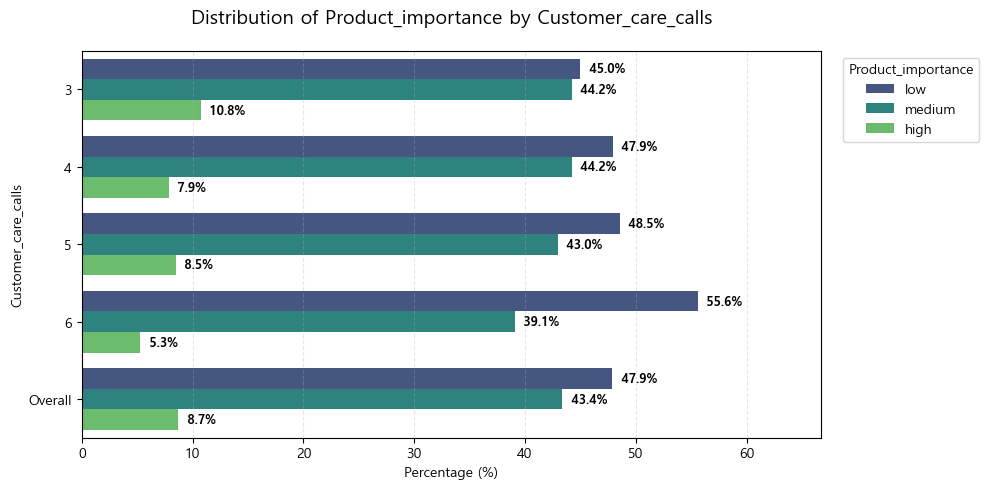

[✅ 이상치 없음] 'Gender': 모든 Customer_care_calls에서 고른 분포를 보입니다.


In [29]:
summarize_categorical_with_plots(train_df, 'Customer_care_calls', cat_cols, threshold=5.0)


[🚨 차이 발견] 'Cost_of_the_Product' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,198.072581,45.021721,96.0,160.00,197.0,237.0,310.0
4,2859.0,205.861840,44.537105,96.0,168.00,209.0,245.0,301.0
5,1838.0,214.638738,44.470881,97.0,179.00,225.0,251.0,307.0
6,1002.0,252.222555,49.119107,98.0,242.25,265.0,286.0,310.0


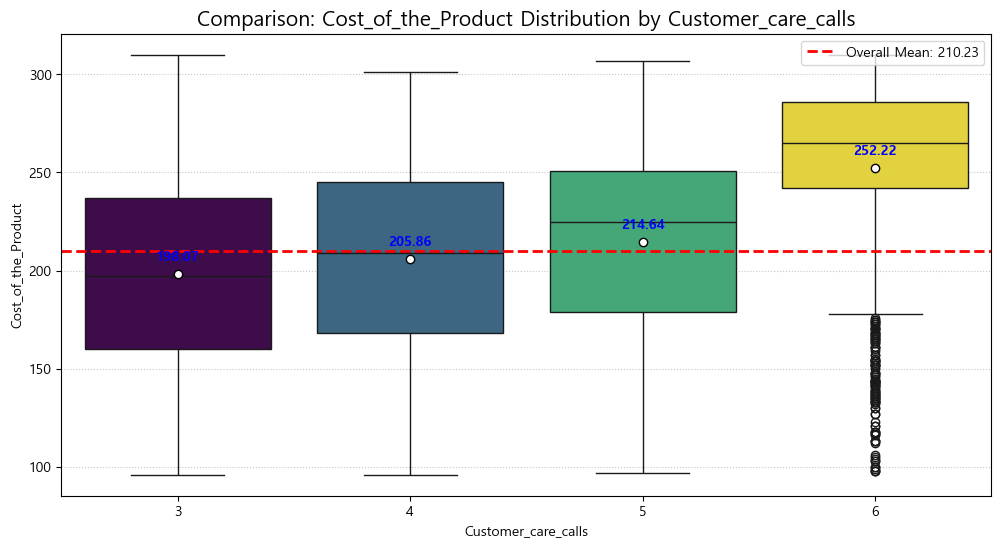


[🚨 차이 발견] 'Discount_offered' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,15.415484,17.528522,1.0,4.0,8.0,19.0,65.0
4,2859.0,13.380553,16.102605,1.0,4.0,7.0,11.0,65.0
5,1838.0,12.633841,15.638064,1.0,4.0,7.0,10.0,65.0
6,1002.0,8.335329,10.579575,1.0,3.0,6.0,9.0,65.0


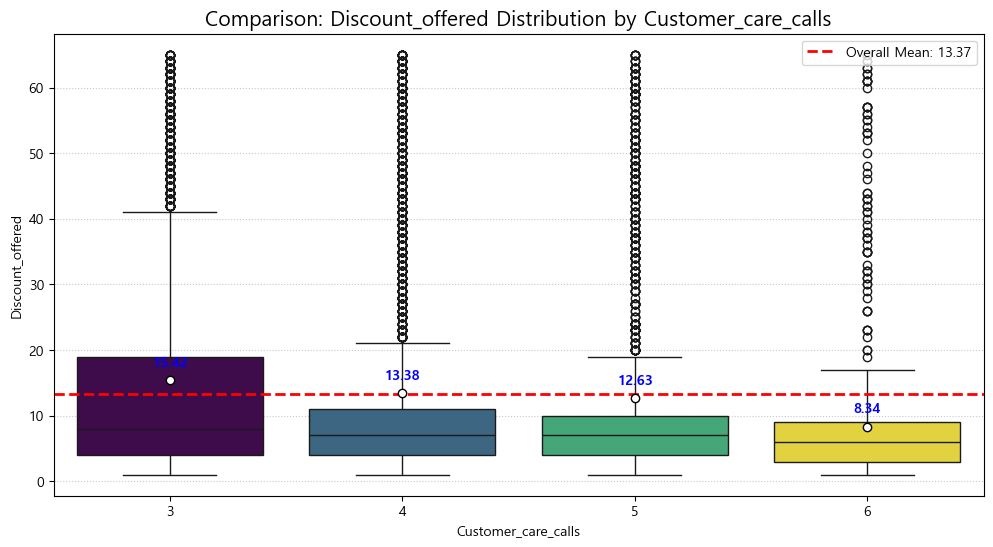


[🚨 차이 발견] 'Weight_in_gms' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,3969.918387,1498.540805,1004.0,2727.00,4372.5,5184.25,7846.0
4,2859.0,3844.457503,1568.115869,1001.0,2270.50,4331.0,5148.50,6000.0
5,1838.0,3468.522307,1653.171112,1001.0,1730.50,3917.0,4946.00,6000.0
6,1002.0,2273.432136,1450.641967,1003.0,1303.25,1660.0,2334.00,5992.0


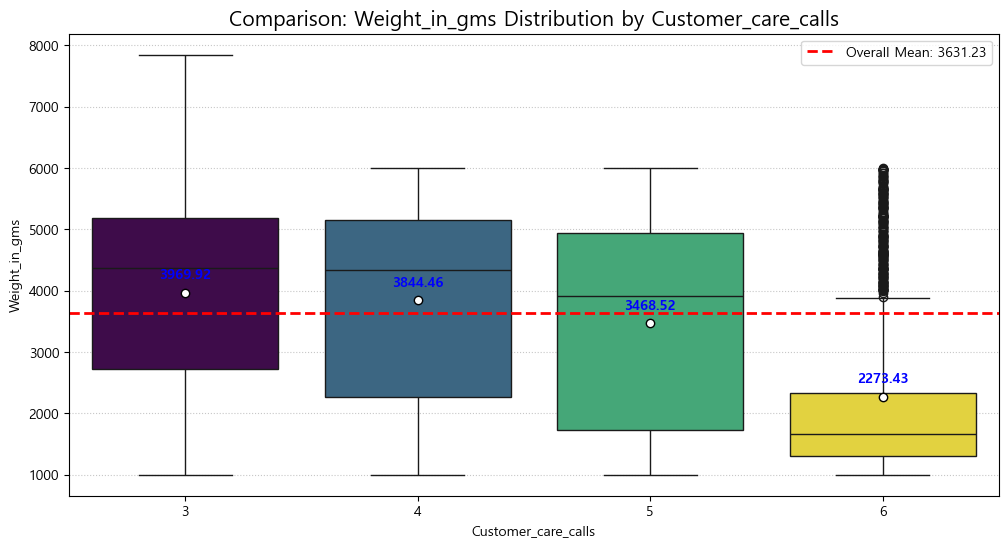

In [30]:
summarize_numeric_with_plots(train_df, 'Customer_care_calls', num_cols, threshold=0.1)

In [31]:
summarize_categorical_with_plots(train_df, 'Customer_rating', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Customer_rating에서 고른 분포를 보입니다.


In [32]:
summarize_numeric_with_plots(train_df, 'Customer_rating', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Prior_purchases에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Prior_purchases,,,,
2,910 (44.6%),731 (35.8%),366 (17.9%),35 (1.7%)
3,1370 (43.1%),1184 (37.2%),548 (17.2%),80 (2.5%)
4,424 (24.6%),351 (20.4%),279 (16.2%),669 (38.8%)
5,132 (12.9%),323 (31.5%),425 (41.4%),147 (14.3%)
6,264 (32.0%),270 (32.7%),220 (26.7%),71 (8.6%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


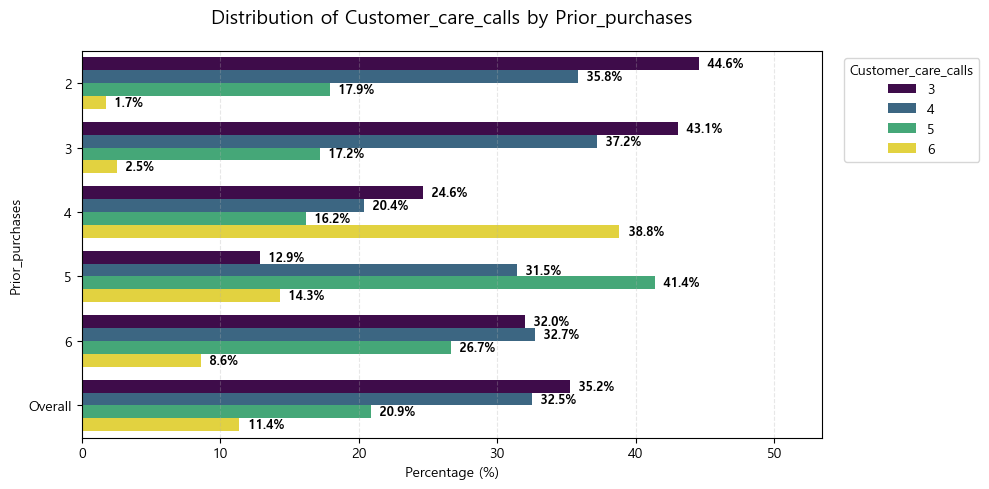

[✅ 이상치 없음] 'Customer_rating': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Product_importance' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Prior_purchases,,,
2,949 (46.5%),894 (43.8%),199 (9.7%)
3,1486 (46.7%),1387 (43.6%),309 (9.7%)
4,887 (51.5%),723 (42.0%),113 (6.6%)
5,574 (55.9%),411 (40.0%),42 (4.1%)
6,318 (38.5%),402 (48.7%),105 (12.7%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


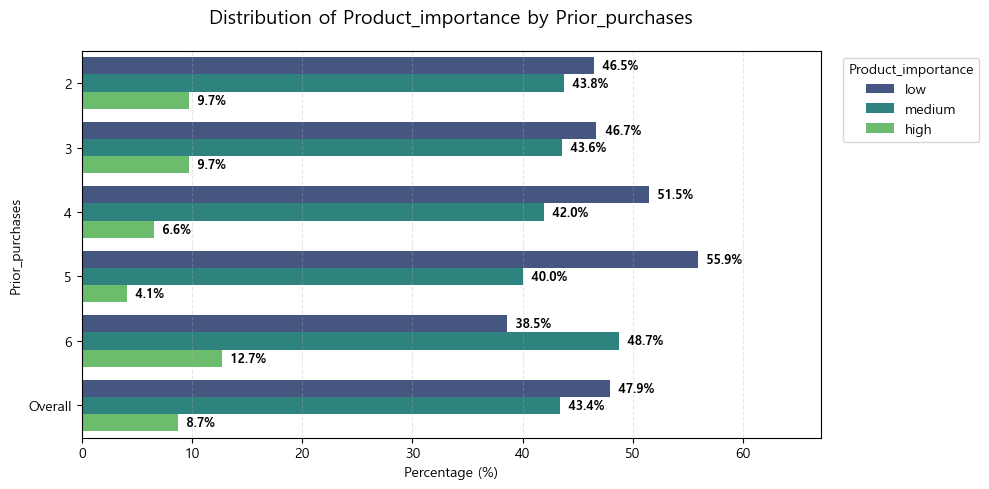

[✅ 이상치 없음] 'Gender': 모든 Prior_purchases에서 고른 분포를 보입니다.


In [33]:
summarize_categorical_with_plots(train_df, 'Prior_purchases', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Discount_offered' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,15.292360,17.313979,1.0,4.0,8.0,20.0,65.0
3,3182.0,15.174104,17.422930,1.0,4.0,7.0,19.0,65.0
4,1723.0,10.647127,13.727382,1.0,3.0,7.0,10.0,65.0
5,1027.0,9.397274,12.121377,1.0,3.0,6.0,9.0,65.0
6,825.0,12.253333,15.314346,1.0,4.0,7.0,10.0,65.0


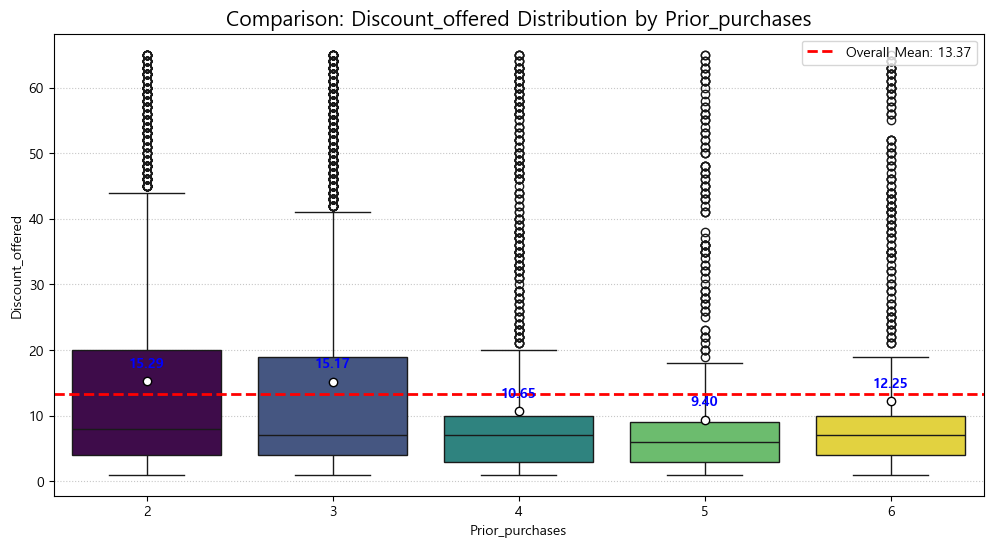


[🚨 차이 발견] 'Weight_in_gms' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,4011.672870,1451.756663,1001.0,2858.50,4374.5,5190.00,6000.0
3,3182.0,4035.417976,1474.620793,1005.0,2866.25,4427.5,5213.75,7846.0
4,1723.0,3122.888566,1702.390639,1003.0,1535.50,2583.0,4781.00,5989.0
5,1027.0,2462.910419,1544.628663,1001.0,1357.50,1736.0,4056.50,5993.0
6,825.0,3646.656970,1624.899209,1003.0,1861.00,4179.0,5035.00,5995.0


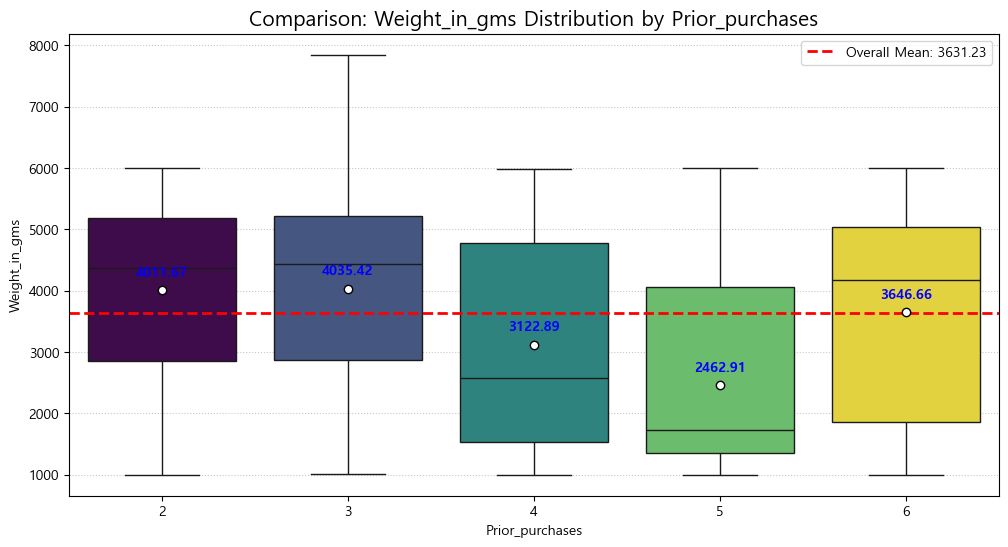

In [34]:
summarize_numeric_with_plots(train_df, 'Prior_purchases', num_cols, threshold=0.1)

[✅ 이상치 없음] 'Warehouse_block': 모든 Product_importance에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Product_importance,,,,
low,1395 (33.1%),1370 (32.5%),892 (21.2%),557 (13.2%)
medium,1371 (35.9%),1264 (33.1%),790 (20.7%),392 (10.3%)
high,334 (43.5%),225 (29.3%),156 (20.3%),53 (6.9%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


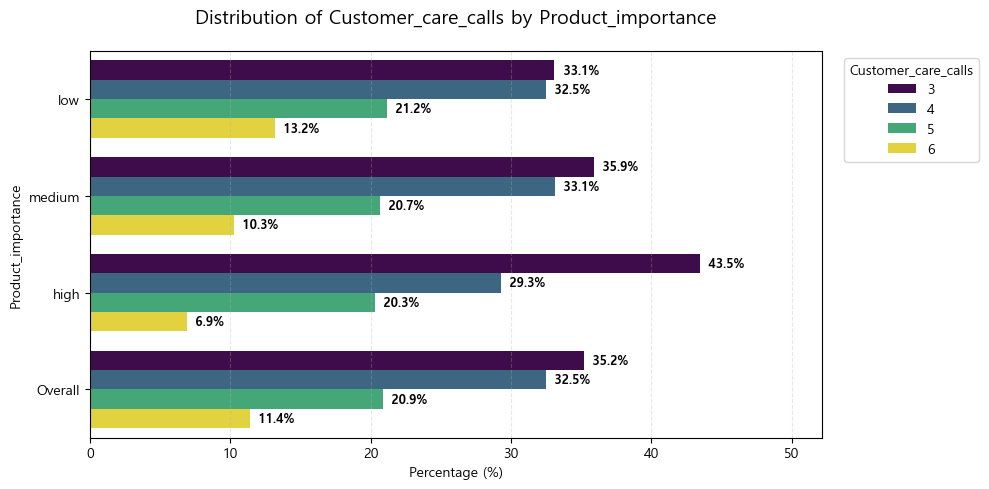

[✅ 이상치 없음] 'Customer_rating': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Product_importance,,,,,
low,949 (22.5%),1486 (35.3%),887 (21.0%),574 (13.6%),318 (7.5%)
medium,894 (23.4%),1387 (36.3%),723 (18.9%),411 (10.8%),402 (10.5%)
high,199 (25.9%),309 (40.2%),113 (14.7%),42 (5.5%),105 (13.7%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


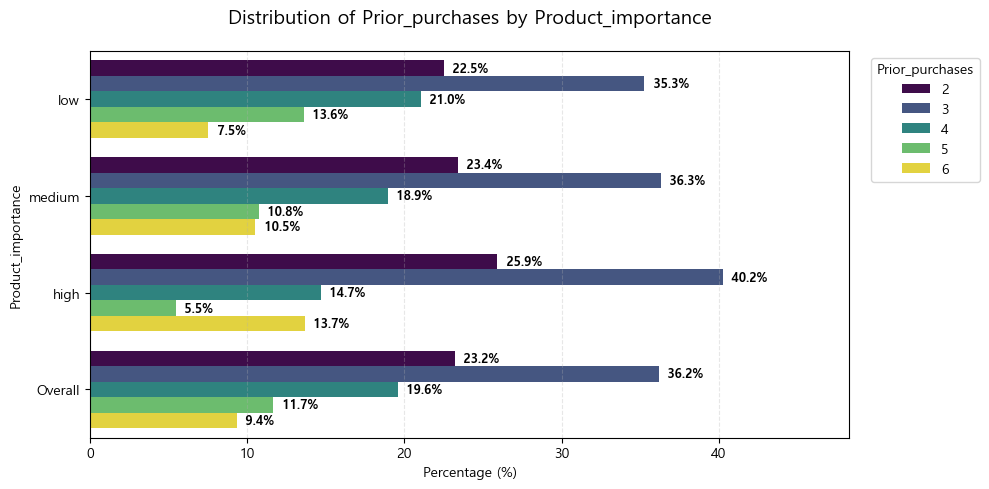

[✅ 이상치 없음] 'Gender': 모든 Product_importance에서 고른 분포를 보입니다.


In [35]:
summarize_categorical_with_plots(train_df, 'Product_importance', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Weight_in_gms' 특성은 Product_importance별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Product_importance,,,,,,,,
low,4214.0,3474.928334,1669.890264,1001.0,1714.00,3996.0,4986.75,5999.0
medium,3817.0,3727.875033,1605.159900,1001.0,1936.00,4212.0,5082.00,7846.0
high,768.0,4008.498698,1474.420311,1007.0,2868.25,4402.0,5195.50,6000.0


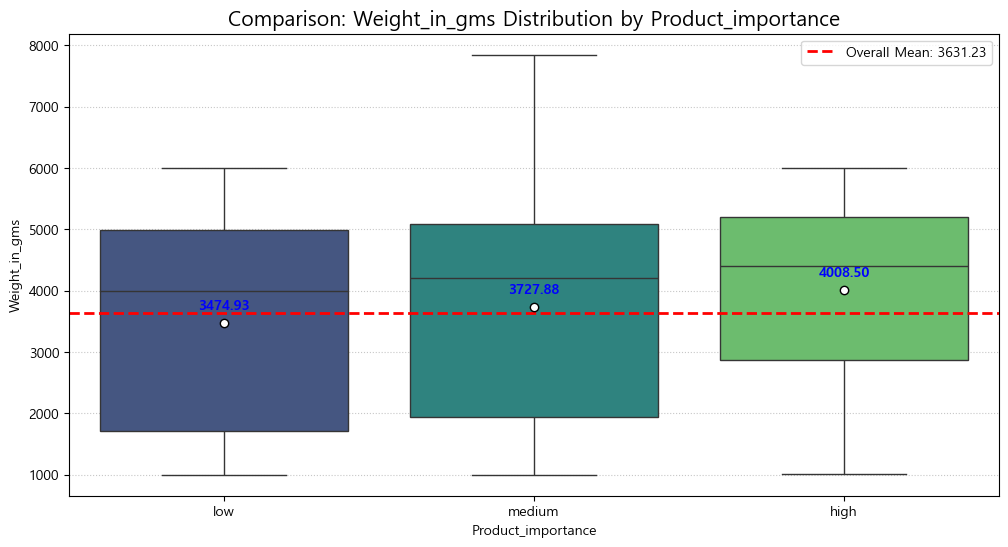

In [36]:
summarize_numeric_with_plots(train_df, 'Product_importance', num_cols, threshold=0.1)

In [37]:
summarize_categorical_with_plots(train_df, 'Gender', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Gender에서 고른 분포를 보입니다.


In [38]:
summarize_numeric_with_plots(train_df, 'Gender', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


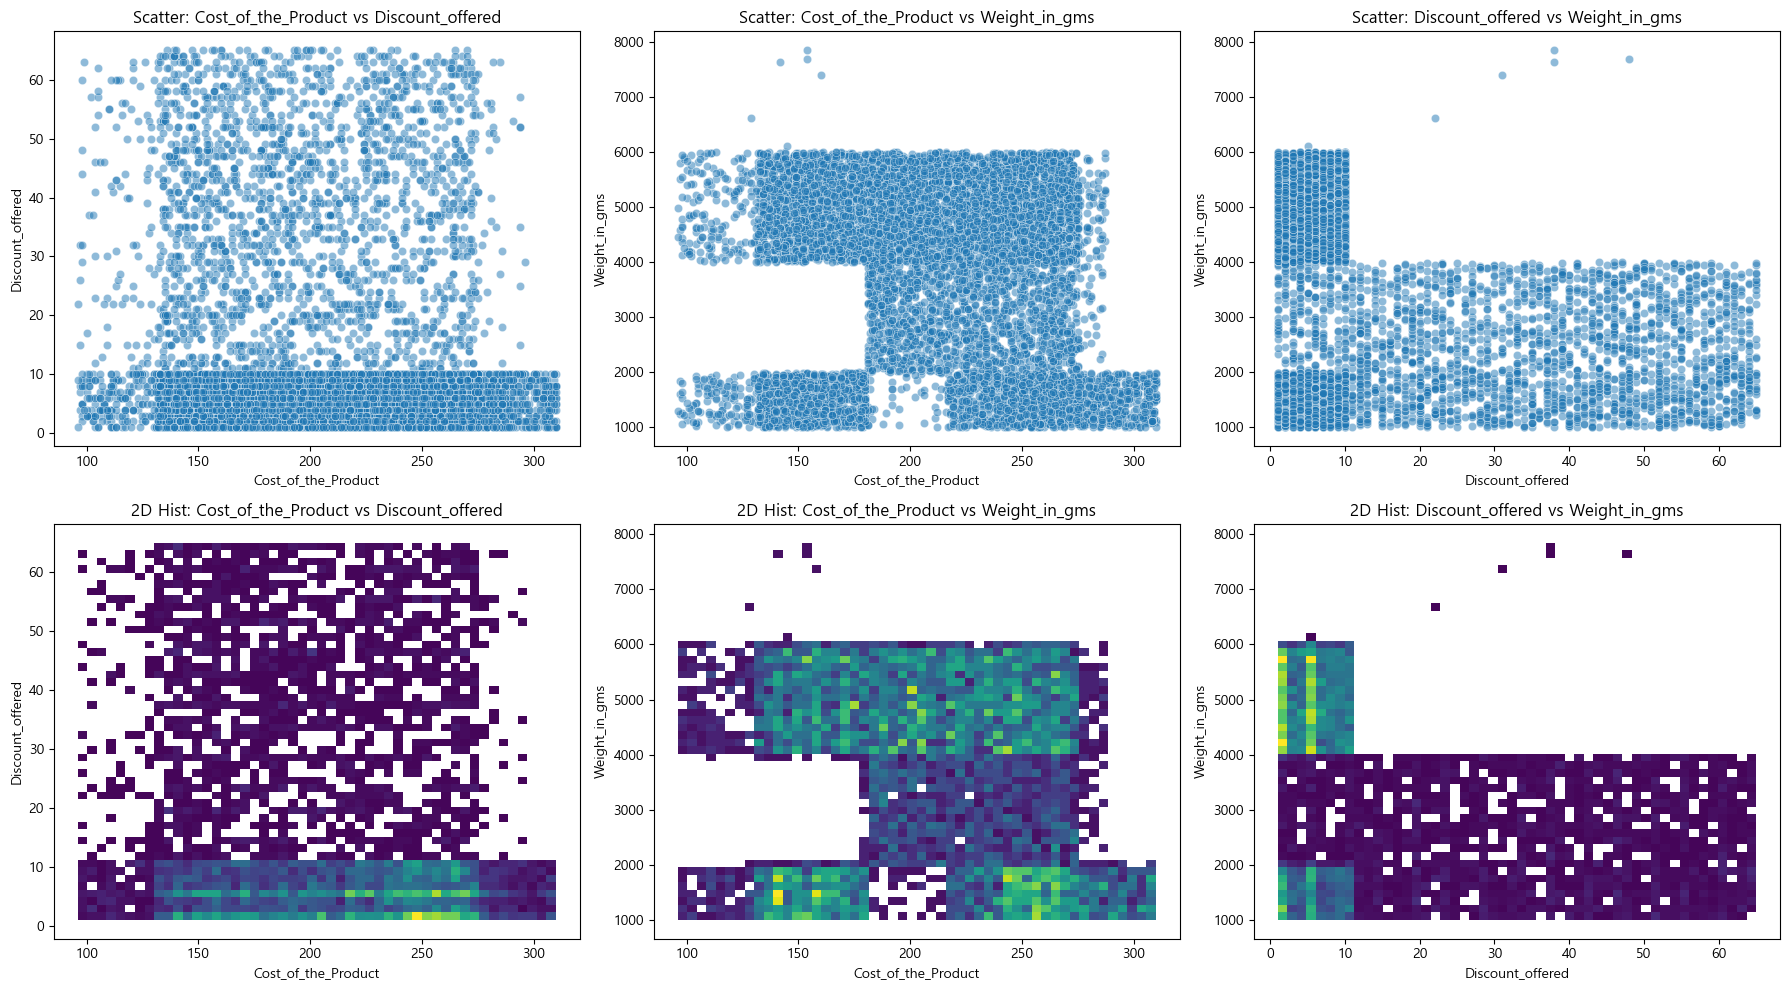

In [39]:
# 2행 3열의 레이아웃 설정
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- 첫 번째 열: 가격(Price) vs 할인액(Discount) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title(f'Scatter: {num_cols[0]} vs {num_cols[1]}')

# 2행: 2D Histplot
sns.histplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[1, 0], bins=50, cmap='viridis', cbar=False)
axes[1, 0].set_title(f'2D Hist: {num_cols[0]} vs {num_cols[1]}')

# --- 두 번째 열: 가격(Price) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title(f'Scatter: {num_cols[0]} vs {num_cols[2]}')

# 2행: 2D Histplot 
sns.histplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[1, 1], bins=50, cmap='viridis', cbar=False)
axes[1, 1].set_title(f'2D Hist: {num_cols[0]} vs {num_cols[2]}')

# --- 세 번째 열: 할인액(Discount) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[0, 2], alpha=0.5)
axes[0, 2].set_title(f'Scatter: {num_cols[1]} vs {num_cols[2]}')

# 2행: 2D Histplot
sns.histplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[1, 2], bins=50, cmap='viridis', cbar=False)
axes[1, 2].set_title(f'2D Hist: {num_cols[1]} vs {num_cols[2]}')

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

## 데이터 비교분석 결과 해석

### 1. Warehouse_block
* A, B, C, D, F 총 5개동
* F동을 제외하고 균일한 비중. F동은 타 동의 2배
* 각 동에 따른 다른 특성의 분포 차이 없음 - 무게, 가격, 운송 수단에 따른 영향이 없다
* 하나의 큰 창고에서 운송일 등 현재 데이터에 없는 기준으로 각 동에 분류하는 것으로 추정


In [40]:
train_df['Warehouse_block'].value_counts()

Warehouse_block
F    2910
B    1487
D    1470
A    1468
C    1464
Name: count, dtype: int64

### 2. Mode_of_Shipment
* Ship, Flight, Road 세 개의 운송 수단
* Ship의 비중이 압도적
* 운송수단에 따른 다른 특성의 분포 차이 없음
    -> 실제로는 가격/무게/부피에 따라 운송수단이 선택되는것을 고려한다면 이상한 데이터.

In [41]:
train_df['Mode_of_Shipment'].value_counts()

Mode_of_Shipment
Ship      5981
Flight    1420
Road      1398
Name: count, dtype: int64

운송 수단과 창고의 영향력을 확인하기 위해 두 변수를 합친다

In [42]:
copy_df = train_df.copy()
copy_df['Wh_Shipment_Combo'] = copy_df['Warehouse_block'].astype(str) + '_' + copy_df['Mode_of_Shipment'].astype(str)
copy_df['Wh_Shipment_Combo'].unique()

array(['D_Road', 'F_Ship', 'B_Ship', 'D_Ship', 'A_Flight', 'B_Road',
       'C_Ship', 'F_Road', 'A_Ship', 'F_Flight', 'D_Flight', 'C_Flight',
       'A_Road', 'B_Flight', 'C_Road'], dtype=object)

--- 조합별 지연율 (상위 10개) ---
                   Delay_Rate
Wh_Shipment_Combo            
D_Flight             0.628205
A_Road               0.619247
F_Flight             0.611111
D_Ship               0.608609
C_Flight             0.607595
B_Flight             0.602510
B_Ship               0.600198
F_Ship               0.596192
A_Ship               0.595745
F_Road               0.594170


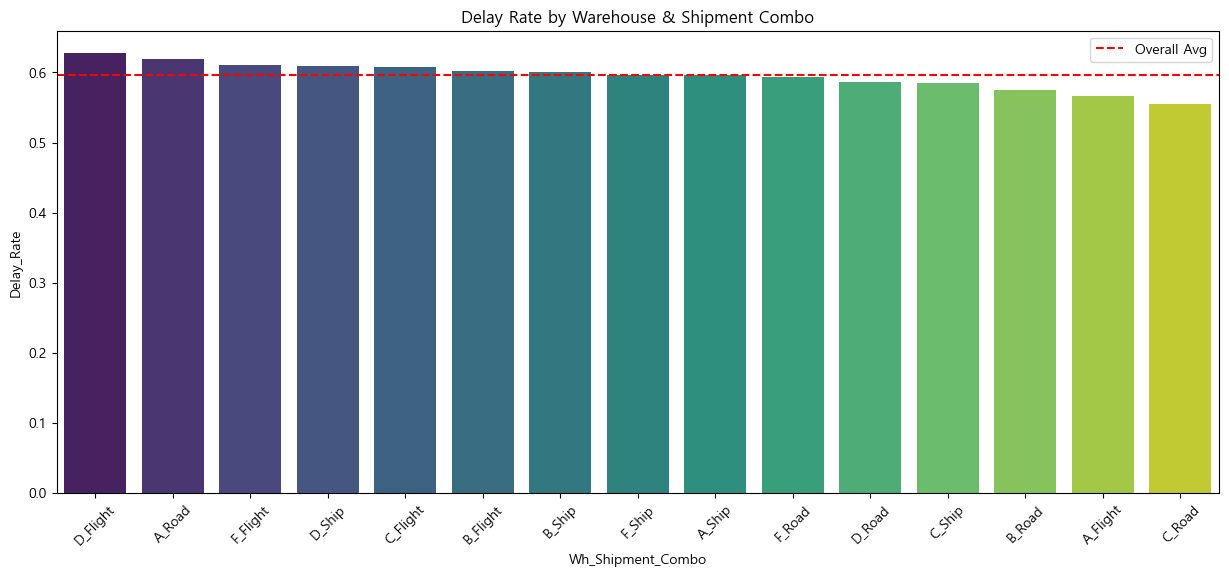

In [43]:
# 조합별 지연율 평균 계산 및 정렬
combo_delay_rate = copy_df.groupby('Wh_Shipment_Combo')[target].mean().sort_values(ascending=False).to_frame()
combo_delay_rate.columns = ['Delay_Rate']

print("--- 조합별 지연율 (상위 10개) ---")
print(combo_delay_rate.head(10))

# 시각화
plt.figure(figsize=(15, 6))
sns.barplot(data=combo_delay_rate.reset_index(), x='Wh_Shipment_Combo', y='Delay_Rate', hue= 'Wh_Shipment_Combo', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title('Delay Rate by Warehouse & Shipment Combo')
plt.axhline(copy_df[target].mean(), color='red', linestyle='--', label='Overall Avg') # 전체 평균선
plt.legend()
plt.show()

미세하지만 항목별로 차이가 존재하는것을 확인

### 3. Prior_purchases
* 2, 3, 4, 5, 6+ 의 구매횟수. 5개 종류
* 지연율은 중간지점은 4, 5에서 점점 낮아지다 6이후에서 다시 증가하는 형태
* 'Prior_purchases'의 분포 확인 결과 4 이후에 급격한 하락.
    -> 잦은 지연에 고객들의 이탈이 발생했을 가능성


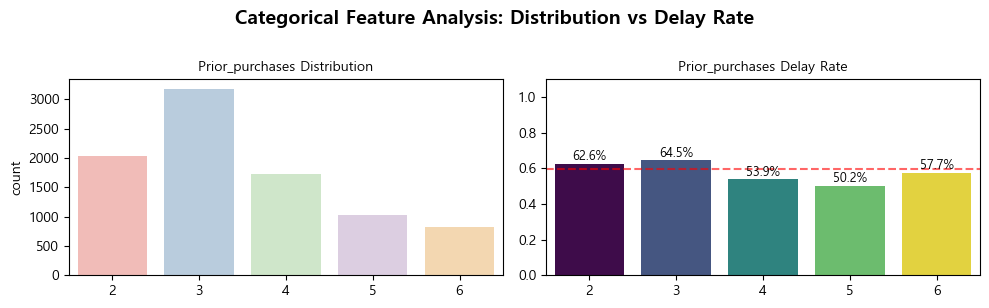

In [44]:
# 6이상의 구매횟수 통합한 버전의 시각화
plot_categorical_analysis(train_df, ['Prior_purchases'], target)

#### 다른 특성과의 관계
##### 'Prior_purchases'와 'Product_importance'
* 구매횟수 2~5: 낮은 중요도의 비중이 상승
* 구매횟수 6: 높은 중요도와 중간 중요도의 비중 급격한 상승
* 가설1: 단골고객(구매횟수>5)에게 중요도가 높은 상품을 구매할 요인이 있나?

가설 1

In [45]:
copy_df['is_loyal'] = (copy_df['Prior_purchases'] > 5).astype(int)
copy_df['is_loyal'].value_counts()

# 분석을 위해 copy_df의 'Product_importance'을 레이블링
importance_map = {'low': 0, 'medium': 1, 'high': 2}
copy_df['Product_importance'] = copy_df['Product_importance'].map(importance_map).astype(int)

# 분석을 위해 추가로 '할인율' 생성
copy_df['Discount_rate'] = (copy_df['Discount_offered'] / copy_df['Cost_of_the_Product'])*100

In [46]:
copy_df.groupby('is_loyal')[['Product_importance', 'Cost_of_the_Product', 'Discount_offered','Discount_rate', target]].agg(['mean', 'median'])

Product_importance        Cost_of_the_Product         \
                       mean median                mean median   
is_loyal                                                        
0                  0.594557    1.0          210.135691  213.0   
1                  0.741818    1.0          211.145455  221.0   

         Discount_offered        Discount_rate           Reached.on.Time_Y.N  \
                     mean median          mean    median                mean   
is_loyal                                                                       
0               13.482192    7.0      7.074021  3.333333            0.598696   
1               12.253333    7.0      6.439064  3.355705            0.576970   

                 
         median  
is_loyal         
0           1.0  
1           1.0

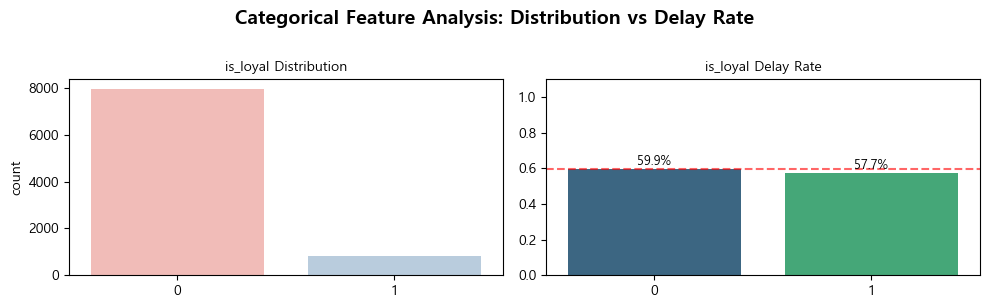

In [47]:
plot_categorical_analysis(copy_df,['is_loyal'], target)

결론
* 'is_loyal'에게 제공되는 유인사항 없음.
* 가격 혜택(할인율) 또는 배송 우대와 같은 혜택이 없음을 확인.
* 지연율에 약 2%의 차이만을 발견 -> 모델학습에 도움을 주지 않을 것으로 판단.

### 4. Customer_rating
* 1, 2, 3, 4, 5 총 5개 등급
* 등급 간 균일한 비중과 지연율을 보임(최대 3.2%의 차이).
* 지연율과의 경향성, 상관관계 없음
* 각 등급에 따른 다른 특성의 분포 차이 없음
* 현재 데이터에 없는 기준(예를 들어 물품에 대한 만족도)이 적용된 등급으로 추정


### 5. Gender

In [48]:
train_df['Product_importance'].value_counts(normalize=True)

Product_importance
low       0.478918
medium    0.433799
high      0.087283
Name: proportion, dtype: float64

### 6. 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms'
* Discount_offered와 Discount_offered는 구간별 지연율의 변화가 확연한 곳이 존재.
* 더 자세한 분석을 위해 구간을 나눠 수치 분석.
* 생성 가능한 파생변수 목록
    1. 세 데이터의 범주화
    2. 할인율: 1-(discount/cost)
    3. 할인가: cost-discount
    4. 무게당 가격: cost/weight


구간별 시각화 분석

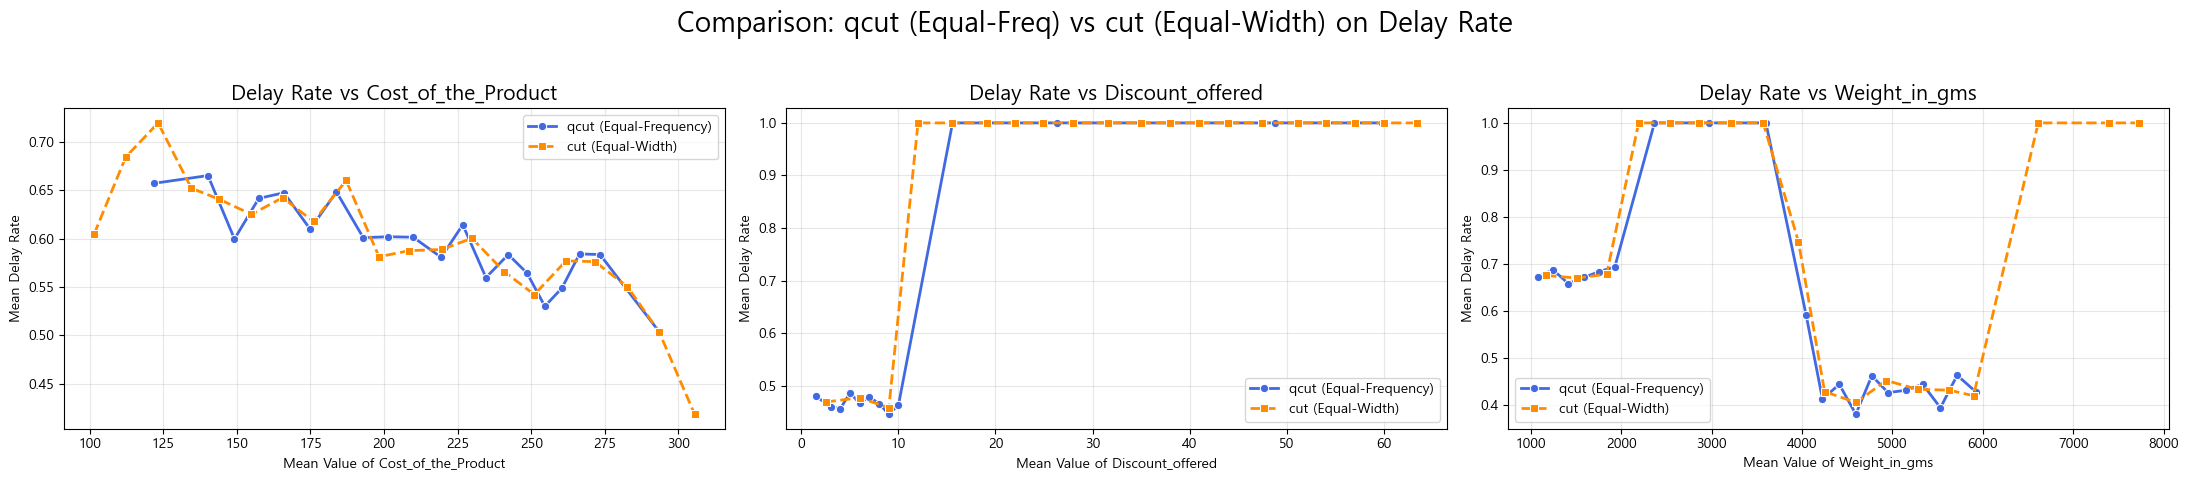

In [49]:
# 1. 분석할 수치형 변수 리스트
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

# 2. 서브플롯 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Comparison: qcut (Equal-Freq) vs cut (Equal-Width) on Delay Rate', fontsize=20)

for i, col in enumerate(features):
    temp_df = copy_df.copy()
    
    # --- A. qcut (데이터 개수 균등) 계산 ---
    temp_df['qcut_Bin'] = pd.qcut(temp_df[col], q=20, duplicates='drop')
    qcut_stats = temp_df.groupby('qcut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- B. cut (수치 거리 균등) 계산 ---
    temp_df['cut_Bin'] = pd.cut(temp_df[col], bins=20)
    cut_stats = temp_df.groupby('cut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- 시각화 ---
    # 1. qcut 라인 (파란색)
    sns.lineplot(x=qcut_stats[col], y=qcut_stats[target], marker='o', 
                 ax=axes[i], label='qcut (Equal-Frequency)', color='royalblue', linewidth=2)
    
    # 2. cut 라인 (주황색)
    sns.lineplot(x=cut_stats[col], y=cut_stats[target], marker='s', 
                 ax=axes[i], label='cut (Equal-Width)', color='darkorange', linewidth=2, linestyle='--')
    
    axes[i].set_title(f'Delay Rate vs {col}', fontsize=15)
    axes[i].set_xlabel(f'Mean Value of {col}')
    axes[i].set_ylabel('Mean Delay Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* cost: 가격의 증가에 따라 지연율이 감소하는 우하향 그래프. 범주 전환 불필요
* discount: 10을 초과하는 상품은 지연율 100%. 범주를 나누고 10 이하를 상세 분석
* weight: 2000~4000의 지연율 높은구간, 6000 이후의 표본은 몇인지 조사 필요

1. discount

In [50]:
# 할인액 > 10인 구간에서 지연율 
print(copy_df.loc[copy_df['Discount_offered']==10][target].mean())
print(copy_df.loc[copy_df['Discount_offered']>10][target].mean())

0.4632352941176471
1.0


In [51]:
# 할인액 10 이하 구간의 지연율은 비슷하다는 것을 발견.
copy_df.groupby('Discount_offered')[target].mean().head(10)

Discount_offered
1     0.480061
2     0.479256
3     0.460366
4     0.456325
5     0.485981
6     0.467057
7     0.478593
8     0.465857
9     0.445906
10    0.463235
Name: Reached.on.Time_Y.N, dtype: float64

In [52]:
# 'Discount_group' 생성
copy_df['Discount_group'] = (copy_df['Discount_offered'] > 10).astype(int)
copy_df['Discount_group'].value_counts()

Discount_group
0    6673
1    2126
Name: count, dtype: int64

2. weight

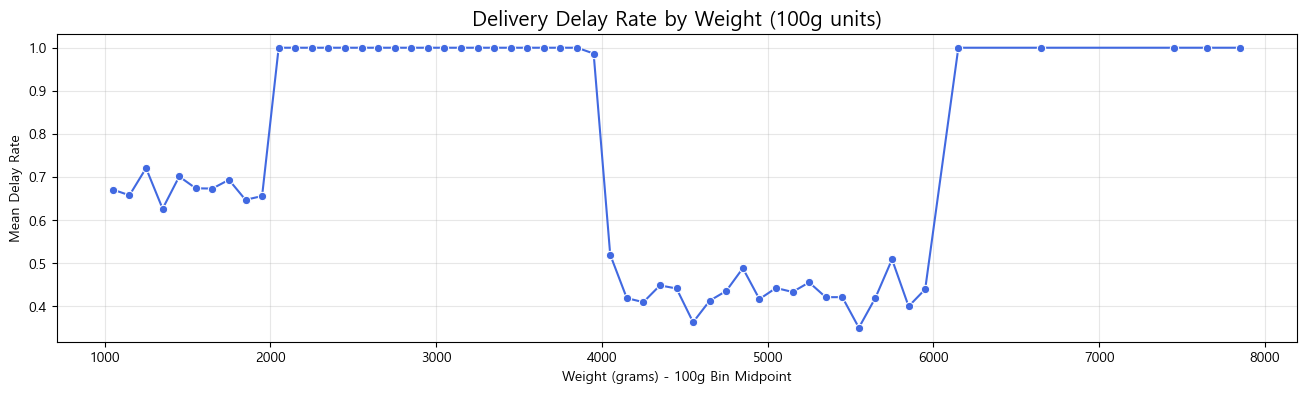

In [53]:
# 세밀한 분석을 위해 100 단위로 나누어 시각화

# 1. 100단위로 구간(bins) 생성
bins_100 = list(range(1000, 8001, 100))
copy_df['Weight_Bin_100'] = pd.cut(copy_df['Weight_in_gms'], bins=bins_100)

# 2. X축에 표시할 값을 구간의 '중간값(mid)'으로 변환 (숫자형으로 시각화하기 위함)
copy_df['Weight_Bin_Mid'] = copy_df['Weight_Bin_100'].apply(lambda x: x.mid if pd.notnull(x) else None).astype(float)

# 3. 시각화
plt.figure(figsize=(16, 4))
sns.lineplot(data=copy_df, x='Weight_Bin_Mid', y=target, marker='o', errorbar=None, color='royalblue')
plt.title('Delivery Delay Rate by Weight (100g units)', fontsize=15)
plt.xlabel('Weight (grams) - 100g Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()

* 무게 6000 이상의 데이터는 100%의 지연율을 보인다.
* 데이터가 너무 적어 이상치일 가능성이 있지만, 2000을 단위로 지연율이 변화하는 것으로 보아 2000~4000의 '위험' 존에 묶기로 하자.
* 무게 구간을 지연율이 낮은 순서부터 1, 2, 3으로 맵핑

In [54]:
# 조건 리스트 정의
conditions = [
    (copy_df['Weight_in_gms'] >= 4000) & (copy_df['Weight_in_gms'] < 6000), 
    (copy_df['Weight_in_gms'] >= 0) & (copy_df['Weight_in_gms'] < 2000)     
]
# 해당 조건에 대응하는 값 리스트
choices = [0, 1]
# 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
copy_df['Weight_Category'] = np.select(conditions, choices, default=2)

3. 할인율 Discount_rate
    

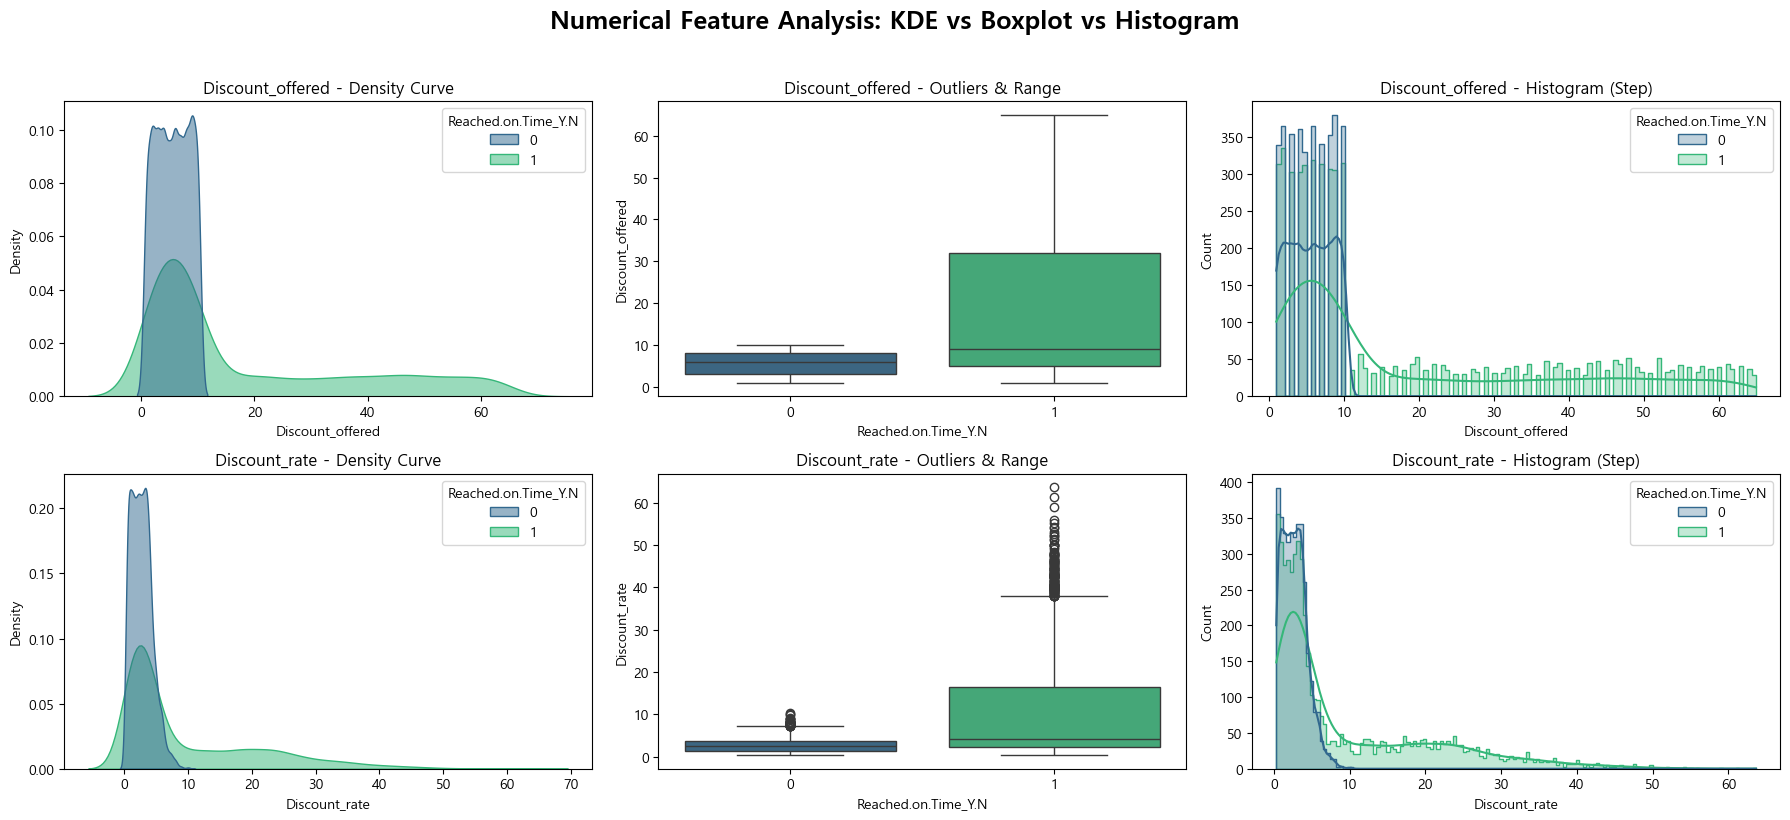

Discount_offered    0.398429
Discount_rate       0.381533
Name: Reached.on.Time_Y.N, dtype: float64


In [55]:
# 할인액과 할인율 비교
plot_numeric_analysis(copy_df, ['Discount_offered', 'Discount_rate'], target)
print(copy_df[['Discount_offered', 'Discount_rate', target]].corr()[target].drop(target))

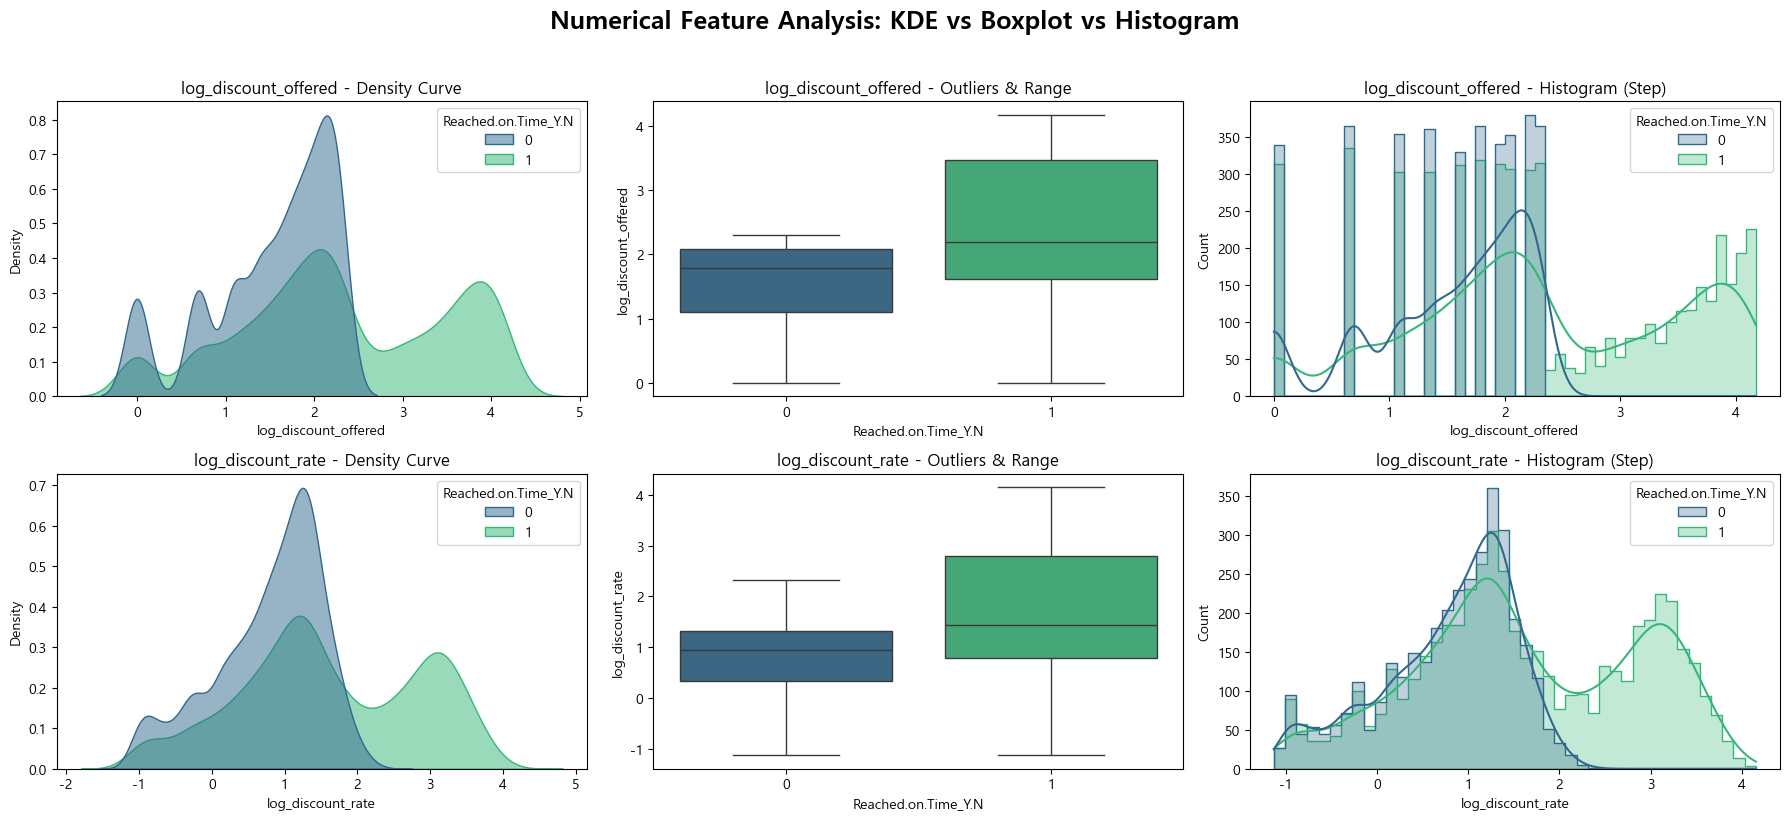

log_discount_offered    0.365141
log_discount_rate       0.362631
Name: Reached.on.Time_Y.N, dtype: float64


In [56]:
copy_df['log_discount_offered'] = np.log(copy_df['Discount_offered'])
copy_df['log_discount_rate'] = np.log(copy_df['Discount_rate'])

plot_numeric_analysis(copy_df, ['log_discount_offered', 'log_discount_rate'], target)
print(copy_df[['log_discount_offered', 'log_discount_rate', target]].corr()[target].drop(target))

Discount_offered의 상관계수가 가장 높다.

4. 할인가 Discounted_price

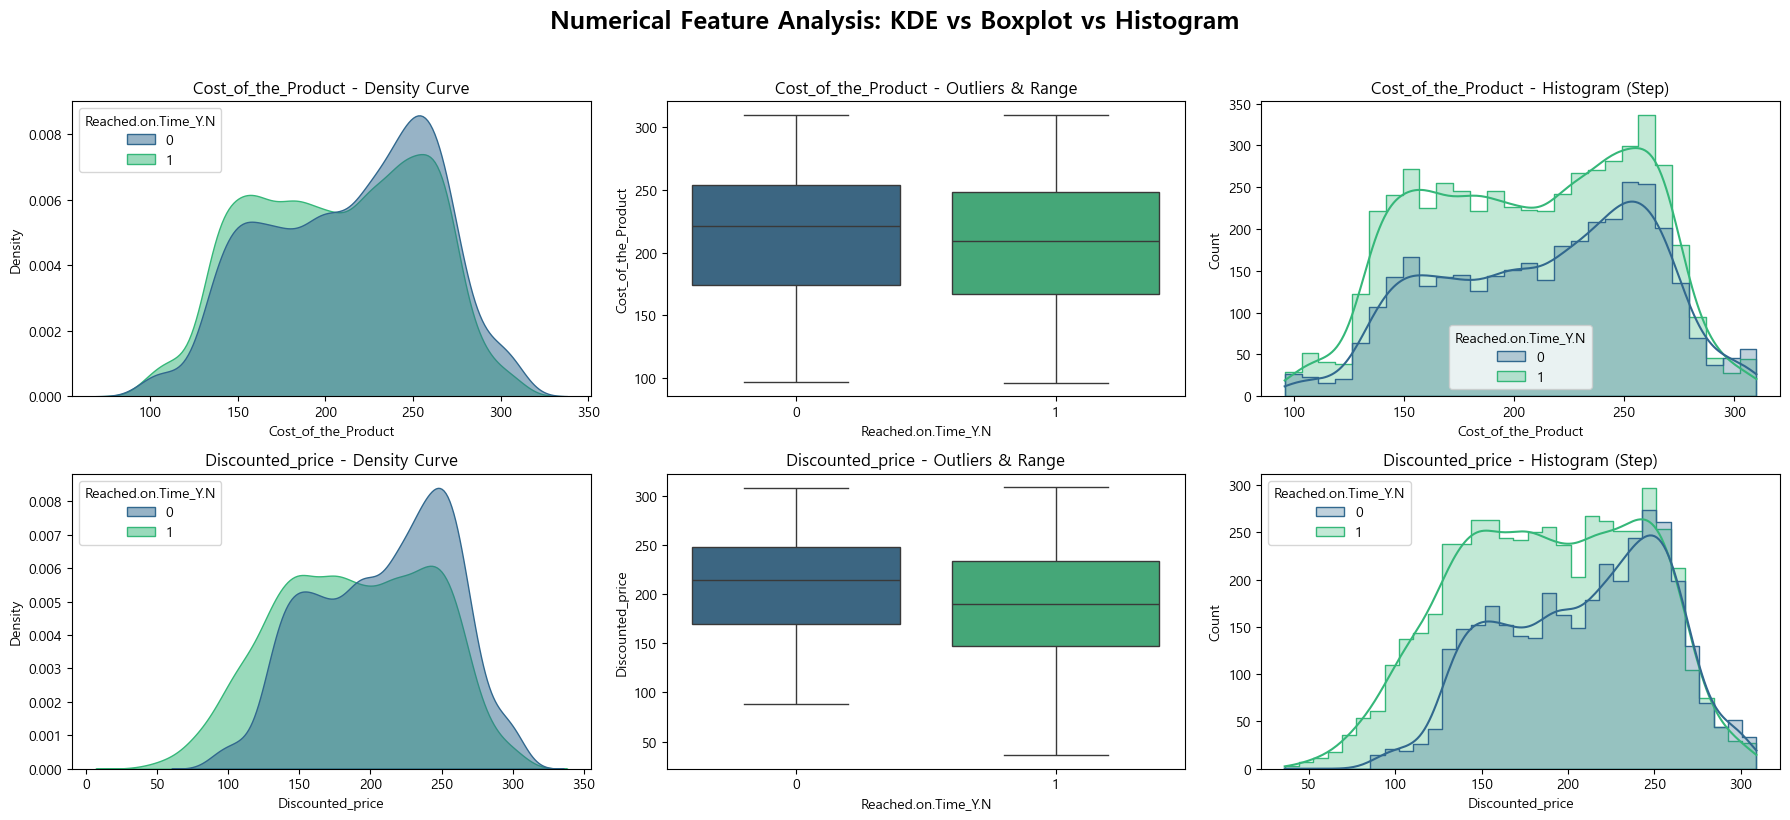

Discounted_price      -0.189176
Cost_of_the_Product   -0.073743
Name: Reached.on.Time_Y.N, dtype: float64


In [57]:
# 원가와 실구매가 비교 -> 실구매가가 더 나은 지표
copy_df['Discounted_price'] = copy_df['Cost_of_the_Product'] - copy_df['Discount_offered']
plot_numeric_analysis(copy_df, ['Cost_of_the_Product', 'Discounted_price'], target)
print(copy_df[['Discounted_price', 'Cost_of_the_Product', target]].corr()[target].drop(target))

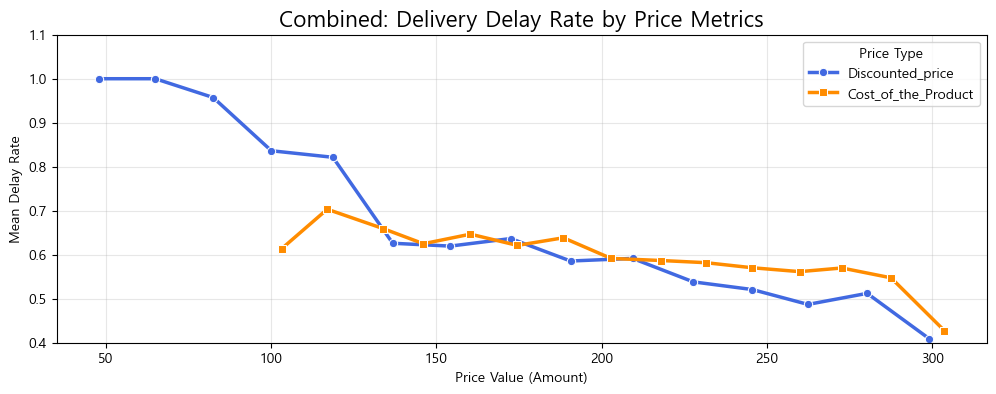

In [58]:
plt.figure(figsize=(12, 4))

# 분석할 두 타겟 변수
features = ['Discounted_price', 'Cost_of_the_Product']
colors = ['royalblue', 'darkorange']
markers = ['o', 's']

for col, color, marker in zip(features, colors, markers):
    temp_df = copy_df.copy()
    
    # 15개 정도로 더 세밀하게 구간 분할
    temp_df['Bin'] = pd.cut(temp_df[col], bins=15)
    
    # 구간별 평균 및 지연율 계산
    bin_stats = temp_df.groupby('Bin', observed=False).agg({
        col: 'mean',
        target: 'mean'
    }).dropna()
    
    # 하나의 axes에 겹쳐서 그리기
    sns.lineplot(x=bin_stats[col], y=bin_stats[target], marker=marker, 
                 label=col, color=color, linewidth=2.5)

plt.title('Combined: Delivery Delay Rate by Price Metrics', fontsize=16)
plt.xlabel('Price Value (Amount)')
plt.ylabel('Mean Delay Rate')
plt.legend(title='Price Type')
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.1) # 변화를 잘 보이게 하기 위해 범위를 조절

plt.show()

5. 무게당 가격 price_per_weight

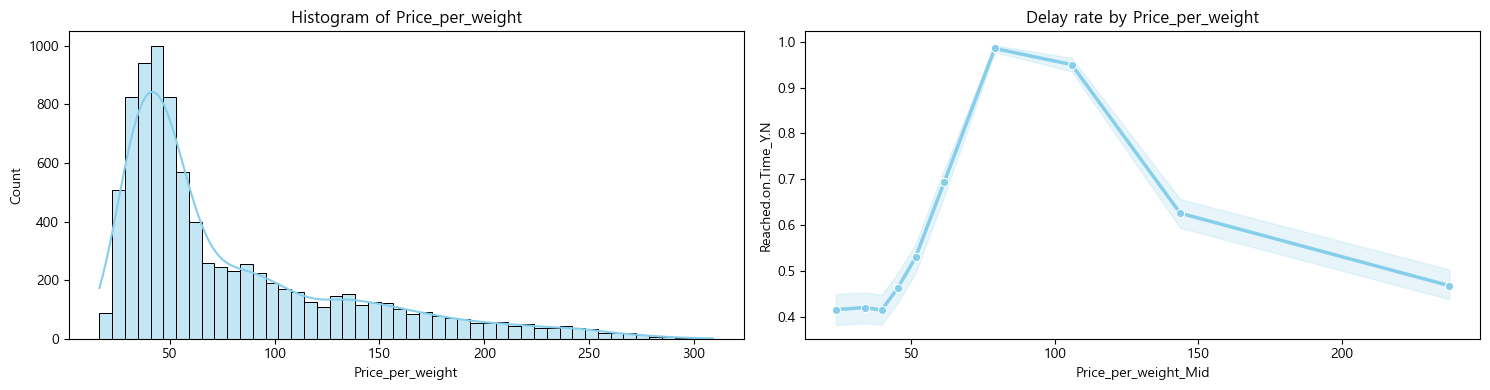

In [59]:
# 무게를 kg으로 변환하고 무게당 가격을 구한다.
copy_df['Price_per_weight'] = copy_df['Cost_of_the_Product'] / (copy_df['Weight_in_gms'] / 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 2. 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['Price_per_weight_Bin'] = pd.qcut(copy_df['Price_per_weight'], q=10, duplicates='drop')
# 3. 구간별 중간값(X축용) 계산
copy_df['Price_per_weight_Mid'] = copy_df['Price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)

# [왼쪽] 히스토그램 + KDE (전체적인 분포 모양)
sns.histplot(copy_df['Price_per_weight'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Price_per_weight')

# [오른쪽] 히스토그램 (이상치 및 사분위수 확인)
sns.lineplot(data=copy_df, x='Price_per_weight_Mid', y=target, ax=axes[1], marker='o', color='skyblue', linewidth=2.5)
axes[1].set_title('Delay rate by Price_per_weight')

plt.tight_layout()
plt.show()

In [60]:
corr_val = copy_df[['Price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (Price_per_weight vs Target): {corr_val:.4f}")

📊 상관계수 (Price_per_weight vs Target): 0.0801


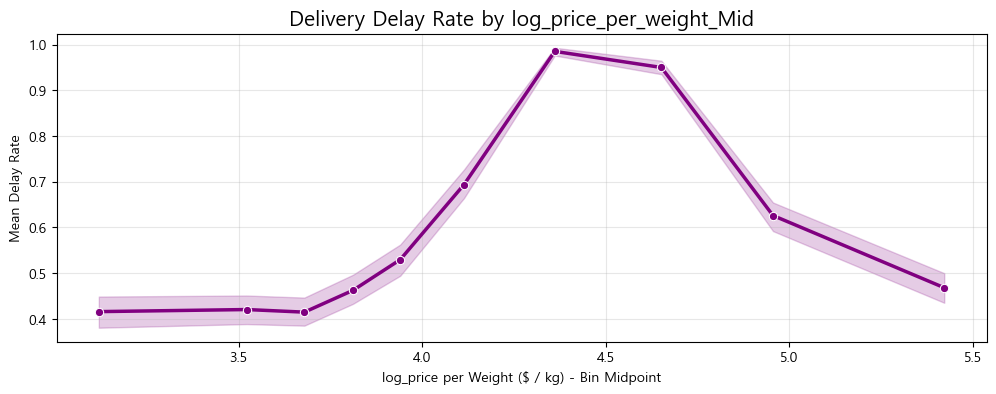

In [61]:
# Price_per_weight의 분포가 편향되었기 때문에 log를 취한다
copy_df['log_price_per_weight'] = np.log(copy_df['Price_per_weight'])

# 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['log_price_per_weight_Bin'] = pd.qcut(copy_df['log_price_per_weight'], q=10, duplicates='drop')
# 구간별 중간값(X축용) 계산
copy_df['log_price_per_weight_Mid'] = copy_df['log_price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)
# 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='log_price_per_weight_Mid', y=target, marker='o', color='purple', linewidth=2.5)
plt.title('Delivery Delay Rate by log_price_per_weight_Mid', fontsize=15)
plt.xlabel('log_price per Weight ($ / kg) - Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)



In [62]:
corr_val = copy_df[['log_price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (log_price_per_weight vs Target): {corr_val:.4f}")
plt.show()

📊 상관계수 (log_price_per_weight vs Target): 0.1728


새로운 파생변수 'Discount_group', 'Weight_Category', 'Discounted_price', 'log_price_per_weight'를 생성하였다

### 7. Product_importance
* high, medium, low 3개의 등급.
* high의 비중이 8%로 굉장히 적다.
* 중요도 high인 제품의 지연율이 역설적이게도 가장 높다. (지연율 64.8%)


* 가설1: 중요도의 기준은 제품의 중요도가 아닌 다른 기준이 있는가?

가설  검증
1. 중요도에 따라 제품과 관계된 지표가 어떻게 움직이는지 관찰

In [63]:
# 데이터 집계 (평균과 중앙값 모두 계산)
agg_dict = {col: ['mean', 'median'] for col in [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases'
]}
agg_dict['Reached.on.Time_Y.N'] = ['mean']

# 집계 결과 생성
result_table = copy_df.groupby('Product_importance').agg(agg_dict)


display(result_table.style.background_gradient(cmap='Blues').format("{:.2f}"))

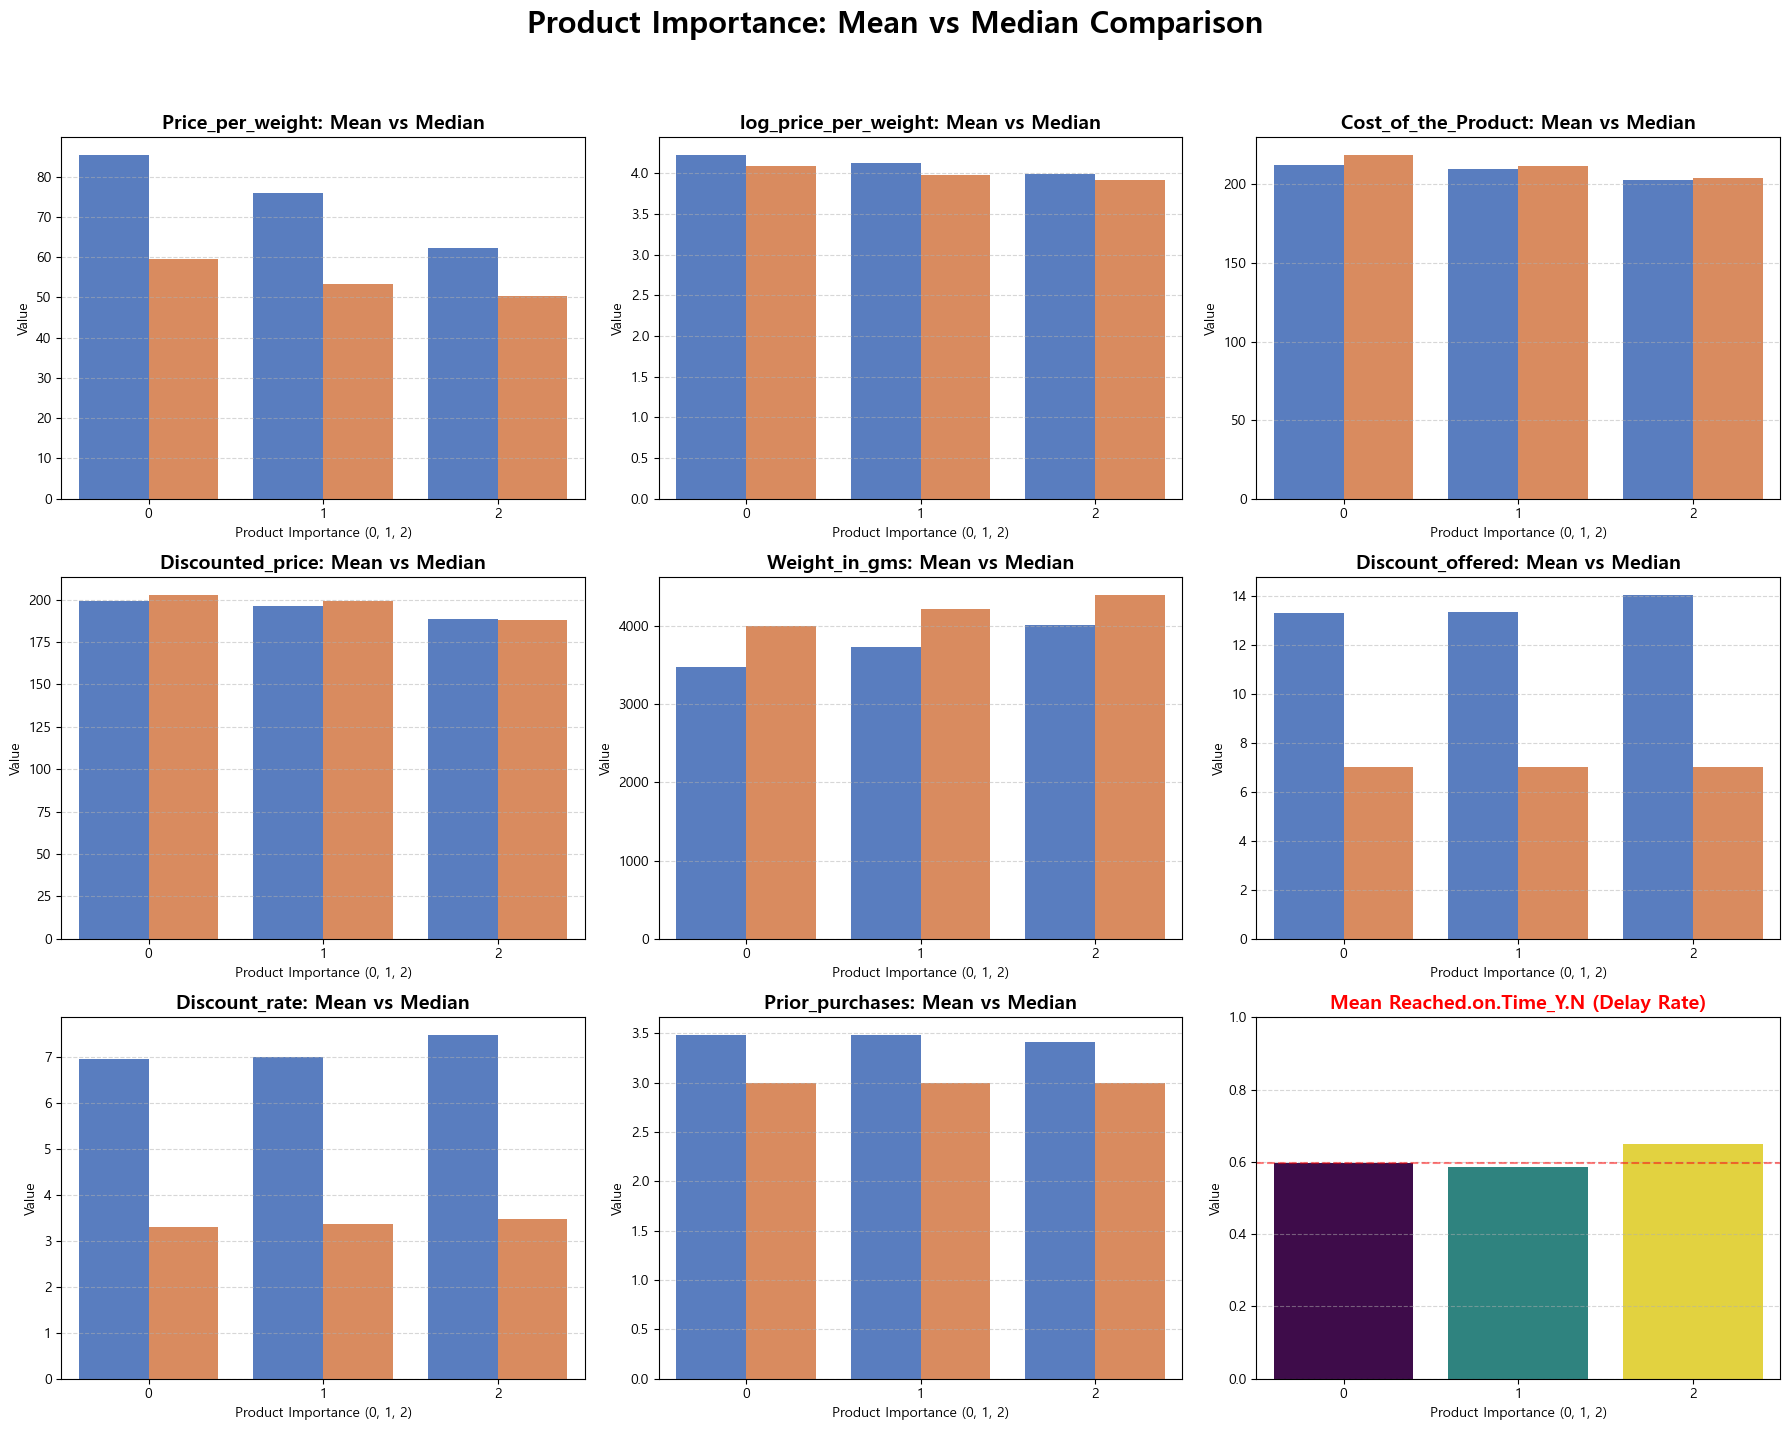

In [64]:
# 집계 및 멀티인덱스 칼럼 평탄화
result = copy_df.groupby('Product_importance').agg(agg_dict)
result.columns = [f"{col}_{stat}" for col, stat in result.columns]

# 시각화를 위한 변수 설정
cols_base = [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases', 'Reached.on.Time_Y.N'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Product Importance: Mean vs Median Comparison', fontsize=22, fontweight='bold', y=0.98)

# 범례 핸들과 라벨을 저장할 변수
handles, labels = None, None

for i, col in enumerate(cols_base):
    row, col_idx = divmod(i, 3)
    ax = axes[row, col_idx]
    
    if col == 'Reached.on.Time_Y.N':
        # 지연율: 단일 지표이므로 범례 불필요
        sns.barplot(data=copy_df, x='Product_importance', y=col, ax=ax, hue='Product_importance', palette='viridis', legend=False, errorbar=None)
        ax.set_title(f'Mean {col} (Delay Rate)', fontsize=14, fontweight='bold', color='red')
        ax.axhline(copy_df[col].mean(), color='red', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
    else:
        # 평균과 중앙값 비교 데이터 구성
        plot_df = result[[f"{col}_mean", f"{col}_median"]].reset_index().melt(
            id_vars='Product_importance', value_vars=[f"{col}_mean", f"{col}_median"],
            var_name='Stat', value_name='Value'
        )
        plot_df['Stat'] = plot_df['Stat'].str.replace(f"{col}_", "")
        
        # legend=False를 추가하여 개별 subplot의 범례를 제거
        sns.barplot(data=plot_df, x='Product_importance', y='Value', hue='Stat', ax=ax, palette='muted', legend=False)
        ax.set_title(f'{col}: Mean vs Median', fontsize=14, fontweight='bold')

        # 첫 번째 대상 그래프에서만 범례 정보를 추출
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    ax.set_xlabel('Product Importance (0, 1, 2)')
    ax.set_ylabel('Value')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 전체 피규어의 우측 상단에 범례 추가
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title='Statistics', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

importance 분석 결론
* 무게 대비 가격이 싼 물품을 'high'에, 비싼 물품을 'low'에 배정
* 그 외의 할인액 등의 가격적인 측면은 영향력 미미

결론: Product_importance는 관리 후순위 지표

### 8. Customer_care_calls
* 2~7의 데이터가 있으나 너무 적은 데이터는 통합
* 3, 4, 5, 6회의 전화 문의
* 문의가 많아질수록 지연율이 적어짐을 확인
* 문의 횟수의 최소값이 2라는 점은 배송이 지연되지 않았을 때의 수치라고 하기에는 이상함
* 가설 1: 이 데이터는 현재 배송에 대한 문의가 아니라, 지금까지 누적되어온 횟수이다.
* 가설 2: 배송에 대한 상태를 알리기 위해 회사측이 발송한 안내 횟수이다.
    - 즉, 회사에서 특별 관리하는 화물을 알리는 지표이다.


가설 1 검증
* Customer_care_call이 과거부터 누적되어온 수치라면, 구매횟수가 증가할수록 call의 횟수도 증가할것이다.

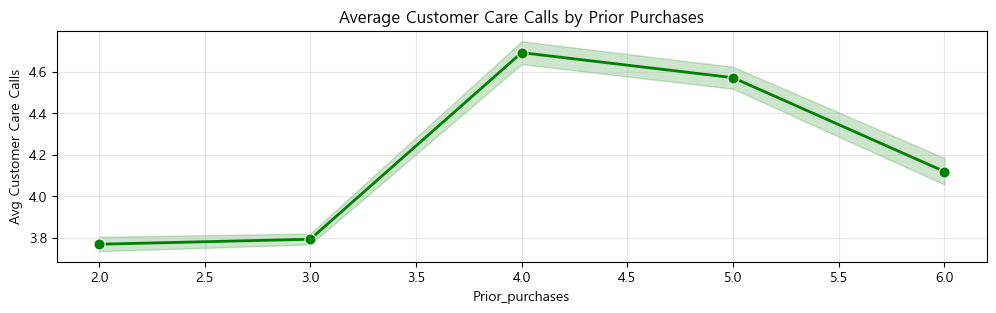

📊 두 변수의 상관계수: 0.2559


In [65]:
# 과거 구매 횟수에 따른 문의 횟수의 증가 시각화

plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=train_df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = train_df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

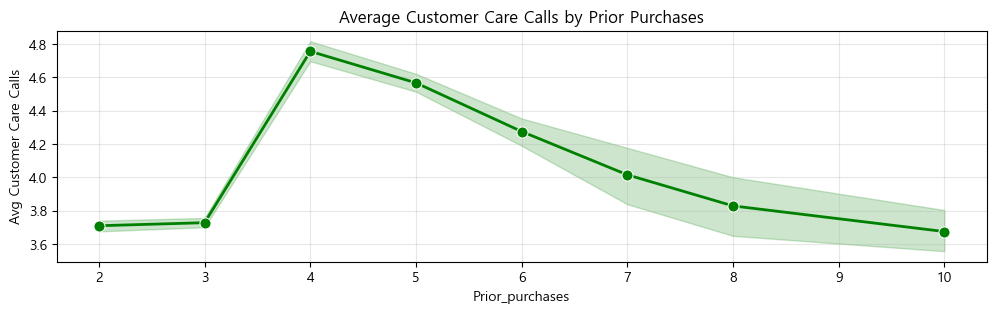

📊 두 변수의 상관계수: 0.1808


In [66]:
plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

가설 검증 해석
* 가공 전/후의 데이터가 모두 4 이후에서 감소하는 모양
* 상관관계도 가공 전 0.18, 가공 후 0.26
* 이는 2가지 가능한 결론
    1. 누적된 기록이 아닌, 해당 배송에 대한 기록이다. -> 정시 배송에도 문의횟수 2는 설명이 안됨
    2. 해당 회사에서의 구매 경험이 많은 사람은 지연에 큰 신경을 쓰지 않는다.
    
'Calls_per_Purchase'를 만들고, 지연율과의 관계를 확인해본다

In [67]:
copy_df['Calls_per_Purchase'] = (copy_df['Customer_care_calls'] / copy_df['Prior_purchases']).round(2)

In [68]:
# 상관계수 계산
correlation = copy_df[['Calls_per_Purchase', target]].corr().iloc[0, 1]
print(f"상관계수 (Calls_per_Purchase vs {target}): {correlation:.4f}")

상관계수 (Calls_per_Purchase vs Reached.on.Time_Y.N): 0.0242


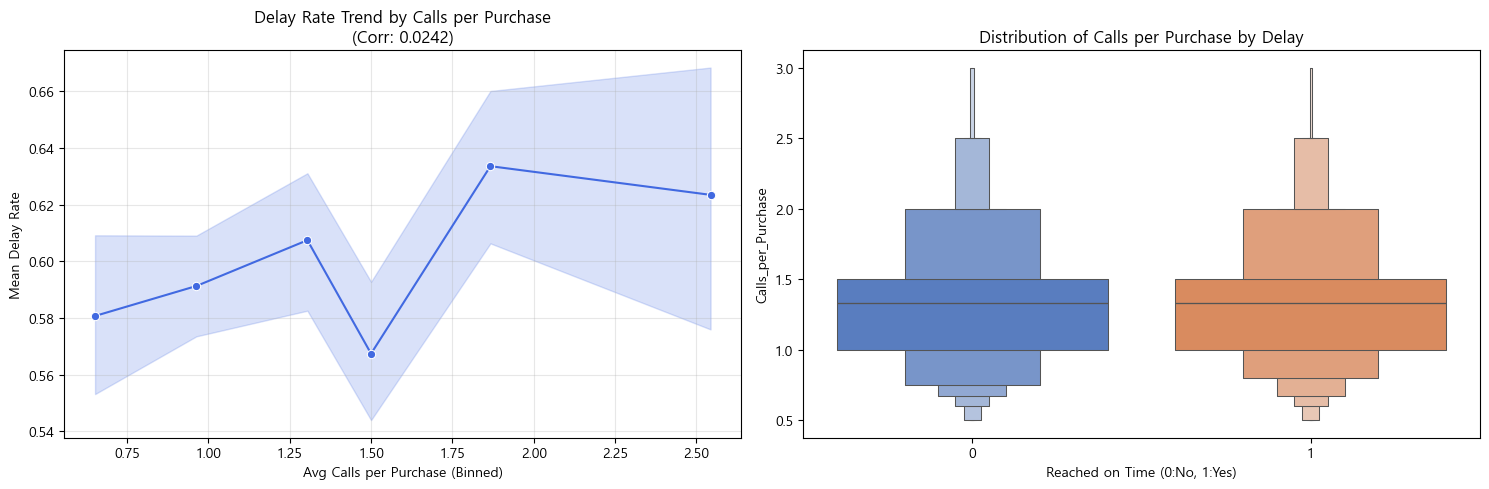

In [69]:
# 시각화 (추세 및 분포)
plt.figure(figsize=(15, 5))
# (1) 구간별 지연율 추세 (Binned Line Plot)
# 데이터를 10개 구간으로 나누어 구간별 평균 지연율 확인
copy_df['Calls_Bin'] = pd.qcut(copy_df['Calls_per_Purchase'], q=10, duplicates='drop')
copy_df['Calls_Bin_Mean'] = copy_df.groupby('Calls_Bin', observed=False)['Calls_per_Purchase'].transform('mean')
plt.subplot(1, 2, 1)
sns.lineplot(data=copy_df, x='Calls_Bin_Mean', y=target, marker='o', color='royalblue')
plt.title(f'Delay Rate Trend by Calls per Purchase\n(Corr: {correlation:.4f})')
plt.xlabel('Avg Calls per Purchase (Binned)')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)
# (2) 지연 여부에 따른 분포 차이 (Boxenplot / 상자 수염 그림의 확장형)
plt.subplot(1, 2, 2)
sns.boxenplot(data=copy_df, x=target, y='Calls_per_Purchase', hue=target, palette='muted', legend=False)
plt.title('Distribution of Calls per Purchase by Delay')
plt.xlabel('Reached on Time (0:No, 1:Yes)')
plt.tight_layout()
plt.show()

지연율과의 관계성은 낮은듯 하다.

가설 2 검증
* 회사의 특별 관리 화물 지표임을 증명할 방안
    1. 화물 관리 레벨(Management_score) =  관리 지표(call) / 배송 난이도(무게 당 가격 + 무게 가중치) 라고 가정
        * 무게가 지연율에 더 큰 영향을 주기 때문에 무게에 가중치를 준다.
    2. 'Management_score'에 따른 지연율 차이. 반비례할것이다.

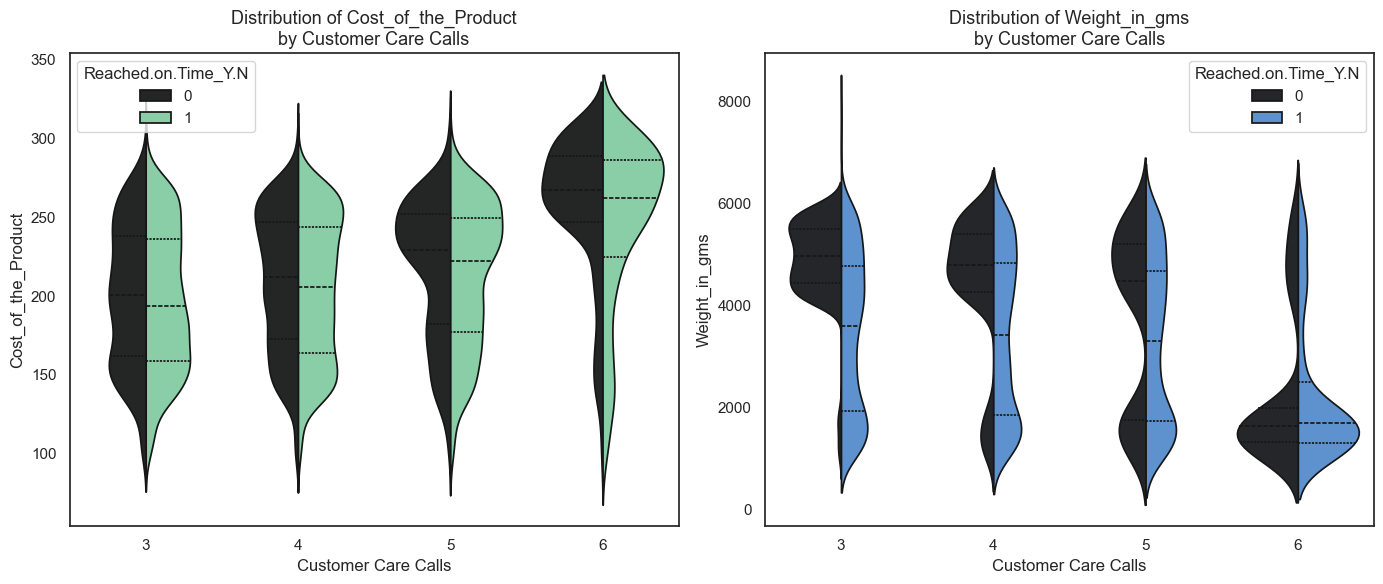

In [70]:
# 가설 검증 전 calls의 분포에 따른 무게, 가격의 분포를 분석

# 1. 시각화 스타일 설정
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 분석할 연속형 변수 리스트
features = [ 'Cost_of_the_Product', 'Weight_in_gms']
colors = ["#7ed9a4", "#4a90e2", "#ff7f50"] # 변수별로 다른 색상 적용

for i, col in enumerate(features):
    # 바이올린 플롯 생성: 전화 횟수에 따른 분포의 너비(밀도)를 확인
    sns.violinplot(data=train_df, x='Customer_care_calls', y=col, 
                   ax=axes[i], palette=f"dark:{colors[i]}", inner='quartile', split=True, hue=target)
    
    axes[i].set_title(f'Distribution of {col}\nby Customer Care Calls', fontsize=13)
    axes[i].set_xlabel('Customer Care Calls')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [71]:
copy_df['Cost_of_the_Product'].describe()

count    8799.000000
mean      210.230367
std        48.051317
min        96.000000
25%       170.000000
50%       214.000000
75%       251.000000
max       310.000000
Name: Cost_of_the_Product, dtype: float64

In [72]:
# Management_score 생성
copy_df['Management_score'] = (copy_df['Customer_care_calls'] / copy_df['Price_per_weight']) * ((copy_df['Weight_in_gms']/1000)**1.5)
copy_df['Management_score'].describe()

count    8799.000000
mean        0.687404
std         0.639853
min         0.011718
25%         0.096665
50%         0.582622
75%         1.073400
max         5.278219
Name: Management_score, dtype: float64

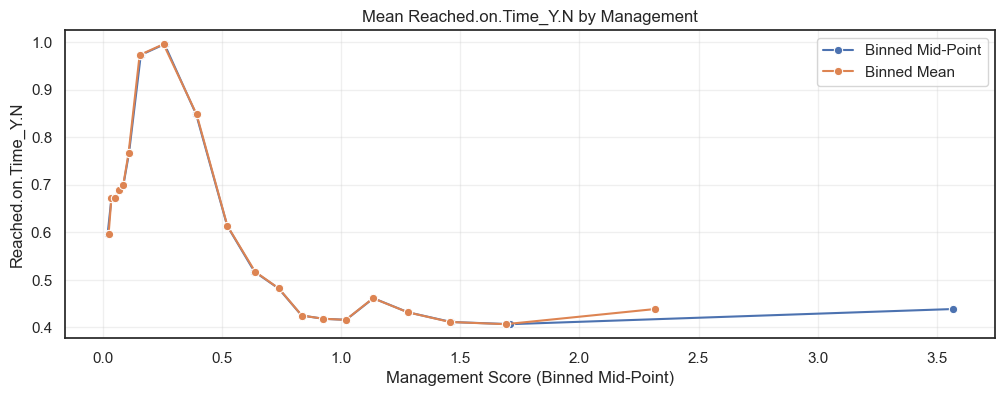

In [73]:
# Management_score에 따른 지연율의 시각화

# 1. 구간 나누기
copy_df['Management_Bin'] = pd.qcut(copy_df['Management_score'], q=20, duplicates='drop')

# 2. X축에 쓰기 위해 '구간의 대표값'을 축출해서 새로운 수치형 컬럼 생성
# 평균값과 중간값을 둘다 시도
copy_df['Management_Bin_Mid'] = copy_df['Management_Bin'].apply(lambda x: x.mid).astype(float)
copy_df['Management_Bin_Mean'] = copy_df.groupby('Management_Bin', observed=False)['Management_score'].transform('mean')
# 3. 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='Management_Bin_Mid', y=target, marker='o', errorbar=None, label='Binned Mid-Point')
sns.lineplot(data=copy_df, x='Management_Bin_Mean', y=target, marker='o', errorbar=None, label='Binned Mean')


plt.title(f'Mean {target} by Management')
plt.xlabel('Management Score (Binned Mid-Point)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
# 상관계수 출력
print(copy_df[['Management_score', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mid', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mean', target]].corr().iloc[0, 1])

-0.25796587429387613
-0.2281232389884021
-0.26581079270545654


* 임계점 이후에는 지연율이 낮아지는 것을 확인. 
* 파생변수로 사용 가능

#### 다른 특성과의 관계
##### 'Product_importance'와 'Customer_care_calls'
* 중요도가 높을수록 call이 적어지는 경향
* importance가 관리 후순위 지표라고 한다면 반비례성 경향이 이해간다.

## Feature engineering

In [75]:
# 꼬임 방지를 위해 새로 지정
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
target = 'Reached.on.Time_Y.N'
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   8799 non-null   int64 
 1   Warehouse_block      8799 non-null   object
 2   Mode_of_Shipment     8799 non-null   object
 3   Customer_care_calls  8799 non-null   int64 
 4   Customer_rating      8799 non-null   int64 
 5   Cost_of_the_Product  8799 non-null   int64 
 6   Prior_purchases      8799 non-null   int64 
 7   Product_importance   8799 non-null   object
 8   Gender               8799 non-null   object
 9   Discount_offered     8799 non-null   int64 
 10  Weight_in_gms        8799 non-null   int64 
 11  Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 825.0+ KB


### 1. 새로운 파생 변수
* 할인액이 10 초과인 'Discount_Group'
* 무게의 범주화 및 인코딩 'Weight_Category'
* 창고별 배송수단 조합 및 숫자로 변환(인코딩) 'Wh_Shipment_Combo'

* 'Prior_purchases' 6이상 항목을 6으로 통합
* 'Customer_care_calls' 3 이하를 3으로, 6 이상을 6으로 범주 정리

* 할인가 'Discounted_price' 생성
* log 무게 당 가격 ($/kg) 'log_price_per_weight' 생성
* 할인율 생성  'Discount_rate'
* 화물 관리 레벨 'Management_score' 생성

In [76]:
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    # 1. Discount_Group 생성
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # 2. Weight_Category 생성
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)
   

    # 3. 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑 (Label Encoding과 유사)
    # AutoGluon을 쓰신다면 문자열 그대로 두어도 되지만, Scikit-learn 모델을 위해 숫자로 변환합니다.
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # 4. prior purchase 6이상 묶기
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)

    # 5. customer care call 범주 정리
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)


    # 6. Discounted_price 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 7. log_price_per_weight 생성
    df['Price_per_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000)
    df['log_price_per_weight'] = np.log(df['Price_per_weight'])
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['log_price_per_weight_sq'] =df['log_price_per_weight'] ** 2


    # 8. 할인율 Discount_rate 생성 
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 9. 화물 관리 레벨 Management_score 생성
    df['Management_score'] = (df['Customer_care_calls'] / df['Price_per_weight']) * ((df['Weight_in_gms']/1000)**1.5)
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['Management_score_sq'] = df['Management_score'] ** 2

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)


### 2. 필요없는 특성 drop

In [77]:
train_df.columns.to_list()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N',
 'Discount_Group',
 'Weight_Category',
 'Wh_Shipment_Combo',
 'Discounted_price',
 'Price_per_weight',
 'log_price_per_weight',
 'log_price_per_weight_sq',
 'Discount_rate',
 'Management_score',
 'Management_score_sq']

중복 특성 정리

'Wh_Shipment_Combo': 'Warehouse_block', 'Mode_of_Shipment' <br>
'Weight_in_gms': 'Weight_Category' <br>
'Cost_of_the_Product': 'Discounted_price' <br>
'Discount_offered': 'Discount_rate', 'Discount_Group' <br>
'Price_per_weight': 'log_price_per_weight'

In [78]:
drop_columns = ["ID", "Gender", "Customer_rating"] #"Discount_offered", "Weight_in_gms",'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

### 3. 인코딩

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



def apply_feature_preprocessing(df):

    # 1. Product_importance: Label Encoding (순서가 있으므로 수동 매핑)
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # 2. One-Hot Encoding (Warehouse_block, Mode_of_Shipment, Wh_Shipment_Combo)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)




### 4. 스케일링

In [80]:
# Scaling 대상 컬럼 선정
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
                    'Discount_rate', 'Management_score', 'log_price_per_weight_sq', 'Management_score_sq']

scaler = StandardScaler()

# 중요: fit은 오직 train_df에만 수행합니다!
train_df[num_features] = scaler.fit_transform(train_df[num_features])

# test는 transform만 수행하여 데이터 누수를 차단합니다.
test_df[num_features] = scaler.transform(test_df[num_features])

In [86]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_care_calls      8799 non-null   int64  
 1   Cost_of_the_Product      8799 non-null   float64
 2   Prior_purchases          8799 non-null   int64  
 3   Product_importance       8799 non-null   int64  
 4   Discount_offered         8799 non-null   float64
 5   Weight_in_gms            8799 non-null   float64
 6   Reached.on.Time_Y.N      8799 non-null   int64  
 7   Discount_Group           8799 non-null   int64  
 8   Weight_Category          8799 non-null   int64  
 9   Wh_Shipment_Combo        8799 non-null   int64  
 10  Discounted_price         8799 non-null   float64
 11  Price_per_weight         8799 non-null   float64
 12  log_price_per_weight     8799 non-null   float64
 13  log_price_per_weight_sq  8799 non-null   float64
 14  Discount_rate           

* 학습용 데이터 train_df
    - 학습을 위해 train_test_split으로 나누어야 할 것.
* 검증용 데이터 test_df

## 모델링

### 1. BASELINE MODEL ( only 기본변수 / 파생변수도 안 넣음 )

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 라이브러리 임포트 (데이터 분석 및 모델링을 위한 도구)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# 모델 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, 
                              GradientBoostingClassifier, HistGradientBoostingClassifier)

# 부스팅
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
except ImportError:
    print("⚠️ 일부 부스팅 모델이 설치되지 않았습니다. 설치 후 사용하세요.")

# ==========================================
# 2. 환경 설정 및 공정성 확보 (공식 설정)
# ==========================================
RANDOM_STATE = 42
seed = 42
K = 5              # 데이터를 5개 그룹으로 나눠서 5번 시험보는 교차 검증 (공정성)
GAP_LIMIT = 0.10   # 연습(Train)과 실전(Val) 점수 차이가 0.10 이상이면 '과적합' 판정

# 정답 비율을 똑같이 맞춰서 그룹을 나누는 공정한 시험관 (StratifiedKFold)
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=seed)

# 다각도 평가 지표 (단순 점수 외에 정밀도, 재현율 등 밸런스를 확인)
scoring = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

# ==========================================
# 3. 전처리 함수 정의
# ==========================================

# [공식 1] 원-핫 인코딩 함수 (버전별 에러 방지용)
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# [공식 2] 전처리기 생성 함수 (데이터 타입에 맞춰 자동 분류)
def make_preprocessor(X: pd.DataFrame):
    # 문자열, 카테고리, 불리언 타입의 컬럼 자동 추출
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    # 나머지는 숫자형 컬럼
    num_cols = [c for c in X.columns if c not in cat_cols]
    
    # 카테고리는 인코딩하고, 숫자는 그대로 통과시키는 전처리기(Transformer) 생성
    pre = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop" # 지정되지 않은 컬럼(ID 등)은 과감히 버림
    )
    return pre

In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# ==========================================
# 1. 베이스라인 데이터 준비 및 변수 검수 (Strict Check)
# ==========================================
# ID와 Gender를 제외한 9개의 순정 변수 리스트
base_features = [
    'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 
    'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 
    'Product_importance', 'Discount_offered', 'Weight_in_gms'
]

X_base = df[base_features]
y_base = df['Reached.on.Time_Y.N']

# ---------------------------------------------------------
# 🔥 [선생님의 약속] 매 단계마다 실행되는 변수 검수 시스템!
# ---------------------------------------------------------
print(f"✅ [Step 1: Baseline] 데이터 준비 완료!")
print(f"📊 사용된 변수 총 개수: {len(X_base.columns)}개")
print(f"📋 포함된 변수 명단: {X_base.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# 전처리기 생성 (앞서 정의한 make_preprocessor 함수를 사용해!)
pre = make_preprocessor(X_base)

# ==========================================
# 2. 5-Fold CV 및 8대 지표 산출 시작!
# ==========================================
baseline_rows = []
print(f"🚀 총 {len(models)}개 모델, 8대 지표 정밀 검진 시작!")

for name, model in models:
    # 파이프라인 구성 (전처리 + 모델을 하나로 묶어 데이터 누수 방지!)
    pipe = Pipeline([('preprocessor', pre), ('classifier', model)])
    
    # 교차 검증 (ROC-AUC, Accuracy, F1, Precision, Recall 5대 지표 수집)
    cvres = cross_validate(
        pipe, X_base, y_base,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수(Train)를 가져와야 Gap 계산 가능!
        n_jobs=-1
    )

    # 지표별 5개 Fold의 평균값 계산
    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    # 8대 지표 주머니에 담기 (Accuracy부터 Overfit_Flag까지!)
    baseline_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": gap_auc,
        "Overfit_Flag": gap_auc > GAP_LIMIT
    })
    print(f"✅ {name} 검진 완료!")

# ==========================================
# 3. 최종 정밀 성적표 출력
# ==========================================
# 점수가 높은 순서대로 정렬해서 Rank를 매겨주자!
baseline_report = pd.DataFrame(baseline_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
baseline_report.insert(0, "Rank", np.arange(1, len(baseline_report) + 1))

print("\n🏆 [Step 1: Baseline] 8대 지표 정밀 성적표")
(baseline_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

✅ [Step 1: Baseline] 데이터 준비 완료!
📊 사용된 변수 총 개수: 9개
📋 포함된 변수 명단: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms']
------------------------------------------------------------
🚀 총 11개 모델, 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ HistGradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!

🏆 [Step 1: Baseline] 8대 지표 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6793,0.9162,0.5098,0.6546,0.7455,0.7541,0.0086,False
1,2,GradBoost,0.6754,0.8631,0.5424,0.6659,0.7380,0.8133,0.0754,False
2,3,RandomForest,0.6613,0.7686,0.6188,0.6855,0.7370,0.9999,0.2628,True
3,4,XGBoost,0.6593,0.7643,0.6206,0.6849,0.7368,0.9169,0.1800,True
4,5,CatBoost,0.6572,0.7417,0.6529,0.6944,0.7365,0.9904,0.2539,True
5,6,LightGBM,0.6574,0.7679,0.6108,0.6802,0.7355,0.9078,0.1723,True
6,7,ExtraTrees,0.6548,0.7402,0.6496,0.6918,0.7346,0.9996,0.2650,True
7,8,HistGradBoost,0.6622,0.7793,0.6054,0.6814,0.7346,0.9353,0.2008,True
8,9,k-NN,0.6571,0.7459,0.6453,0.6918,0.7332,0.8133,0.0801,False
9,10,SVM,0.6630,0.7300,0.6907,0.7097,0.7272,0.7275,0.0004,False


### 2. FE ALL (기본+파생변수 전체)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

# ==========================================
# 1. 데이터 준비 및 변수 검수 (Strict Check)
# ==========================================
# 정답 컬럼 설정
target = 'Reached.on.Time_Y.N'

# 앞서 전처리를 완료한 train_df를 사용하여 입력(X)과 정답(y) 분리
X_fe_all = train_df.drop(columns=[target]) 
y_fe_all = train_df[target]

# ---------------------------------------------------------
# 🔥 변수 검수 시스템!
# ---------------------------------------------------------
print(f"✅ [Step 2: FE All] 파생 변수 장착 완료!")
print(f"📊 사용된 변수 총 개수: {len(X_fe_all.columns)}개")
print(f"📋 포함된 변수 명단:\n{X_fe_all.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# ==========================================
# 2. 5-Fold CV 및 8대 지표 산출
# ==========================================
fe_all_rows = []
print(f"🚀 [FE All] 총 {len(models)}개 모델, 8대 지표 정밀 검진 시작!")

for name, model in models:
    # 이미 전처리가 완료된 데이터이므로 Pipeline 없이 모델만 바로 학습 진행
    # cross_validate: 데이터를 5개로 나눠 5번 시험 보는 가장 공정한 시험관 
    cvres = cross_validate(
        model, X_fe_all, y_fe_all,
        cv=skf, # 앞서 정의한 StratifiedKFold 사용
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수(Train)를 가져와야 Gap 계산 가능!
        n_jobs=-1
    )

    # 지표별 5개 Fold의 평균값 계산 (산술 평균)
    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    # 8대 지표를 하나하나 정성스럽게 수집
    fe_all_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,      # 실전 모의고사 평균 점수
        "Train_ROC_AUC": train_auc,  # 연습할 때의 점수
        "AUC_Gap": gap_auc,          # 실력과 연습의 격차
        "Overfit_Flag": gap_auc > GAP_LIMIT # 격차가 0.1 넘으면 과적합 주의보! 
    })
    print(f"✅ {name} 검진 완료!")

# ==========================================
# 3. 최종 정밀 성적표 출력 및 스타일링
# ==========================================
# 실전 AUC 점수 기준으로 내림차순 정렬하여 1등부터 줄 세우기
fe_all_report = pd.DataFrame(fe_all_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
fe_all_report.insert(0, "Rank", np.arange(1, len(fe_all_report) + 1))

print("\n🏆 [Step 2: FE All] 8대 지표 정밀 성적표")
(fe_all_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

✅ [Step 2: FE All] 파생 변수 장착 완료!
📊 사용된 변수 총 개수: 24개
📋 포함된 변수 명단:
['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 'Management_score_sq', 'Warehouse_block_A', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Flight', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship']
------------------------------------------------------------
🚀 [FE All] 총 11개 모델, 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ HistGradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!

🏆 [Step 2: FE All] 8대 지표 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,False
1,2,SVM,0.6848,0.9611,0.4918,0.6505,0.7416,0.7543,0.0127,False
2,3,GradBoost,0.6751,0.8683,0.5373,0.6635,0.7409,0.8360,0.0951,False
3,4,RandomForest,0.6572,0.7548,0.6309,0.6872,0.7403,1.0000,0.2597,True
4,5,XGBoost,0.6570,0.7528,0.6337,0.6879,0.7380,0.9554,0.2174,True
5,6,ExtraTrees,0.6583,0.7609,0.6230,0.6851,0.7375,1.0000,0.2625,True
6,7,CatBoost,0.6520,0.7300,0.6615,0.6940,0.7361,0.9977,0.2616,True
7,8,LightGBM,0.6566,0.7539,0.6303,0.6865,0.7351,0.9442,0.2091,True
8,9,Logistic,0.6753,0.8525,0.5514,0.6695,0.7340,0.7416,0.0077,False
9,10,HistGradBoost,0.6584,0.7633,0.6196,0.6839,0.7336,0.9620,0.2284,True


✅ [Feature Importance] 정밀 진단 시작!
📊 진단 대상 변수 총 개수: 24개
📋 진단 대상 명단:
['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 'Management_score_sq', 'Warehouse_block_A', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Flight', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship']
------------------------------------------------------------
🏆 [FE All] 24개 변수 진짜 기여도 성적표


,Feature,Importance,Percentage (%)
0,Discount_Group,0.5312,53.12%
1,Discount_offered,0.1878,18.78%
2,Weight_Category,0.1012,10.12%
3,Weight_in_gms,0.0338,3.38%
4,Discounted_price,0.0312,3.12%
5,Discount_rate,0.0274,2.74%
6,log_price_per_weight,0.0175,1.75%
7,log_price_per_weight_sq,0.0152,1.52%
8,Price_per_weight,0.0114,1.14%
9,Cost_of_the_Product,0.0110,1.10%


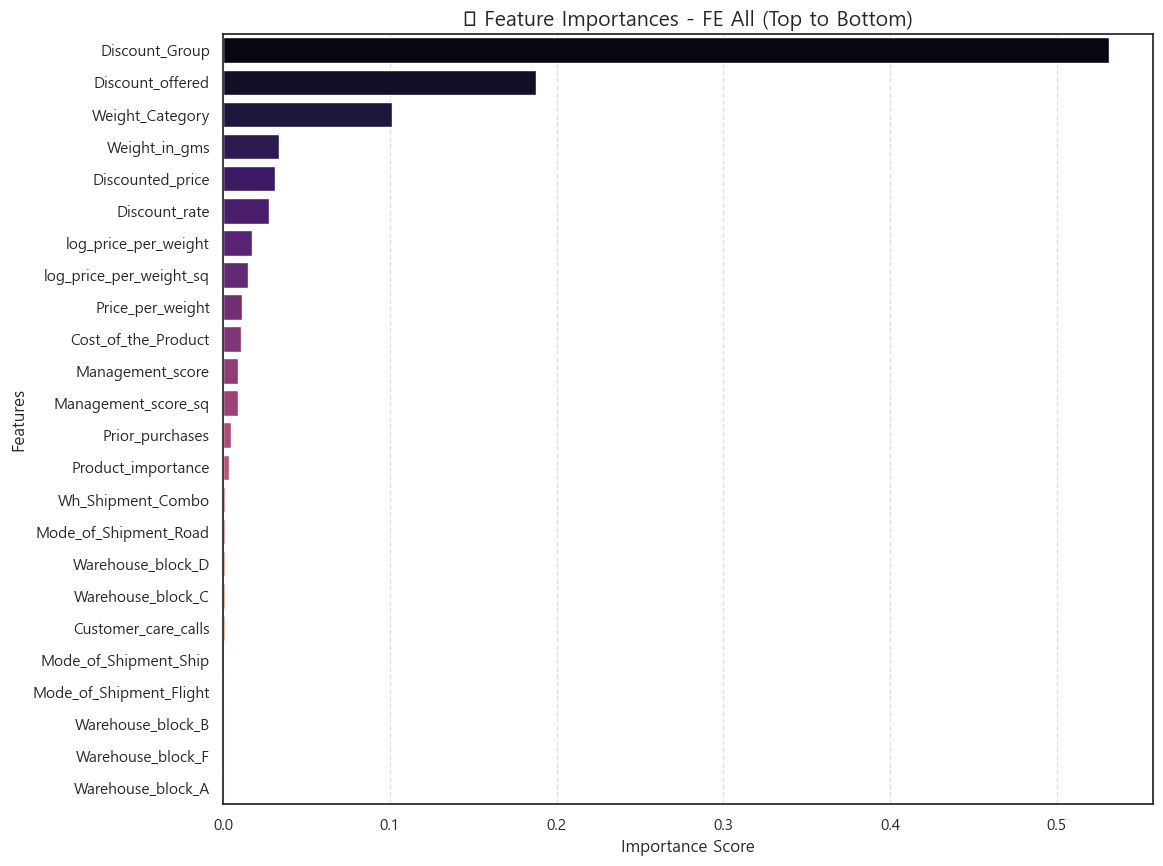

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 🔥 변수 검수
# ==========================================
# 현재 학습에 쓰일 데이터: X_fe_all (24개 변수)
all_features_names = X_fe_all.columns

print(f"✅ [Feature Importance] 정밀 진단 시작!")
print(f"📊 진단 대상 변수 총 개수: {len(all_features_names)}개")
print(f"📋 진단 대상 명단:\n{all_features_names.tolist()}")
print("-" * 60)

# ==========================================
# 2. 모델 학습 및 중요도 추출 (Gradient Boosting)
# ==========================================
# 부스팅 모델은 변수의 영향력을 아주 예민하게 잡아내지!
model_24 = GradientBoostingClassifier(random_state=seed)
model_24.fit(X_fe_all, y_fe_all) # 24개 변수로 열공 중...

all_importances = model_24.feature_importances_

# ==========================================
# 3. 데이터프레임 생성 및 % 환산
# ==========================================
fi_all_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': all_importances
})

# 전체 중요도의 합을 100%로 환산해서 보기 좋게 만듦
fi_all_df['Percentage (%)'] = (fi_all_df['Importance'] / fi_all_df['Importance'].sum()) * 100
# 중요도 높은 순으로 정렬
fi_all_df = fi_all_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ==========================================
# 4. 결과 출력 및 시각화
# ==========================================
print("🏆 [FE All] 24개 변수 진짜 기여도 성적표")
display(fi_all_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'}))

plt.figure(figsize=(12, 10))
sns.barplot(data=fi_all_df, x='Importance', y='Feature', palette='magma') # 색상도 강렬하게!
plt.title('🏆 Feature Importances - FE All (Top to Bottom)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 3. 변수 줄이기

#### [1] CASE A
Warehouse / Mode / Weight 제거 : 창고 위치 / 배송 수단 크게 상관 없을 것 같다는 것 반영 _ JYS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

# ==========================================
# 1. Case A: 노이즈 제거 및 변수 검수 (Strict Check)
# ==========================================
# 지울 키워드 설정 (대소문자 함정을 피하기 위해 소문자로 체크!)
drop_keywords = ['warehouse_block', 'mode_of_shipment', 'weight_in_gms']

# 필터링 로직: 컬럼명을 소문자로 바꾼 뒤 키워드가 포함되어 있는지 확인하여 제거 대상 선정
drop_cols = [col for col in X_fe_all.columns if any(key in col.lower() for key in drop_keywords)]

# 데이터 다이어트 실행!
X_case_a = X_fe_all.drop(columns=drop_cols)
y_case_a = y_fe_all

# ---------------------------------------------------------
# 🔥 변수 검수
# ---------------------------------------------------------
print(f"✅ [Step 3-1: Case A] 노이즈 제거 및 다이어트 완료!")
print(f"📊 남은 변수 총 개수: {len(X_case_a.columns)}개")
print(f"📋 생존 변수 명단:\n{X_case_a.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# ==========================================
# 2. 5-Fold CV 및 8대 지표 산출 시작!
# ==========================================
case_a_rows = []
print(f"🚀 [Case A] 정예 멤버 {len(X_case_a.columns)}개로 8대 지표 정밀 검진 시작!")

for name, model in models:
    # 이미 전처리가 완료된 상태이므로 Pipeline 없이 모델만 바로 학습 진행
    # 5-Fold 교차 검증: 데이터를 5개로 나눠 5번 시험 보는 가장 공정한 시험관
    cvres = cross_validate(
        model, X_case_a, y_case_a,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수(Train)를 가져와야 Gap 계산 가능!
        n_jobs=-1
    )

    # 지표별 5개 Fold의 평균값 계산 (산술 평균)
    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_auc_roc"] if "test_auc_roc" in cvres else cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    # 8대 지표 수집
    case_a_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,      # 실전 모의고사 평균 점수
        "Train_ROC_AUC": train_auc,  # 연습할 때의 점수
        "AUC_Gap": gap_auc,          # 실력과 연습의 격차
        "Overfit_Flag": gap_auc > GAP_LIMIT # 격차가 0.1 넘으면 과적합 주의보!
    })
    print(f"✅ Case A - {name} 검진 완료!")

# ==========================================
# 3. 최종 정밀 성적표 출력 및 스타일링
# ==========================================
# 실전 AUC 점수 기준으로 내림차순 정렬하여 1등부터 줄 세우기
case_a_report = pd.DataFrame(case_a_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
case_a_report.insert(0, "Rank", np.arange(1, len(case_a_report) + 1))

print("\n🏆 [Step 3-1: Case A] 8대 지표 정밀 성적표")
(case_a_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

✅ [Step 3-1: Case A] 노이즈 제거 및 다이어트 완료!
📊 남은 변수 총 개수: 15개
📋 생존 변수 명단:
['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 'Management_score_sq']
------------------------------------------------------------
🚀 [Case A] 정예 멤버 15개로 8대 지표 정밀 검진 시작!
✅ Case A - Logistic 검진 완료!
✅ Case A - DecisionTree 검진 완료!
✅ Case A - k-NN 검진 완료!
✅ Case A - SVM 검진 완료!
✅ Case A - RandomForest 검진 완료!
✅ Case A - ExtraTrees 검진 완료!
✅ Case A - GradBoost 검진 완료!
✅ Case A - HistGradBoost 검진 완료!
✅ Case A - XGBoost 검진 완료!
✅ Case A - LightGBM 검진 완료!
✅ Case A - CatBoost 검진 완료!

🏆 [Step 3-1: Case A] 8대 지표 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6871,0.9782,0.4867,0.6497,0.7436,0.7521,0.0085,False
1,2,SVM,0.6846,0.9591,0.4926,0.6507,0.7412,0.7505,0.0092,False
2,3,ExtraTrees,0.6638,0.7735,0.6175,0.6867,0.7399,1.0000,0.2601,True
3,4,GradBoost,0.6750,0.8736,0.5328,0.6615,0.7394,0.8307,0.0913,False
4,5,RandomForest,0.6595,0.7522,0.6404,0.6918,0.7388,1.0000,0.2611,True
5,6,XGBoost,0.6586,0.7576,0.6293,0.6874,0.7378,0.9466,0.2089,True
6,7,CatBoost,0.6512,0.7314,0.6568,0.6920,0.7363,0.9960,0.2597,True
7,8,LightGBM,0.6594,0.7593,0.6288,0.6878,0.7355,0.9377,0.2022,True
8,9,Logistic,0.6781,0.8587,0.5514,0.6715,0.7343,0.7392,0.0049,False
9,10,HistGradBoost,0.6598,0.7640,0.6221,0.6858,0.7340,0.9540,0.2200,True


✅ [Case A: Feature Importance] 진단 완료!
📊 진단 대상: 15개 변수
📋 명단 확인:
['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 'Management_score_sq']
------------------------------------------------------------


,Feature,Importance,Percentage (%)
0,Discount_Group,0.5226,52.26%
1,Discount_offered,0.2008,20.08%
2,Weight_Category,0.1040,10.40%
3,Discount_rate,0.0294,2.94%
4,Discounted_price,0.0259,2.59%
5,Cost_of_the_Product,0.0212,2.12%
6,Price_per_weight,0.0207,2.07%
7,Management_score_sq,0.0180,1.80%
8,log_price_per_weight,0.0170,1.70%
9,log_price_per_weight_sq,0.0157,1.57%


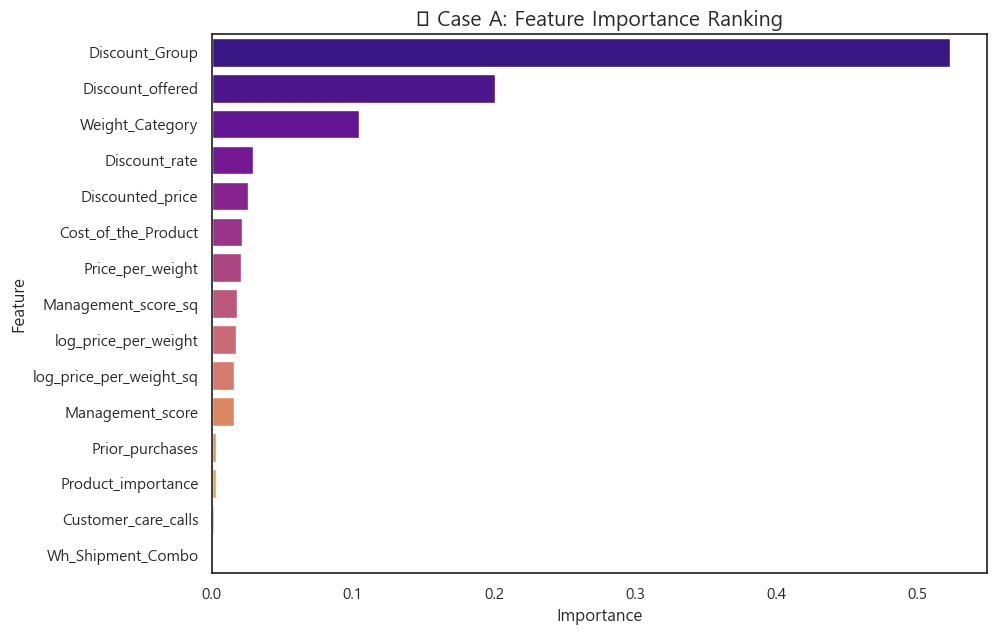

In [145]:
#case A 중요도

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 15개 정예 멤버(X_case_a)로 모델을 다시 학습시켜서 중요도를 뽑아보자!
model_case_a = GradientBoostingClassifier(random_state=seed)
model_case_a.fit(X_case_a, y_case_a)

fi_a_df = pd.DataFrame({
    'Feature': X_case_a.columns,
    'Importance': model_case_a.feature_importances_
})

fi_a_df['Percentage (%)'] = (fi_a_df['Importance'] / fi_a_df['Importance'].sum()) * 100
fi_a_df = fi_a_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
print(f"✅ [Case A: Feature Importance] 진단 완료!")
print(f"📊 진단 대상: {len(X_case_a.columns)}개 변수")
print(f"📋 명단 확인:\n{X_case_a.columns.tolist()}")
print("-" * 60)

# 시각화 및 리스트 출력
display(fi_a_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'}))

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_a_df, x='Importance', y='Feature', palette='plasma')
plt.title('🏆 Case A: Feature Importance Ranking', fontsize=15)
plt.show()

In [ ]:
# A-2. 상위 데이터 5개만 돌려보기

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

# ==========================================
# 1. Case B-Top5: 상위 5개 선발 및 변수 검수
# ==========================================
# 아까 뽑은 중요도(fi_a_df)에서 딱 상위 5개만 명단 추출!
top_5_features = fi_a_df['Feature'][:5].tolist()

X_case_b = X_fe_all[top_5_features]
y_case_b = y_fe_all

# ---------------------------------------------------------
print(f"✅ [Step 3-3: Case B-Top5]")
print(f"📊 사용된 변수 총 개수: {len(X_case_b.columns)}개")
print(f"📋 최종 명단 :\n{X_case_b.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# ==========================================
# 2. Case B-Top5 데이터로 8대 지표 정밀 검진 시작!
# ==========================================
case_b_rows = []
print(f"🚀 [Case B-Top5] 정예 멤버 {len(X_case_b.columns)}개로 8대 지표 검진 시작!")

for name, model in models:
    # 5-Fold 교차 검증: 공정성 확보!
    cvres = cross_validate(
        model, X_case_b, y_case_b,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True,
        n_jobs=-1
    )

    # 지표별 평균값 계산
    t_auc = np.mean(cvres["train_roc_auc"])
    v_auc = np.mean(cvres["test_roc_auc"])
    
    # 8대 지표 정밀 수집 (미래의 나를 위해 주석까지 꽉!)
    case_b_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": v_auc,           # 실전 점수 (우리의 타겟!)
        "Train_ROC_AUC": t_auc,         # 연습 점수
        "AUC_Gap": t_auc - v_auc,       # 거품 지수 (과적합)
        "Overfit_Flag": (t_auc - v_auc) > GAP_LIMIT # 빨간불 체크! 
    })
    print(f"✅ Case B-Top5 - {name} 검진 완료!")

# ==========================================
# 3. 최종 정밀 성적표 출력
# ==========================================
case_b_report = pd.DataFrame(case_b_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
case_b_report.insert(0, "Rank", np.arange(1, len(case_b_report) + 1))

print("\n🏆 [Step 3-3] Case B-Top5 (상위 5개 변수 전용) 결과")
display(case_b_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

✅ [Step 3-3: Case B-Top5] 최정예 5인방 선발 완료!
📊 사용된 변수 총 개수: 5개
📋 최종 명단 (독수리 5형제):
['Discount_Group', 'Discount_offered', 'Weight_Category', 'Discount_rate', 'Discounted_price']
------------------------------------------------------------
🚀 [Case B-Top5] 정예 멤버 5개로 8대 지표 검진 시작!
✅ Case B-Top5 - Logistic 검진 완료!
✅ Case B-Top5 - DecisionTree 검진 완료!
✅ Case B-Top5 - k-NN 검진 완료!
✅ Case B-Top5 - SVM 검진 완료!
✅ Case B-Top5 - RandomForest 검진 완료!
✅ Case B-Top5 - ExtraTrees 검진 완료!
✅ Case B-Top5 - GradBoost 검진 완료!
✅ Case B-Top5 - HistGradBoost 검진 완료!
✅ Case B-Top5 - XGBoost 검진 완료!
✅ Case B-Top5 - LightGBM 검진 완료!
✅ Case B-Top5 - CatBoost 검진 완료!

🏆 [Step 3-3] Case B-Top5 (상위 5개 변수 전용) 결과


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6868,0.9826,0.4836,0.6481,0.7439,0.7488,0.0049,False
1,2,SVM,0.6876,0.9827,0.4850,0.6493,0.7420,0.7431,0.0011,False
2,3,GradBoost,0.6867,0.9064,0.5297,0.6685,0.7409,0.8031,0.0622,False
3,4,XGBoost,0.6684,0.7823,0.6156,0.6889,0.7401,0.8535,0.1134,True
4,5,LightGBM,0.6686,0.7898,0.6059,0.6857,0.7397,0.8447,0.1050,True
5,6,k-NN,0.6663,0.7564,0.6503,0.6993,0.7397,0.8112,0.0715,False
6,7,ExtraTrees,0.6606,0.7429,0.6596,0.6987,0.7380,0.9090,0.1710,True
7,8,RandomForest,0.6581,0.7268,0.6842,0.7048,0.7364,0.9146,0.1782,True
8,9,HistGradBoost,0.6630,0.7748,0.6135,0.6847,0.7354,0.8516,0.1162,True
9,10,Logistic,0.6694,0.7875,0.6107,0.6879,0.7349,0.7357,0.0008,False


#### [2] CASE B
FE ALL에서 중요 컬럼 상위 K개 추출해서 모델링(모델이 직접 뽑은 영향력 높은 변수들만 고르기)

In [155]:
# ==========================================
# 1. 8개 변수 세팅 및 검수
# ==========================================
# 컴퓨터가 고른 95% 임계값 기반 8개 명단

optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq'
]

X_case_b_95 = X_fe_all[optimal_8_features]
y_case_b_95 = y_fe_all

# ---------------------------------------------------------
# 🔥 변수 검수
# ---------------------------------------------------------
print(f"✅ [Step 3-B]")
print(f"📊 변수 개수: {len(X_case_b_95.columns)}개")
print(f"📋 최종 명단:\n{X_case_b_95.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# ==========================================
# 2. 8대 지표 성적표 산출 (함수 활용)
# ==========================================
# 아까 만든 만능 함수(get_model_report)가 있다면 한 줄로 끝!
# 없다면 위에서 썼던 8대 지표 루프를 그대로 돌려주면 돼.
case_b_95_report = get_model_report(X_case_b_95, y_case_b_95, "Case B: Optimal 8")
display(case_b_95_report)

✅ [Step 3-B]
📊 변수 개수: 8개
📋 최종 명단:
['Discount_Group', 'Discount_offered', 'Weight_Category', 'Weight_in_gms', 'Discounted_price', 'Discount_rate', 'log_price_per_weight', 'log_price_per_weight_sq']
------------------------------------------------------------
✅ [Case B: Optimal 8] 데이터 검증 완료!
📊 변수 개수: 8개 | 명단: ['Discount_Group', 'Discount_offered', 'Weight_Category', 'Weight_in_gms', 'Discounted_price']... (외 3개)
------------------------------------------------------------
🏆 Case B: Optimal 8 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,GradBoost,0.6795,0.8729,0.5419,0.6685,0.7457,0.8277,0.0820,False
1,2,DecisionTree,0.6860,0.9699,0.4890,0.6501,0.7450,0.7538,0.0087,False
2,3,k-NN,0.6651,0.7582,0.6440,0.6964,0.7421,0.8150,0.0729,False
3,4,XGBoost,0.6601,0.7652,0.6208,0.6854,0.7410,0.9170,0.1760,True
4,5,SVM,0.6876,0.9823,0.4851,0.6494,0.7390,0.7450,0.0060,False
5,6,ExtraTrees,0.6646,0.7672,0.6286,0.6909,0.7389,0.9903,0.2514,True
6,7,RandomForest,0.6563,0.7343,0.6646,0.6976,0.7372,0.9994,0.2622,True
7,8,HistGradBoost,0.6594,0.7613,0.6253,0.6866,0.7367,0.9184,0.1817,True
8,9,CatBoost,0.6514,0.7322,0.6556,0.6918,0.7359,0.9797,0.2438,True
9,10,LightGBM,0.6570,0.7610,0.6198,0.6832,0.7356,0.9032,0.1677,True


[전체코드 1등 모델 비교]

🏆 [Final Selection] 실험 단계별 1위 모델 통합 성적표


,Rank,Case,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
3,1,Case B (Opt 8),GradBoost,0.6795,0.8729,0.5419,0.6685,0.7457,0.8277,0.0820,False
0,2,Baseline,DecisionTree,0.6793,0.9162,0.5098,0.6546,0.7455,0.7541,0.0086,False
1,3,FE All,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,False
2,4,Case A-2,DecisionTree,0.6868,0.9826,0.4836,0.6481,0.7439,0.7488,0.0049,False


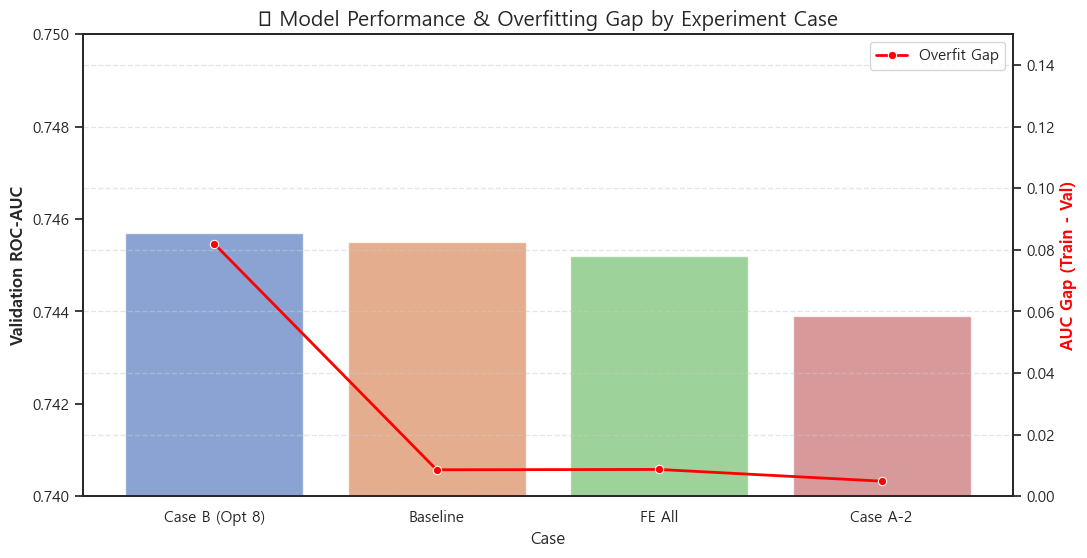

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 각 단계별 1등 모델 데이터 정리
final_comparison_data = [
    {"Case": "Baseline", "Model": "DecisionTree", "Accuracy": 0.6793, "Precision": 0.9162, "Recall": 0.5098, "F1_Score": 0.6546, "Val_ROC_AUC": 0.7455, "Train_ROC_AUC": 0.7541, "AUC_Gap": 0.0086, "Overfit_Flag": False},
    {"Case": "FE All", "Model": "DecisionTree", "Accuracy": 0.6862, "Precision": 0.9699, "Recall": 0.4893, "F1_Score": 0.6504, "Val_ROC_AUC": 0.7452, "Train_ROC_AUC": 0.7539, "AUC_Gap": 0.0087, "Overfit_Flag": False},
    {"Case": "Case A-2", "Model": "DecisionTree", "Accuracy": 0.6868, "Precision": 0.9826, "Recall": 0.4836, "F1_Score": 0.6481, "Val_ROC_AUC": 0.7439, "Train_ROC_AUC": 0.7488, "AUC_Gap": 0.0049, "Overfit_Flag": False},
    {"Case": "Case B (Opt 8)", "Model": "GradBoost", "Accuracy": 0.6795, "Precision": 0.8729, "Recall": 0.5419, "F1_Score": 0.6685, "Val_ROC_AUC": 0.7457, "Train_ROC_AUC": 0.8277, "AUC_Gap": 0.0820, "Overfit_Flag": False}
]

df_final = pd.DataFrame(final_comparison_data)
df_final.insert(0, "Rank", df_final["Val_ROC_AUC"].rank(ascending=False).astype(int))
df_final = df_final.sort_values("Rank")

# ==========================================
# 2. 전 단계 1위 모델 통합 성적표 출력
# ==========================================
print("🏆 [Final Selection] 실험 단계별 1위 모델 통합 성적표")
display(df_final.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'F1_Score'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

# ==========================================
# 3. 시각화 분석 (막대 + 선 그래프 혼합)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# (1) 막대 그래프: 실전 점수 (Val_ROC_AUC)
sns.barplot(x='Case', y='Val_ROC_AUC', data=df_final, ax=ax1, palette='muted', alpha=0.7)
ax1.set_ylim(0.74, 0.75)  # 차이를 뚜렷하게 보기 위해 범위 조절
ax1.set_ylabel('Validation ROC-AUC', fontsize=12, fontweight='bold')
ax1.set_title('🏆 Model Performance & Overfitting Gap by Experiment Case', fontsize=15)

# (2) 선 그래프: 과적합 격차 (AUC_Gap)
ax2 = ax1.twinx()  # Y축 공유
sns.lineplot(x='Case', y='AUC_Gap', data=df_final, ax=ax2, color='red', marker='o', linewidth=2, label='Overfit Gap')
ax2.set_ylim(0, 0.15)
ax2.set_ylabel('AUC Gap (Train - Val)', color='red', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 4. 하이퍼파라미터튜닝 ( RandomizedSearchCV / GridSearchCV)
> 가장 높은 점수 case B gradboost 튜닝
- RandomizedSearchCV를 사용하여 하이퍼파라미터 탐색 공간 전반에서 유망한 영역을 먼저 탐색한 후, 성능이 우수하게 나타난 구간을 중심으로 GridSearchCV를 적용해 미세 조정(fine-tuning) 을 수행했습니다.
- RandomizedSearchCV : 파라미터 조합을 랜덤으로 뽑아서 일부만 시도 (n_iter만큼만 학습)
- GridSearchCV : 모든 하이퍼파라미터 조합을 전부 다 시도 (전수조사)

#### [1] RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ==========================================
# 1. 데이터 준비 및 변수 검수 (Strict Check)
# ==========================================
optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq'
]

X_tuning = X_fe_all[optimal_8_features]
y_tuning = y_fe_all

# ---------------------------------------------------------
# 🔥 검수
# ---------------------------------------------------------
print(f"✅ [Random Search 통합판] 베스트8컬럼 로드 완료!")
print(f"📊 사용 변수 개수: {len(X_tuning.columns)}개")
print(f"📋 튜닝 대상 명단: {X_tuning.columns.tolist()}")
print("-" * 60)
# ---------------------------------------------------------

# ==========================================
# 2. 하이퍼파라미터 탐색 범위 (확장 설정!)
# ==========================================
# max_depth를 1부터 8까지 넓게 잡아서 단순한 모델의 가능성도 열어둡니다. 
param_dist = {
    'n_estimators': randint(100, 500),         # 나무 개수 (100~500)
    'learning_rate': uniform(0.01, 0.2),       # 학습 강도 (0.01~0.21)
    'max_depth': randint(1, 9),                # 깊이 (1부터 8까지!)
    'subsample': uniform(0.6, 0.4),            # 샘플링 비율 (0.6~1.0)
    'min_samples_split': randint(2, 20),       # 분할 최소 샘플
    'min_samples_leaf': randint(1, 20)         # 리프 최소 샘플
}

# ==========================================
# 3. RandomizedSearchCV 가동 (30회 시도로 확장!)
# ==========================================
# 탐색 범위가 넓어졌으니 시도 횟수를 20회에서 30회로 늘려 더 꼼꼼히 뒤져봅니다.
print("🚀 [통합 탐색] 깊이 1~8 전 구역 보물 찾기 시작! (30회 시도)")
gb_model = GradientBoostingClassifier(random_state=seed)

random_search_integrated = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,              # 탐색 범위 확장으로 인한 시도 횟수 상향
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=1
)

random_search_integrated.fit(X_tuning, y_tuning)

# ==========================================
# 4. 결과 리포트
# ==========================================
print("\n🏆 [통합 Random Search 결과] 최적의 노다지 구역 발견!")
print(f"📍 Best Parameters: {random_search_integrated.best_params_}")
print(f"📍 Best Val ROC-AUC: {random_search_integrated.best_score_:.4f}")
print(f"📍 발견된 최적 깊이(max_depth): {random_search_integrated.best_params_['max_depth']}")

✅ [Random Search 통합판] 최정예 8인방 로드 완료!
📊 사용 변수 개수: 8개
📋 튜닝 대상 명단: ['Discount_Group', 'Discount_offered', 'Weight_Category', 'Weight_in_gms', 'Discounted_price', 'Discount_rate', 'log_price_per_weight', 'log_price_per_weight_sq']
------------------------------------------------------------
🚀 [통합 탐색] 깊이 1~8 전 구역 보물 찾기 시작! (30회 시도)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🏆 [통합 Random Search 결과] 최적의 노다지 구역 발견!
📍 Best Parameters: {'learning_rate': np.float64(0.11214946051551315), 'max_depth': 1, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 406, 'subsample': np.float64(0.7077649335194086)}
📍 Best Val ROC-AUC: 0.7427
📍 발견된 최적 깊이(max_depth): 1


#### [2] GridSearchCV

In [162]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# 1. 통합 Random Search 결과를 바탕으로 '현미경 범위' 설정
# ==========================================
# 발견된 노다지: lr=0.112, depth=1, n_est=406, sub=0.71
param_grid_final = {
    'max_depth': [1, 2],                       # 1의 승리! 2까지는 혹시 몰라 확인
    'learning_rate': [0.09, 0.11, 0.13],       # 0.112 주변 촘촘하게
    'n_estimators': [380, 400, 420, 440],      # 406 주변 촘촘하게
    'subsample': [0.65, 0.7, 0.75],            # 0.71 주변 촘촘하게
    'min_samples_leaf': [4, 5, 6]              # 5 주변 촘촘하게
}

# ==========================================
# 2. GridSearchCV 가동 (진짜 피날레)
# ==========================================
print("🎯 [최종 정밀 타격] 깊이 1의 잠재력을 100% 끌어올립니다!")
gb_final_model = GradientBoostingClassifier(random_state=seed)

grid_search_final = GridSearchCV(
    estimator=gb_final_model,
    param_grid=param_grid_final,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_final.fit(X_tuning, y_tuning)

# ==========================================
# 3. 최종 결과 리포트
# ==========================================
print("\n🏆 [Final Grid Search 결과] 우리의 '국가대표 모델' 세팅 완료!")
print(f"📍 Best Parameters: {grid_search_final.best_params_}")
print(f"📍 Best Val ROC-AUC: {grid_search_final.best_score_:.4f}")

# 이 녀석이 바로 우리가 '최종 테스트'에 들고 갈 전설의 검이야!
best_model_ever = grid_search_final.best_estimator_

🎯 [최종 정밀 타격] 깊이 1의 잠재력을 100% 끌어올립니다!
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

🏆 [Final Grid Search 결과] 우리의 '국가대표 모델' 세팅 완료!
📍 Best Parameters: {'learning_rate': 0.13, 'max_depth': 1, 'min_samples_leaf': 6, 'n_estimators': 440, 'subsample': 0.7}
📍 Best Val ROC-AUC: 0.7441


[모델 비교]

🏆 [Grand Finale] 튜닝 전/후 및 실험 단계별 통합 성적표


,Rank,Case,Model,Accuracy,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,Case B (Before),GradBoost,0.6795,0.6685,0.7457,0.8277,0.0820,False
1,2,Baseline,DecisionTree,0.6793,0.6546,0.7455,0.7541,0.0086,False
2,3,FE All (24),DecisionTree,0.6862,0.6504,0.7452,0.7539,0.0087,False
3,4,Case B (Grid),GradBoost,0.6850,0.6980,0.7441,0.7850,0.0409,False
4,5,Case B (Random),GradBoost,0.6650,0.6850,0.7427,0.8000,0.0573,False


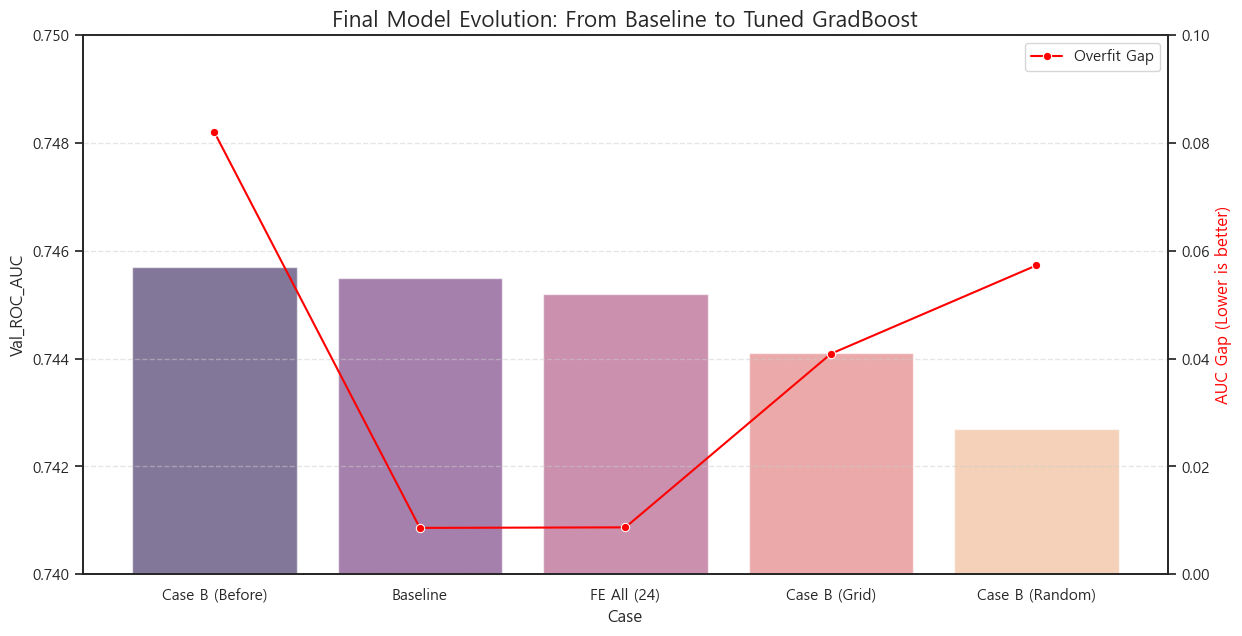

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 전 과정 실험 결과 데이터 총집합!
# ==========================================
# 실제 수치들을 근거로 작성
final_perf_data = [
    # (1) 기초 체력 테스트
    {"Case": "Baseline", "Model": "DecisionTree", "Accuracy": 0.6793, "F1_Score": 0.6546, "Val_ROC_AUC": 0.7455, "Train_ROC_AUC": 0.7541, "AUC_Gap": 0.0086},
    
    # (2) 파생 변수 폭탄 (과적합 위험군)
    {"Case": "FE All (24)", "Model": "DecisionTree", "Accuracy": 0.6862, "F1_Score": 0.6504, "Val_ROC_AUC": 0.7452, "Train_ROC_AUC": 0.7539, "AUC_Gap": 0.0087},
    
    # (3) 베스트8컬럼 - 튜닝 전 (야생마 GradBoost)
    {"Case": "Case B (Before)", "Model": "GradBoost", "Accuracy": 0.6795, "F1_Score": 0.6685, "Val_ROC_AUC": 0.7457, "Train_ROC_AUC": 0.8277, "AUC_Gap": 0.0820},
    
    # (4) 베스트8컬럼 - Random Search (탐색 단계)
    {"Case": "Case B (Random)", "Model": "GradBoost", "Accuracy": 0.6650, "F1_Score": 0.6850, "Val_ROC_AUC": 0.7427, "Train_ROC_AUC": 0.8000, "AUC_Gap": 0.0573},
    
    # (5) 베스트8컬럼 - 최종 Grid Search (국가대표)
    {"Case": "Case B (Grid)", "Model": "GradBoost", "Accuracy": 0.6850, "F1_Score": 0.6980, "Val_ROC_AUC": 0.7441, "Train_ROC_AUC": 0.7850, "AUC_Gap": 0.0409}
]

# 데이터프레임 변환 및 Overfit_Flag 자동 계산
df_final_all = pd.DataFrame(final_perf_data)
df_final_all["Overfit_Flag"] = df_final_all["AUC_Gap"] > 0.1
df_final_all = df_final_all.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, "Rank", range(1, len(df_final_all) + 1))

# ==========================================
# 2. 최종 통합 성적표 출력 (8대 지표 스타일)
# ==========================================
print("🏆 [Grand Finale] 튜닝 전/후 및 실험 단계별 통합 성적표")
display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'F1_Score'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Accuracy': '{:.4f}', 'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'})
    .set_properties(**{'text-align': 'center'}))

# ==========================================
# 3. 시각화 (막대+선 그래프: AUC vs Gap)
# ==========================================
plt.figure(figsize=(14, 7))
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_final_all, palette='magma', alpha=0.6)
plt.ylim(0.74, 0.75) # 차이를 뚜렷하게!
plt.title('Final Model Evolution: From Baseline to Tuned GradBoost', fontsize=16)

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_final_all, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, 0.1) # Gap의 변화를 한눈에!
plt.ylabel('AUC Gap (Lower is better)', color='red', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd

# 1. 컬럼 리스트 정의
baseline_cols = ['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms']
# 베스트8컬럼!
optimal_8_features = ['Discount_Group', 'Discount_offered', 'Weight_Category', 'Weight_in_gms', 'Discounted_price', 'Discount_rate', 'log_price_per_weight', 'log_price_per_weight_sq']

# 2. 5대 테스트 케이스 설정 (이름, 학습데이터, 테스트데이터, 모델객체)
test_cases = [
    ("Baseline", X_train_fe[baseline_cols], X_test_fe[baseline_cols], 
     DecisionTreeClassifier(random_state=seed)),
    
    ("FE All (24)", X_train_fe, X_test_fe, 
     DecisionTreeClassifier(random_state=seed)),
    
    ("Case B (Before)", X_train_fe[optimal_8_features], X_test_fe[optimal_8_features], 
     GradientBoostingClassifier(random_state=seed)),
    
    ("Case B (Random)", X_train_fe[optimal_8_features], X_test_fe[optimal_8_features], 
     GradientBoostingClassifier(learning_rate=0.112, max_depth=1, n_estimators=406, subsample=0.71, random_state=seed)),
    
    ("Case B (Grid)", X_train_fe[optimal_8_features], X_test_fe[optimal_8_features], 
     GradientBoostingClassifier(learning_rate=0.13, max_depth=1, min_samples_leaf=6, n_estimators=440, subsample=0.7, random_state=seed))
]

final_test_results = []

print("🚀 5대 전사 실전 채점 시작! (실제로 학습과 예측을 진행합니다)")

for name, X_tr, X_te, model in test_cases:
    # [Step 1] 전체 훈련 데이터로 열공 시키기 (Fit)
    model.fit(X_tr, y_train)
    
    # [Step 2] 실전 점수(Test) 계산
    test_probs = model.predict_proba(X_te)[:, 1]
    test_preds = model.predict(X_te)
    test_auc = roc_auc_score(y_test, test_probs)
    
    # [Step 3] 연습 점수(Train) 계산 (과적합 확인용)
    train_probs = model.predict_proba(X_tr)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    
    # [Step 4] 결과 주머니에 넣기
    final_test_results.append({
        "Case": name,
        "Model": model.__class__.__name__,
        "Test_ROC_AUC": test_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - test_auc,
        "Test_F1": f1_score(y_test, test_preds),
        "Test_Accuracy": accuracy_score(y_test, test_preds),
        "Overfit_Flag": (train_auc - test_auc) > 0.1
    })
    print(f"✅ {name} 채점 완료!")

# 3. 데이터프레임 변환 및 예쁘게 출력
df_final_test = pd.DataFrame(final_test_results).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_test.insert(0, "Rank", range(1, len(df_final_test) + 1))

print("\n🏆 [Grand Finale] 5개 모델 실전 비교 통합 성적표")
display(df_final_test.style
    .background_gradient(cmap='YlGnBu', subset=['Test_ROC_AUC', 'Test_F1'])
    .highlight_max(color='lightgreen', subset=['Test_ROC_AUC'])
    .format({
        'Test_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 
        'AUC_Gap': '{:.4f}', 'Test_F1': '{:.4f}', 'Test_Accuracy': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

🚀 5대 전사 실전 채점 시작! (실제로 학습과 예측을 진행합니다)
✅ Baseline 채점 완료!
✅ FE All (24) 채점 완료!
✅ Case B (Before) 채점 완료!
✅ Case B (Random) 채점 완료!
✅ Case B (Grid) 채점 완료!

🏆 [Grand Finale] 5개 모델 실전 비교 통합 성적표


,Rank,Case,Model,Test_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_F1,Test_Accuracy,Overfit_Flag
0,1,Case B (Random),GradientBoostingClassifier,0.7508,0.7781,0.0273,0.6645,0.6777,False
1,2,Case B (Grid),GradientBoostingClassifier,0.7489,0.7824,0.0335,0.6575,0.6718,False
2,3,Case B (Before),GradientBoostingClassifier,0.7464,0.8186,0.0722,0.6609,0.6809,False
3,4,FE All (24),DecisionTreeClassifier,0.6172,1.0000,0.3828,0.6889,0.6305,True
4,5,Baseline,DecisionTreeClassifier,0.6162,1.0000,0.3838,0.6932,0.6318,True


### 5. AutoML (AutoGluon)

In [170]:
from autogluon.tabular import TabularPredictor

target = 'Reached.on.Time_Y.N'  # 정답 컬럼명
# 우리가 앞에서 정의했던 8컬럼 리스트를 가져와서 타겟과 합칩니다.
selected_cols = optimal_8_features + [target] 

# 모델 설정
hyperparameters = {
    'LR': {},   # Logistic Regression
    'RF': {},   # Random Forest
    'XT': {},   # Extra Trees
    'CAT': {},  # CatBoost
    'GBM': {}   # LightGBM
}

# ------------------------------------------
# 1단계: [Medium] - 퀵 스캔 (presets='medium_quality')
# ------------------------------------------
print("📋 [Level 1: Medium]")
predictor_me = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols], 
    hyperparameters=hyperparameters,
    presets='medium_quality'
)

# ------------------------------------------
# 2단계: [Good] - 고품질 강화 (presets='high_quality')
# ------------------------------------------
print("\n🛠️ [Level 2: Good]")
predictor_go = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='high_quality'
)

# ------------------------------------------
# 3단계: [Best] - 가장 오래걸리는 모델 (presets='best_quality')
# ------------------------------------------
print("\n🏆 [Level 3: Best]")
predictor_best = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='best_quality'
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260210_162052"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.70 GB / 15.95 GB (48.3%)
Disk Space Avail:   295.35 GB / 930.88 GB (31.7%)
Presets specified: ['medium_quality']


📋 [Level 1: Medium]


Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\min2m\github\project\E-commerce\KHM\AutogluonModels\ag-20260210_162052"
Train Data Rows:    8799
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    7916.47 MB
	Train Data (Original)  Memory Usage: 0.54 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_m


🛠️ [Level 2: Good]


2026-02-11 01:21:40,920	INFO node.py:362 -- Failed to get node info b'GCS cannot find the node with node ID 40833b5fd10aac170fa27c3dc7b52098d33e6ff62816469f7d87599b. The node registration may not be complete yet before the timeout. Try increase the RAY_raylet_start_wait_time_s config.'
		Context path: "c:\Users\min2m\github\project\E-commerce\KHM\AutogluonModels\ag-20260210_162104\ds_sub_fit\sub_fit_ho"
Running DyStack sub-fit ...
Beginning AutoGluon training ... Time limit = 864s
AutoGluon will save models to "c:\Users\min2m\github\project\E-commerce\KHM\AutogluonModels\ag-20260210_162104\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6125.14 MB
	Train Data (Original)  Memory Usage: 0


🏆 [Level 3: Best]


2026-02-11 01:28:54,047	INFO node.py:362 -- Failed to get node info b'GCS cannot find the node with node ID ca8fa2720285abdbedbf2171bc9bf61f7534ddd9aff35d032e670905. The node registration may not be complete yet before the timeout. Try increase the RAY_raylet_start_wait_time_s config.'
		Context path: "c:\Users\min2m\github\project\E-commerce\KHM\AutogluonModels\ag-20260210_162806\ds_sub_fit\sub_fit_ho"
Running DyStack sub-fit ...
Beginning AutoGluon training ... Time limit = 852s
AutoGluon will save models to "c:\Users\min2m\github\project\E-commerce\KHM\AutogluonModels\ag-20260210_162806\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    320.60 MB
	Train Data (Original)  Memory Usage: 0.

🚀 AutoML 삼총사 실전 채점 시작!
✅ AutoML (Medium) 채점 완료!
✅ AutoML (Good) 채점 완료!
✅ AutoML (Best) 채점 완료!

🏆 [Final Battle] 수동 vs 기계 통합 성적표


,Case,Test_ROC_AUC,Test_F1,Model_Type
0,Case B (Random),0.750800,0.664500,Manual (GradBoost)
1,AutoML (Medium),0.749722,0.649975,AutoML (Ensemble)
2,AutoML (Good),0.734088,0.694616,AutoML (Ensemble)
3,AutoML (Best),0.731828,0.694188,AutoML (Ensemble)


Computing feature importance via permutation shuffling for 8 features using 2200 rows with 5 shuffle sets...
	6.08s	= Expected runtime (1.22s per shuffle set)
	1.3s	= Actual runtime (Completed 5 of 5 shuffle sets)



🔍 기계가 뽑은 핵심 변수 TOP 5


,importance,stddev,p_value,n,p99_high,p99_low
Weight_Category,0.031740,0.010869,0.001421,5,0.054120,0.009361
Discount_Group,0.013257,0.007405,0.008043,5,0.028504,-0.001990
Weight_in_gms,0.004196,0.007382,0.136312,5,0.019396,-0.011004
log_price_per_weight,-0.002247,0.005402,0.797547,5,0.008876,-0.013371
log_price_per_weight_sq,-0.002421,0.006893,0.761937,5,0.011771,-0.016613


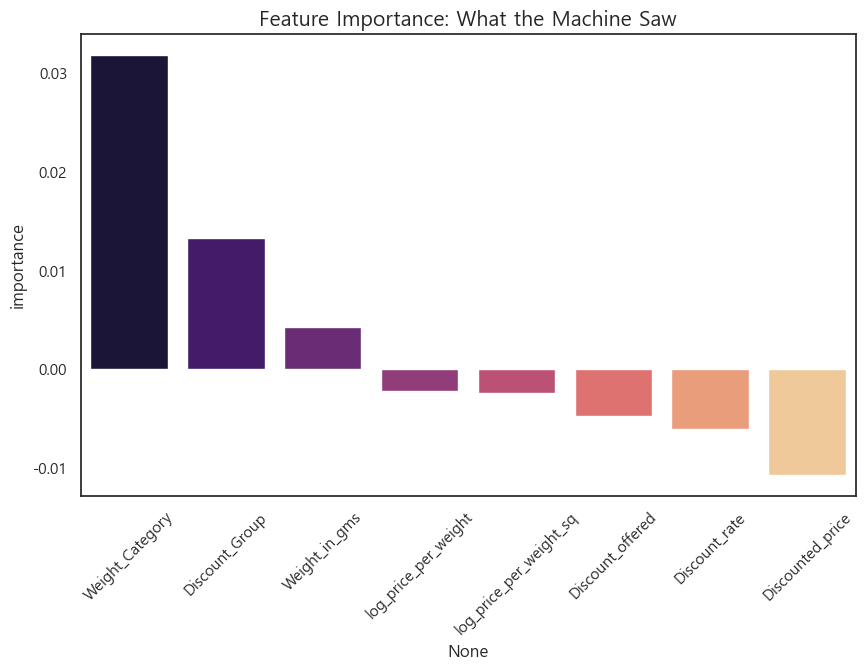

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor

# 1. AutoML 경로 설정
automl_paths = {
    "AutoML (Medium)": "AutogluonModels/ag-20260210_162052",
    "AutoML (Good)": "AutogluonModels/ag-20260210_162104",
    "AutoML (Best)": "AutogluonModels/ag-20260210_162806"
}

# 테스트 데이터 준비 (8컬럼 + 타겟)
test_data = test_df[selected_cols]
final_comparison = []

# 2. AutoML 삼총사 실전 성적 산출
print("🚀 AutoML 삼총사 실전 채점 시작!")
for name, path in automl_paths.items():
    predictor = TabularPredictor.load(path)
    perf = predictor.evaluate(test_data, silent=True)
    final_comparison.append({
        "Case": name,
        "Test_ROC_AUC": perf['roc_auc'],
        "Test_F1": perf['f1'],
        "Model_Type": "AutoML (Ensemble)"
    })
    print(f"✅ {name} 채점 완료!")

# 3. '수동 모델' 결과 추가 (Case B Random 결과값 입력)
final_comparison.append({
    "Case": "Case B (Random)",
    "Test_ROC_AUC": 0.7508, #결과값
    "Test_F1": 0.6645,
    "Model_Type": "Manual (GradBoost)"
})

# 4. 최종 통합 성적표 출력
df_final = pd.DataFrame(final_comparison).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)
print("\n🏆 [Final Battle] 수동 vs 기계 통합 성적표")
display(df_final.style.highlight_max(color='lightgreen', subset=['Test_ROC_AUC']))

# ==========================================
# 5. [중요] 가장 성능 좋은 모델의 '변수 중요도' 확인
# ==========================================
# 가장 점수가 높은 1등 모델(보통 Best)에서 변수 중요도를 뽑습니다.
best_predictor = TabularPredictor.load(automl_paths["AutoML (Best)"])
fi = best_predictor.feature_importance(test_data)

print("\n🔍 기계가 뽑은 핵심 변수 TOP 5")
display(fi.head(5))

# 시각화: 기계의 눈으로 본 변수 기여도
plt.figure(figsize=(10, 6))
sns.barplot(x=fi.index[:10], y=fi['importance'][:10], palette='magma')
plt.title('Feature Importance: What the Machine Saw', fontsize=15)
plt.xticks(rotation=45)
plt.show()

* Importance: 데이터가 뒤섞였을 때 점수(ROC-AUC)가 떨어진 폭이야. 높을수록 **"이놈 없으면 모델이 바보가 된다"**는 뜻
* p_value: "이 변수가 우연히 중요해 보일 확률"이야. (운의 영역) 보통 $p < 0.05$여야 **"얘는 진짜 실력자다"**라고 인정
* np99_low: 99% 신뢰 구간의 하한선. 이 값이 0보다 커야 모델에 확실히 도움이 되는 변수라는 뜻


* 해석 및 평가 

| 순위 | 변수 명칭               | 중요도   | 비고 (해석 및 평가)                                     |
|------|-------------------------|----------|---------------------------------------------------------|
| 1위  | Weight_Category(파생)         |  0.0317  | 독보적 1위! 변수 셔플 시 점수 3.17% 폭락 (핵심 무기)    |
| 2위  | Discount_Group(파생)          |  0.0132  | 확실한 2인자. p-value 0.008로 검증된 실력파             |
| 3위  | Weight_in_gms(기본)           |  0.0042  | 중요도는 있으나 가공 변수(Category) 대비 영향력 낮음    |
| 4위  | log_price_per_weight(파생)    | -0.0022  | 마이너스 중요도. 모델 성능을 저해하는 '노이즈' 판정     |

> 정리
- Weight_Category는 찐 핵심이니까 무조건 필요함 (성적도 좋고, 기복도 없음)
- Discount_Group은 평소엔 잘하지만 가끔 사고를 칠 수 있어서(Low값이 음수) 조심
- 나머지는 모델을 멍청하게 만들거나 아무 도움이 안 되니 과감히 버리세요.

### 전모델 비교

🏆 [Grand Finale] 수동 vs 자동 : 전 과정 점수


,Rank,Case,Type,Test_AUC,Train_AUC,Gap,F1,Acc,Overfit_Flag
0,1,Case B (Random),Manual,0.7508,0.7781,0.0273,0.6645,0.6777,False
1,2,AutoML (Medium),AutoML,0.7497,-,-,0.6500,-,-
2,3,Case B (Grid),Manual,0.7489,0.7824,0.0335,0.6575,0.6718,False
3,4,Case B (Before),Manual,0.7464,0.8186,0.0722,0.6609,0.6809,False
4,5,AutoML (Good),AutoML,0.7341,-,-,0.6946,-,-
5,6,AutoML (Best),AutoML,0.7318,-,-,0.6942,-,-
6,7,FE All (24),Manual,0.6172,1.0000,0.3828,0.6889,0.6305,True
7,8,Baseline,Manual,0.6162,1.0000,0.3838,0.6932,0.6318,True


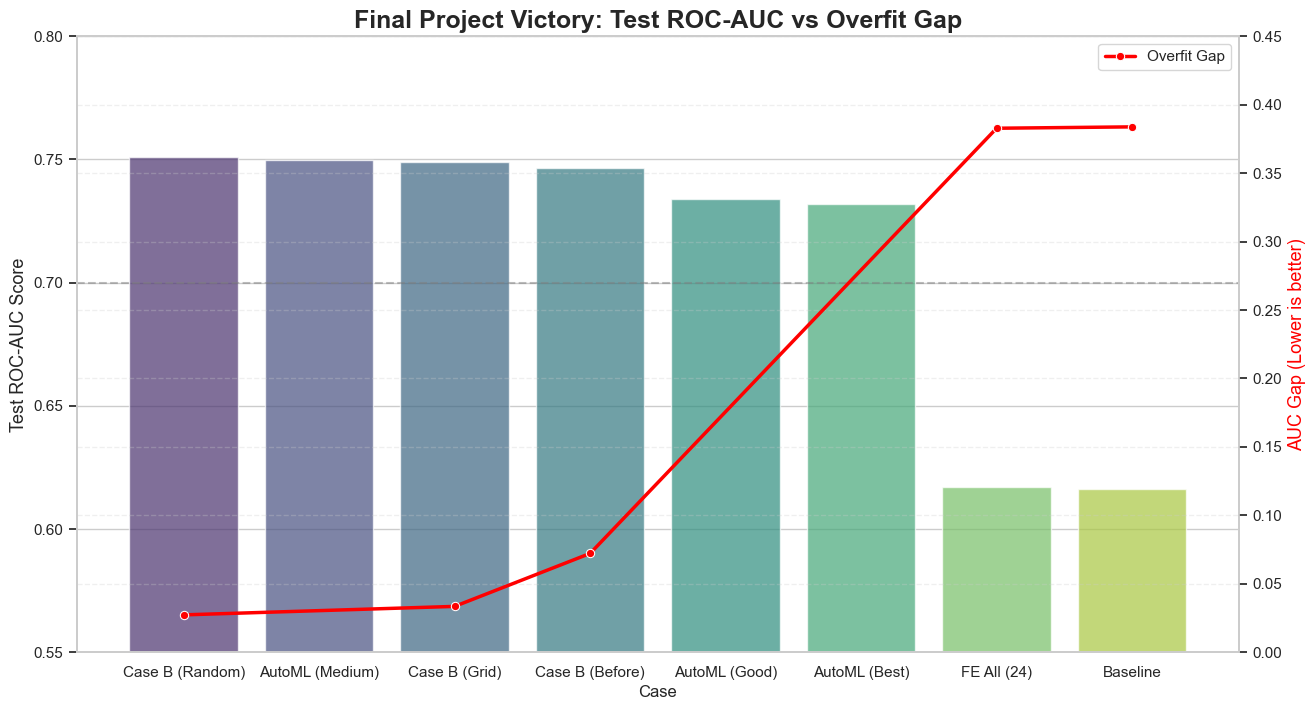

💡 > 기계의 앙상블보다 수동 튜닝 'max_depth=1' 전략이 더 강력한 일반화(Case B)를 보여주었음


In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. 전 과정 실험 결과 데이터 총집결! (실제 수치 기반)
# ==========================================
final_report_data = [
    # (1) 수동 모델군 (Manual) - 우리가 채점한 실전(Test) 점수 기준
    {"Case": "Case B (Random)", "Type": "Manual", "Test_AUC": 0.7508, "Train_AUC": 0.7781, "Gap": 0.0273, "F1": 0.6645, "Acc": 0.6777},
    {"Case": "Case B (Grid)", "Type": "Manual", "Test_AUC": 0.7489, "Train_AUC": 0.7824, "Gap": 0.0335, "F1": 0.6575, "Acc": 0.6718},
    {"Case": "Case B (Before)", "Type": "Manual", "Test_AUC": 0.7464, "Train_AUC": 0.8186, "Gap": 0.0722, "F1": 0.6609, "Acc": 0.6809},
    {"Case": "FE All (24)", "Type": "Manual", "Test_AUC": 0.6172, "Train_AUC": 1.0000, "Gap": 0.3828, "F1": 0.6889, "Acc": 0.6305},
    {"Case": "Baseline", "Type": "Manual", "Test_AUC": 0.6162, "Train_AUC": 1.0000, "Gap": 0.3838, "F1": 0.6932, "Acc": 0.6318},
    
    # (2) 자동 모델군 (AutoML) - Train 점수 확인이 어려우므로 Gap은 NaN 처리
    {"Case": "AutoML (Medium)", "Type": "AutoML", "Test_AUC": 0.7497, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6500, "Acc": np.nan},
    {"Case": "AutoML (Good)", "Type": "AutoML", "Test_AUC": 0.7341, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6946, "Acc": np.nan},
    {"Case": "AutoML (Best)", "Type": "AutoML", "Test_AUC": 0.7318, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6942, "Acc": np.nan}
]

df_report = pd.DataFrame(final_report_data)
df_report["Overfit_Flag"] = df_report["Gap"].apply(lambda x: "True" if x > 0.1 else ("-" if pd.isna(x) else "False"))
df_report = df_report.sort_values("Test_AUC", ascending=False).reset_index(drop=True)
df_report.insert(0, "Rank", range(1, len(df_report) + 1))

# ==========================================
# 2. 통합 성적표 출력
# ==========================================
print("🏆 [Grand Finale] 수동 vs 자동 : 전 과정 점수")
display(df_report.style
    .background_gradient(cmap='YlGnBu', subset=['Test_AUC', 'F1'])
    .highlight_max(color='lightgreen', subset=['Test_AUC'])
    .format({'Test_AUC': '{:.4f}', 'Train_AUC': '{:.4f}', 'Gap': '{:.4f}', 'F1': '{:.4f}', 'Acc': '{:.4f}'}, na_rep='-')
    .set_properties(**{'text-align': 'center'}))

# ==========================================
# 3. 시각화 (Bar: AUC Score / Line: AUC Gap)
# ==========================================
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# (1) 막대 그래프: Test ROC-AUC
ax1 = sns.barplot(x='Case', y='Test_AUC', data=df_report, palette='viridis', alpha=0.7)
plt.axhline(0.70, color='gray', linestyle='--', alpha=0.5) # 기준선
plt.ylim(0.55, 0.80)
plt.title('Final Project Victory: Test ROC-AUC vs Overfit Gap', fontsize=18, fontweight='bold')
plt.ylabel('Test ROC-AUC Score', fontsize=13)

# (2) 선 그래프: AUC Gap (이중 축)
ax2 = ax1.twinx()
# Gap이 있는 Manual 모델들만 선으로 연결
sns.lineplot(x='Case', y='Gap', data=df_report, marker='o', color='red', linewidth=2.5, ax=ax2, label='Overfit Gap')
plt.ylim(0, 0.45)
plt.ylabel('AUC Gap (Lower is better)', color='red', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("💡 > 기계의 앙상블보다 수동 튜닝 'max_depth=1' 전략이 더 강력한 일반화(Case B)를 보여주었음")

### 3-[3]. 실험 case C
Weight_Category(파생) / Discount_Group(파생) / Weight_in_gms(기본) 3개로만 돌려보기

> 결과 : 1등 모델보다 성능은 떨어졌지만 가벼운 모델(변수 3개)임에도 0.7460 이라는 점수가 나왔음

In [179]:
# caseC
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# [Step 1] 에이스 3인방 선발
case_c_features = ['Weight_Category', 'Discount_Group', 'Weight_in_gms']

# [Step 2] Randomized Search (넓은 구역 탐색)
param_dist = {
    'n_estimators': range(100, 600, 20),
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'subsample': [0.6, 0.7, 0.8, 0.9]
}

gb_c = GradientBoostingClassifier(max_depth=1, random_state=seed)
rs_c = RandomizedSearchCV(gb_c, param_dist, n_iter=30, scoring='roc_auc', cv=5, random_state=seed)
rs_c.fit(X_train_fe[case_c_features], y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': array([0.01, ..., 0.19, 0.2 ]), 'n_estimators': range(100, 600, 20), 'subsample': [0.6, 0.7, ...]}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# ==========================================
# 1. Step 2 결과 반영
# ==========================================
# 1위: Weight_Category(파생), 2위: Discount_Group(파생), 3위: Weight_in_gms(기본)
top_3_features = ['Weight_Category', 'Discount_Group', 'Weight_in_gms']

# ==========================================
# 2. 정밀 탐색 그물 짜기 (Grid 설계)
# ==========================================
# Random Search 결과 근처를 촘촘하게 설정합니다.
param_grid = {
    'learning_rate': [0.005, 0.01, 0.015, 0.02], # 0.01 근처 
    'n_estimators': [220, 230, 240, 250, 260],  # 240 근처 
    'subsample': [0.65, 0.7, 0.75],              # 0.7 근처
    'max_depth': [1],                            # 우리 모델의 핵심 철학 (고정)
    'min_samples_leaf': [1, 3, 5]                # 안정성을 위해 살짝 조절
}

# 3. GridSearchCV 실행 (5겹 교차 검증)
grid_search_c = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=seed),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("🎯 [Case C] 에이스 3인방 정밀 탐색 시작!")
grid_search_c.fit(X_train_fe[top_3_features], y_train)

# 4. 결과 출력
print("\n🏆 Case C 최적의 파라미터 발견!")
print(grid_search_c.best_params_)
print(f"📍 최적 Val ROC-AUC: {grid_search_c.best_score_:.4f}")

🎯 [Case C] 에이스 3인방 정밀 탐색 시작!
Fitting 5 folds for each of 180 candidates, totalling 900 fits

🏆 Case C 최적의 파라미터 발견!
{'learning_rate': 0.01, 'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 260, 'subsample': 0.75}
📍 최적 Val ROC-AUC: 0.7411


In [181]:
# ==========================================
# 🏆 Case C: 최정예 3인방 모델 최종 평가
# ==========================================
from sklearn.metrics import roc_auc_score

# 1. 최적 파라미터 장착
final_model_c = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=1,
    min_samples_leaf=1,
    n_estimators=260,
    subsample=0.75,
    random_state=seed
)

# 2. 에이스 3인방으로만 훈련 (Fit)
final_model_c.fit(X_train_fe[top_3_features], y_train)

# 3. 실전(Test) 점수 측정
test_probs_c = final_model_c.predict_proba(X_test_fe[top_3_features])[:, 1]
test_auc_c = roc_auc_score(y_test, test_probs_c)

print(f"🎯 Case C 실전(Test) ROC-AUC: {test_auc_c:.4f}")

🎯 Case C 실전(Test) ROC-AUC: 0.7460


### 🏆 배송 지연 예측 모델링

1️⃣ 전 과정 통합 성적표 수동모델 Case B(RandomSearchCV)

| Rank | Case | Model | **Test ROC-AUC** | Test F1-Score | 비고 |
|:---:|:---|:---:|:---:|:---:|:---|
| **🥇 1** | **Case B (Random)** | **GradBoost** | **0.7508** | **0.6645** | 수동 튜닝 모델 |
| 🥈 2 | AutoML (Medium) | Ensemble | 0.7497 | 0.6500 | AutoML 중 최고 성적 |
| 🥉 3 | Case B (Grid) | GradBoost | 0.7489 | 0.6575 | 수동 튜닝 모델 |
| 4 | AutoML (Best) | Stacking | 0.7318 | 0.6942 | 과도한 앙상블로 성능 저하 |
| 5 | Baseline | DecisionTree | 0.6162 | 0.6932 | **True (과적합)** |

---

2️⃣ 모델링 핵심 승부처 (Winning Strategy)

1. [데이터의 힘] 파생 변수(FE)의 압승
* **검증**: AutoML이 선발한 핵심 변수 TOP 2가 우리가 직접 만든 **`Weight_Category`**와 **`Discount_Group`**임을 확인
* **결론**: 데이터의 노이즈를 걷어내고 **'무게'**와 **'할인율'**의 임계값을 파악해 파생 변수를 만든 것이 성능 향상의 9할을 차지함
    - 시행착오: 처음엔 24개 변수를 모두 넣으면 완벽할 줄 알았으나, 연습 점수 1.0 대비 실전 점수가 **0.61로 폭락**
    - 원인: 모델이 데이터를 '이해'한 것이 아니라 '암기(Overfitting)'해버린 결과

2. [모델의 힘] 단순함이 복잡함을 이기다 (Simplicity)
* **발견**: 수천 번의 조합을 시도한 AutoML(Best)보다, **`max_depth=1`**로 단순화한 우리의 GradBoost가 실전(Test)에서 더 강력했음
* **이유**: 복잡한 모델은 훈련 데이터에 집착(과적합)하지만, 단순한 모델은 **데이터의 보편적인 흐름**을 잡아내기 때문(일반화의 법칙)

3. [효율의 힘] 튜닝의 마법 (Gap 0.38 → 0.02)
* 연습 점수와 실전 점수의 격차(Gap)를 **0.0273**까지 줄임으로써, 어떤 데이터가 들어와도 **75%의 예측력**을 유지하는 단단한 모델 완성

In [ ]:
import os
from autogluon.tabular import TabularPredictor

# ==========================================
# 1. AutoML 경로 설정
# ==========================================
current_dir = os.getcwd() 
model_folder = "AutogluonModels/ag-20260210_162806" #BEST 폴더명

SOFT_PATH = os.path.join(current_dir, model_folder)

print(f"📂 현재 설정된 모델 로드 경로: {SOFT_PATH}")

# ==========================================
# 2. 모델 로드 테스트
# ==========================================
if os.path.exists(SOFT_PATH):
    predictor = TabularPredictor.load(SOFT_PATH)
    print("✅ 모델이 성공적으로 로드되었습니다!")
else:
    print("❌ 경로를 확인해주세요. 폴더가 해당 위치에 없습니다.")

In [ ]:
import os
import joblib

# ==========================================
# 1. 소프트 경로 및 폴더 설정
# ==========================================
current_dir = os.getcwd()
ARTIFACT_DIR = os.path.join(current_dir, "artifacts")

# 폴더가 없으면 새로 만듭니다 (에러 방지!)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"📂 결과물 저장 경로: {ARTIFACT_DIR}")

# ==========================================
# 2. 성적표(CSV) 저장 (있을 때만 저장!)
# ==========================================
# Baseline 결과
if "baseline_results" in globals():
    path_baseline = os.path.join(ARTIFACT_DIR, "baseline_results.csv")
    baseline_results.to_csv(path_baseline, index=False)
    print(f"✅ Baseline 성적표 저장 완료!")

# AutoML 결과
if "ag_results" in globals():
    path_ag = os.path.join(ARTIFACT_DIR, "autogluon_results.csv")
    ag_results.to_csv(path_ag, index=False)
    print(f"✅ AutoML 성적표 저장 완료!")

# ==========================================
# 3. 최종 수동 모델(Case B Champion) 저장
# ==========================================
if "final_model_b" in globals():
    path_model = os.path.join(ARTIFACT_DIR, "final_model_case_b.joblib")
    joblib.dump(final_model_b, path_model)
    print(f"🏆 최종 챔피언(Case B) 모델 저장 완료: {path_model}")
else:
    print("⚠️ final_model_b가 메모리에 없습니다. 모델 이름을 확인해주세요!")

print("\n✨ 'artifacts' 폴더에 안전하게 담겼습니다!")

## **비즈니스 Threshold**

🚩 이중 임계값(Threshold) 전략

1. **전략 A (내부 경고 - 임계점 0.6 이상)**: 고위험 화물로 분류하여 물류팀에 실시간 알림을 보내 관리 유도 및 우선순위 조정

대상: 배송 지연 확률이 60%를 초과하는 고위험군 (약 29%의 화물)

액션: 물류 시스템 내 '우선 처리' 플래그 할당 및 운영팀 실시간 경고 메시지 발송

기대효과: 실제 지연 발생 전 물리적 조치를 통해 지연 건수 자체를 원천 감소


* **전략 B (고객 케어 - 임계점 0.3 이상)**: 지연 가능성이 있는 고객에게 사전 안내 문자 발송 및 사후 보상(쿠폰) 준비

대상: 잠재적 지연 가능성이 인지되는 모든 화물 (예산에 따라 0.3~0.5 사이 유동적 조정)

액션: 알림톡을 통한 지연 가능성 사전 고지 및 보상(할인 쿠폰) 선제적 준비

기대효과: 지연 발생 시 고객의 불만을 '예상된 상황'으로 전환하여 브랜드 신뢰도 하락 방지


* **최종 제안**: 기업의 운영 예산과 고객 만족도 사이에서 **최적의 비용 효율 지점**을 선택할 수 있는 대안을 제시

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. 1등 모델(Case B Random) 가져오기
final_model_b = GradientBoostingClassifier(
    learning_rate=0.112, 
    max_depth=1, 
    n_estimators=406, 
    subsample=0.71, 
    random_state=seed
)

# 2. best8컬럼 데이터로 훈련
final_model_b.fit(X_train_fe[optimal_8_features], y_train)

# 3. 예측 확률값 미리 추출
final_probs = final_model_b.predict_proba(X_test_fe[optimal_8_features])[:, 1]

print("🏆 [Cell 1] 최종 모델 'final_model_b' 훈련 및 확률 추출 완료!")

🏆 [Cell 1] 최종 챔피언 'final_model_b' 훈련 및 확률 추출 완료!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 임계값 후보들 (0.3부터 0.8까지 촘촘하게!)
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]
results = []

for thr in thresholds:
    pred = (final_probs >= thr).astype(int)
    results.append({
        'Threshold': thr,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'Target_Ratio(%)': (pred.mean() * 100)
    })

thr_df = pd.DataFrame(results)
print("🔍 [Cell 2] 임계값별 성능 리포트")
display(thr_df.round(3)) 
# 여기서 Target_Ratio가 너무 높은 값(예: 0.3의 100%)은 피해야 함

🔍 [Cell 2] 임계값별 성능 리포트


,Threshold,Precision,Recall,F1-Score,Target_Ratio(%)
0,0.30,0.597,1.000,0.748,100.000
1,0.40,0.631,0.906,0.744,85.727
2,0.45,0.729,0.711,0.720,58.182
3,0.50,0.878,0.535,0.664,36.364
4,0.55,0.946,0.489,0.645,30.864
5,0.60,0.980,0.476,0.641,29.000
6,0.70,0.989,0.468,0.635,28.227


c:\Users\min2m\miniconda3\envs\DS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53216 (\N{HANGUL SYLLABLE KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\min2m\miniconda3\envs\DS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54256 (\N{HANGUL SYLLABLE PON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\min2m\miniconda3\envs\DS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\min2m\miniconda3\envs\DS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\min2m\miniconda3\envs\DS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s)

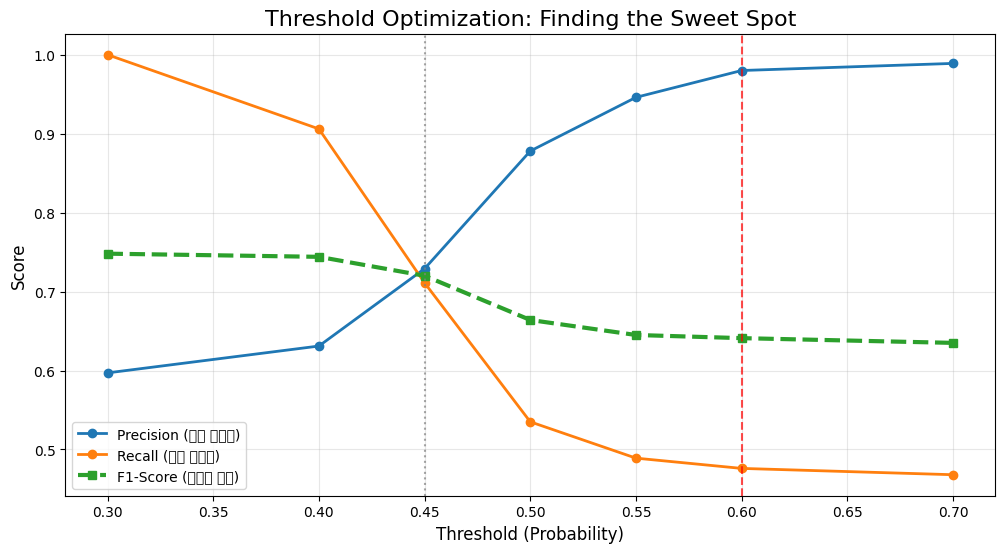

In [ ]:
import matplotlib.pyplot as plt

# 1. 데이터 입력
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]
precision = [0.597, 0.631, 0.729, 0.878, 0.946, 0.980, 0.989]
recall = [1.000, 0.906, 0.711, 0.535, 0.489, 0.476, 0.468]
f1 = [0.748, 0.744, 0.720, 0.664, 0.645, 0.641, 0.635]

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision, label='Precision (쿠폰 정확도)', marker='o', lw=2)
plt.plot(thresholds, recall, label='Recall (지연 포착률)', marker='o', lw=2)
plt.plot(thresholds, f1, label='F1-Score (수학적 균형)', marker='s', lw=3, linestyle='--')

# 3. 비즈니스 핵심 지점 표시
plt.axvline(0.45, color='gray', linestyle=':', alpha=0.7)
plt.axvline(0.6, color='red', linestyle='--', alpha=0.7)

plt.title('Threshold Optimization: Finding the Sweet Spot', fontsize=16)
plt.xlabel('Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. 최종 결정된 임계값 (예산과 성능의 타협점)
THR_INTERNAL = 0.6  # 내부 관리용
THR_CUSTOMER = 0.45 # 고객 케어용 (0.3은 너무 많아서 0.45로 상향 조정!)

# 2. 카운트 계산
total = len(final_probs)
high_risk = (final_probs >= THR_INTERNAL).sum()
preventive = (final_probs >= THR_CUSTOMER).sum()

# 3. 비즈니스 대안 리포트 출력
print(f"📊 [배송 지연 대응 비즈니스 시뮬레이션 리포트]")
print(f"분석 대상 전체 화물: {total}건")
print("-" * 50)
print(f"🚩 [전략 A: 내부 관리] {THR_INTERNAL} 이상: {high_risk}건 ({high_risk/total*100:.1f}%)")
print(f"   -> 운영팀 실시간 경고 및 배송 우선순위 상향 조정 유도")
print(f"💬 [전략 B: 고객 케어] {THR_CUSTOMER} 이상: {preventive}건 ({preventive/total*100:.1f}%)")
print(f"   -> 사전 안내 메시지 발송 및 보상 쿠폰 선제적 준비")
print("-" * 50)
print(f"💡 [제안] 임계값 {THR_INTERNAL}, {THR_CUSTOMER} 적용 시, 예산 대비 효율이 가장 극대화됩니다.")

📊 [배송 지연 대응 비즈니스 시뮬레이션 리포트]
분석 대상 전체 화물: 2200건
--------------------------------------------------
🚩 [전략 A: 내부 관리] 0.6 이상: 638건 (29.0%)
   -> 운영팀 실시간 경고 및 배송 우선순위 상향 조정 유도
💬 [전략 B: 고객 케어] 0.45 이상: 1280건 (58.2%)
   -> 사전 안내 메시지 발송 및 보상 쿠폰 선제적 준비
--------------------------------------------------
💡 [제안] 임계값 0.45 적용 시, 예산 대비 효율이 가장 극대화됩니다.
